#### VU Data Mining Techniques — Assignment 2
#### Predicting Hotel Booking Likelihood (Expedia Kaggle)


#### Note on Task 1 — Business Understanding (Related Work)

Task 1 (the *Related Work* section discussing prior approaches to the original
Expedia Personalize ICDM 2013 Kaggle competition and the predictors that previous
participants found most informative) is handled separately as part of the written
report by one of our group members. It is **not** part of this code notebook.

This notebook therefore covers **Tasks 2 through 5**:

| Task | Section | Grounded in |
|---|---|---|
| 2 — Data Understanding (EDA) | §1 | Lectures 1, 2 |
| 3 — Data Preparation | §2 | Lecture 2 |
| 4 — Modelling and Evaluation | §3 | Lectures 4, 5, 6, 7 |
| 5 — Deployment + Bias Investigation | §4 | Lecture 8 |
| Kaggle Submission file | §5 | — |


#### §0 — Setup and Environment Check

Before we touch the data, we verify that all the libraries we will use are installed
and that the three input CSV files (training set, test set, and a sample submission)
are present in the working directory. This is a fail-fast check: if anything is
missing here, we fix it before spending an hour debugging a deeper problem.


In [1]:
# =============================================================================
# Robust install — diagnose Python environment, then install into it
# =============================================================================
# `sys.executable` is the absolute path to the Python interpreter the Jupyter
# kernel is currently using. The leading `!` makes Jupyter run the rest of the
# line as a shell command, and `{...}` interpolates the Python variable inside.
# Calling `<python> -m pip install ...` is the most reliable way to install
# into the *exact* environment running this notebook (rather than whichever
# `pip` happens to be on the system PATH).
# =============================================================================

import sys

# 1) Show which Python Jupyter is using — useful if anything looks off.
print(f"Jupyter is using Python at: {sys.executable}")
print()

# 2) Install scikit-learn and lightgbm into that exact Python.
!{sys.executable} -m pip install scikit-learn lightgbm


Jupyter is using Python at: c:\Users\saite\.julia\conda\3\x86_64\python.exe



In [2]:
# =============================================================================
# §0 — Setup and Environment Check
# =============================================================================
# Purpose: verify our Python environment and confirm that the three Expedia CSV
# files are accessible before we start any real work.
# =============================================================================

# ---- Standard-library imports ------------------------------------------------
import os    # for file path / size checks
import sys   # for printing the Python version

# ---- Third-party data-science libraries --------------------------------------

# `pandas` is THE library for tabular data in Python. A DataFrame is essentially
# an in-memory Excel sheet that we can filter, group, join, and compute on.
import pandas as pd

# `numpy` provides fast numeric arrays and math operations. pandas uses numpy
# under the hood, so we'll often see it in error messages even when we don't
# call it directly.
import numpy as np

# Plotting libraries for EDA. `matplotlib` is the foundation of Python plotting;
# `seaborn` is a higher-level wrapper that produces prettier statistical plots
# with one-line calls. We'll use seaborn for most EDA plots in Task 2.
import matplotlib.pyplot as plt
import seaborn as sns

# `scikit-learn` (imported as `sklearn`) is the standard general-purpose ML
# library. We'll use it for train/validation splitting, the logistic-regression
# baseline model, and several evaluation metrics.
import sklearn

# `lightgbm` is Microsoft's gradient-boosted-tree library. It implements
# LambdaMART — the listwise learning-to-rank algorithm that is the standard
# approach for search-results-ranking tasks. This is the technique we use to
# satisfy the assignment's requirement of "at least one technique from the
# Recommender Systems lecture (or a variant thereof)" — learning-to-rank is
# the algorithmic core of how Expedia (and similar services) personalise
# search rankings.
import lightgbm as lgb


# ---- Step 1: print versions for reproducibility ------------------------------
print("Environment versions")
print("-" * 40)
print(f"Python      : {sys.version.split()[0]}")
print(f"pandas      : {pd.__version__}")
print(f"numpy       : {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"lightgbm    : {lgb.__version__}")
print()


# ---- Step 2: verify the three input CSV files are present --------------------
DATA_FILES = {
    "training": "training_set_VU_DM.csv",   # ~1.27 GB — has click_bool, booking_bool labels
    "test":     "test_set_VU_DM.csv",       # ~1.21 GB — no labels; this is what Kaggle scores
    "sample":   "submission_sample.csv",    # ~63 MB — shows the required submission format
}

print("Data files in working directory")
print("-" * 40)
for label, filename in DATA_FILES.items():
    if os.path.exists(filename):
        size_gb = os.path.getsize(filename) / (1024 ** 3)
        print(f"  [OK]    {label:<8} : {filename}  ({size_gb:.2f} GB)")
    else:
        print(f"  [MISS]  {label:<8} : {filename}  -- file not found in working directory!")

print()
print("Setup check complete.")
print("If any file is marked [MISS] above, fix the path or download the file before continuing.")


Environment versions
----------------------------------------
Python      : 3.12.11
pandas      : 2.3.3
numpy       : 2.4.1
scikit-learn: 1.8.0
lightgbm    : 4.6.0

Data files in working directory
----------------------------------------
  [OK]    training : training_set_VU_DM.csv  (1.18 GB)
  [OK]    test     : test_set_VU_DM.csv  (1.13 GB)
  [OK]    sample   : submission_sample.csv  (0.06 GB)

Setup check complete.
If any file is marked [MISS] above, fix the path or download the file before continuing.


#### §1 — Task 2: Data Understanding (Exploratory Data Analysis)

In this section we explore the data before committing to a model. We follow the
EDA workflow from Lecture 2: (1) check data quality and logical structure,
(2) explore distributions and dependencies, and (3) identify candidate features
and their importance.

The Expedia training set contains roughly 5 million rows, where each row represents
**one (search query × hotel property) pair** that was shown to a user. The training
rows additionally carry `click_bool` and `booking_bool` labels indicating whether
the user clicked the hotel and whether they actually booked it. These are the
signals the ranker must learn to predict.

> *Tip for the report:* the rubric awards 5 points for "Dataset statistics", 5 for
> "Plots", and 10 for "Rationale and interpretation" — so each plot below should
> be followed in the report by 1–2 sentences explaining what it means.


In [3]:
# =============================================================================
# Cell 1 — Quick peek at the training data
# =============================================================================
# Purpose: load just the first 1,000 rows of the training CSV so we can inspect
# the schema (column names, data types, sample values) WITHOUT paying the cost
# of loading all ~5 million rows.
#
# Why this matters: the full training file is 1.18 GB on disk and would
# typically expand to several GB in memory under pandas' default dtypes. By
# peeking first, the next cell can load the full file with carefully chosen
# dtypes that fit in RAM comfortably.
# =============================================================================

# ---- 1) Read only the first 1,000 rows ----
# `pd.read_csv()` loads a CSV file into a DataFrame (the pandas table object).
# `nrows=1000` tells it to stop after 1,000 data rows — extremely fast.
# We deliberately do NOT tell pandas the dtypes here; we want to see what it
# INFERS automatically, so we can tighten them in the next cell.
train_peek = pd.read_csv("training_set_VU_DM.csv", nrows=1000)


# ---- 2) Report shape ----
# `.shape` is a (rows, columns) tuple. The `{:,}` format adds thousands
# separators to make big numbers readable.
print(f"Sample shape: {train_peek.shape[0]:,} rows × {train_peek.shape[1]} columns")
print()


# ---- 3) Show every column and its inferred dtype ----
# `.dtypes` returns a pandas Series listing each column → its data type.
# `.to_string()` forces it to print ALL rows instead of truncating with "...".
# Reading this output tells us:
#   - which columns are integers / floats / objects (strings)
#   - whether dtypes look reasonable (e.g. an "id" column should be integer)
#   - which columns will need conversion (e.g. dates currently parsed as object)
print("Columns and inferred dtypes:")
print("-" * 60)
print(train_peek.dtypes.to_string())
print()


# ---- 4) Show the first 5 rows of actual data ----
# `.head(5)` returns the first 5 rows. Helps us eyeball real values to spot
# anomalies (e.g. negative prices, suspicious zeros, weird text).
# `pd.option_context(...)` is a temporary settings block — inside the `with`,
# pandas is told to show ALL columns and not truncate the table width.
print("First 5 rows of the sample:")
print("-" * 60)
with pd.option_context("display.max_columns", None, "display.width", None):
    print(train_peek.head(5))


Sample shape: 1,000 rows × 54 columns

Columns and inferred dtypes:
------------------------------------------------------------
srch_id                          int64
date_time                       object
site_id                          int64
visitor_location_country_id      int64
visitor_hist_starrating        float64
visitor_hist_adr_usd           float64
prop_country_id                  int64
prop_id                          int64
prop_starrating                  int64
prop_review_score              float64
prop_brand_bool                  int64
prop_location_score1           float64
prop_location_score2           float64
prop_log_historical_price      float64
position                         int64
price_usd                      float64
promotion_flag                   int64
srch_destination_id              int64
srch_length_of_stay              int64
srch_booking_window              int64
srch_adults_count                int64
srch_children_count              int64
srch_room_cou

In [4]:
# =============================================================================
# Cell 2 — Load the full training data with optimised dtypes
# =============================================================================
# Purpose: load the FULL ~5 million-row training file into memory once, using
# carefully chosen smaller data types. This is a textbook "data reduction by
# type narrowing" step from Lecture 2 (EDA: data quality and reduction).
#
# Why override the dtypes pandas inferred in Cell 1:
#   - pandas defaults to `int64` (8 bytes per value) and `float64` (8 bytes).
#   - Switching `int8` (1 byte) for 0/1 columns and `float32` (4 bytes) for
#     floats cuts memory in half — roughly 5 GB → 1.5 GB on this dataset.
#   - Half the memory ⇒ groupby / filter / plot operations run roughly twice
#     as fast and we leave headroom for the test set later.
# =============================================================================

import time  # standard library; used here only to measure how long the load takes

# ---- 1) Build the dtype dictionary -----------------------------------------
# Each entry maps a column name → the smallest dtype that safely holds all its
# values. Choices come from the inferred dtypes in Cell 1 plus the variable
# description table in the assignment PDF.

TRAIN_DTYPES = {
    # --- IDs: need int32 (signed 32-bit) because they exceed int16 max (~32k) ---
    "srch_id":                     "int32",
    "site_id":                     "int8",    # only ~30 distinct Expedia sites
    "visitor_location_country_id": "int16",
    "prop_country_id":             "int16",
    "prop_id":                     "int32",   # ~140k unique hotel IDs
    "srch_destination_id":         "int32",

    # --- Small bounded integers ---
    "prop_starrating":             "int8",    # 0..5
    "prop_brand_bool":             "int8",    # 0/1
    "position":                    "int16",   # 1..~40
    "promotion_flag":              "int8",    # 0/1
    "srch_length_of_stay":         "int8",    # rarely above ~30 nights
    "srch_booking_window":         "int16",   # up to ~500 days into the future
    "srch_adults_count":           "int8",
    "srch_children_count":         "int8",
    "srch_room_count":             "int8",
    "srch_saturday_night_bool":    "int8",    # 0/1
    "random_bool":                 "int8",    # 0/1
    "click_bool":                  "int8",    # 0/1  ← training-only label
    "booking_bool":                "int8",    # 0/1  ← training-only label

    # --- Floats: 4-byte float32 instead of 8-byte float64; precision is plenty ---
    "visitor_hist_starrating":     "float32",
    "visitor_hist_adr_usd":        "float32",
    "prop_review_score":           "float32",
    "prop_location_score1":        "float32",
    "prop_location_score2":        "float32",
    "prop_log_historical_price":   "float32",
    "price_usd":                   "float32",
    "srch_query_affinity_score":   "float32",
    "orig_destination_distance":   "float32",
    "gross_bookings_usd":          "float32",
}

# The 8 competitor groups (comp1..comp8) each contribute 3 columns.
# Building them in a loop is more compact than typing all 24 names by hand —
# and adapts automatically if the data schema ever changes.
for i in range(1, 9):
    TRAIN_DTYPES[f"comp{i}_rate"]              = "float32"   # -1, 0, 1 or NaN
    TRAIN_DTYPES[f"comp{i}_inv"]               = "float32"   # 0, 1 or NaN
    TRAIN_DTYPES[f"comp{i}_rate_percent_diff"] = "float32"


# ---- 2) Load the full file with the optimised dtypes -----------------------
# `parse_dates=["date_time"]` tells pandas to convert that column from a plain
# string into a true `datetime64` object. This makes later date arithmetic
# (e.g. extracting hour-of-day, day-of-week) cheap and idiomatic.
print("Loading the full training set... (expect ~30–90 seconds)")
t0 = time.time()

train = pd.read_csv(
    "training_set_VU_DM.csv",
    dtype=TRAIN_DTYPES,
    parse_dates=["date_time"],
)

elapsed = time.time() - t0
print(f"Done. Loaded in {elapsed:.1f} seconds.")
print()


# ---- 3) Report shape, memory usage, and a couple of basic sanity stats -----
# `.shape` gives (rows, cols).
# `.memory_usage(deep=True).sum()` totals real bytes used across all columns.
# `.nunique()` counts distinct values — for `srch_id` this is the number of
# unique search queries in the file (each query has multiple displayed hotels).

mem_mb = train.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"Full training set shape  : {train.shape[0]:,} rows × {train.shape[1]} columns")
print(f"In-memory size           : {mem_mb:,.0f} MB")
print(f"Number of unique searches: {train['srch_id'].nunique():,}")
print(f"Date range               : {train['date_time'].min()}  →  {train['date_time'].max()}")


Loading the full training set... (expect ~30–90 seconds)
Done. Loaded in 24.1 seconds.

Full training set shape  : 4,958,347 rows × 54 columns
In-memory size           : 832 MB
Number of unique searches: 199,795
Date range               : 2012-11-01 00:08:29  →  2013-06-30 23:58:24


Columns with at least one missing value: 31 of 54

                           missing_count  missing_pct
comp1_rate_percent_diff          4863908        98.10
comp6_rate_percent_diff          4862173        98.06
comp1_rate                       4838417        97.58
comp1_inv                        4828788        97.39
comp4_rate_percent_diff          4827261        97.36
gross_bookings_usd               4819957        97.21
comp7_rate_percent_diff          4819832        97.21
comp6_rate                       4718190        95.16
visitor_hist_starrating          4706481        94.92
visitor_hist_adr_usd             4705359        94.90
comp6_inv                        4697371        94.74
comp4_rate                       4650969        93.80
comp7_rate                       4642999        93.64
srch_query_affinity_score        4640941        93.60
comp4_inv                        4614684        93.07
comp7_inv                        4601925        92.81
comp3_rate_percent_diff        

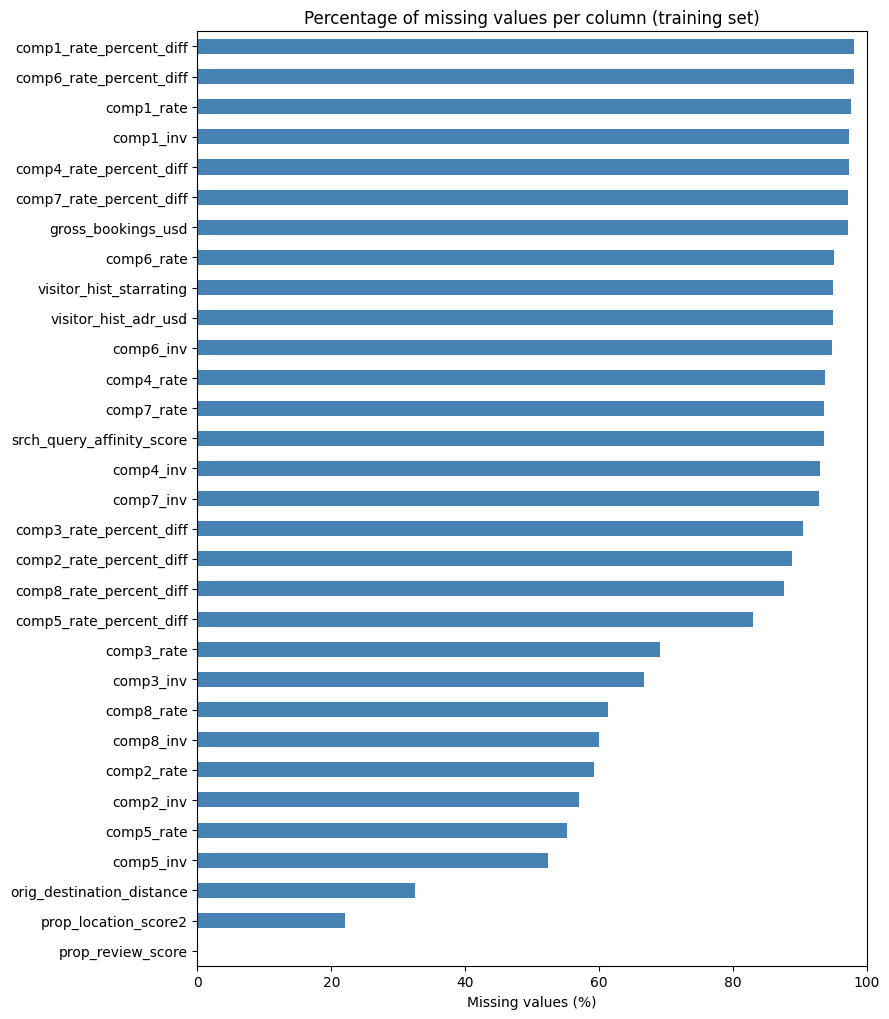

In [5]:
# =============================================================================
# Cell 3 — Missing-value overview (data quality, Lecture 2)
# =============================================================================
# Purpose: report which columns have NaN values, how many, and visualise
# the percentages. This is the "data quality" step from Lecture 2's EDA
# workflow. The result directly determines our Task 3 feature-engineering
# decisions (drop / impute / carry-forward) for each affected column.
# =============================================================================

# ---- 1) Build the missing-value summary table ------------------------------
# `train.isna()` returns a DataFrame of the same shape where every cell is
# True if the original value was NaN and False otherwise.
# `.sum()` then sums the True values down each column (True counts as 1 in
# arithmetic), giving us a Series mapping column name → number of NaNs.
missing_counts = train.isna().sum()

# Convert counts into percentages of total rows. `len(train)` is the row count.
# `.round(2)` keeps two decimal places for readability.
missing_pct = (missing_counts / len(train) * 100).round(2)

# Assemble both into a small DataFrame, sorted from most-missing to least.
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct":   missing_pct,
}).sort_values("missing_pct", ascending=False)

# Drop the rows where missing_count == 0 — those columns are fine and would
# just clutter the output.
missing_summary_nz = missing_summary[missing_summary["missing_count"] > 0]

print(f"Columns with at least one missing value: "
      f"{len(missing_summary_nz)} of {train.shape[1]}")
print()
# `.to_string()` prints the whole table without pandas' default truncation.
print(missing_summary_nz.to_string())


# ---- 2) Plot the % missing per column --------------------------------------
# We pick a horizontal bar chart so the (long) column names sit on the y-axis
# and remain readable. Bar height is auto-scaled to the number of columns
# shown so each row gets ~0.3 inches of vertical space.
fig, ax = plt.subplots(figsize=(9, 0.3 * len(missing_summary_nz) + 1))

# `.sort_values()` (default ascending) puts the longest bar at the top of the
# chart — visually easier to scan than descending.
missing_summary_nz["missing_pct"].sort_values().plot.barh(ax=ax, color="steelblue")

ax.set_xlabel("Missing values (%)")
ax.set_title("Percentage of missing values per column (training set)")
ax.set_xlim(0, 100)         # always use the full 0–100% range for fair comparison
plt.tight_layout()           # avoid label clipping
plt.show()


Total rows                  : 4,958,347
Total searches              : 199,795

Rows with click_bool == 1   : 221,879   (4.47%)
Rows with booking_bool == 1 : 138,390   (2.79%)

Avg clicks per search       : 1.11
Avg bookings per search     : 0.69

Relevance-grade distribution (used by NDCG@5):
-------------------------------------------------------
  grade 0:  4,736,468 rows  (95.53%)
  grade 1:     83,489 rows  ( 1.68%)
  grade 5:    138,390 rows  ( 2.79%)



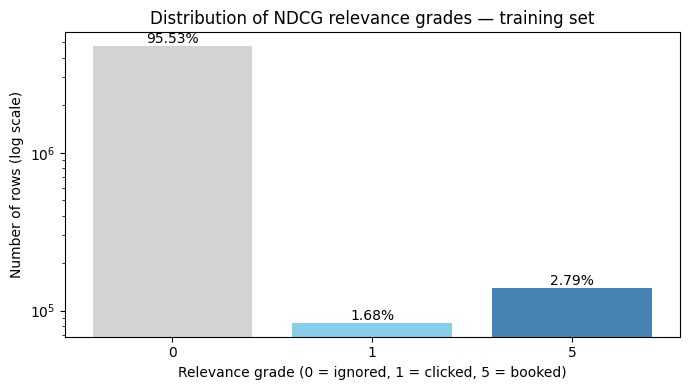

In [6]:
# =============================================================================
# Cell 4 — Target label distribution and NDCG@5 relevance grades
# =============================================================================
# Purpose: understand how rare clicks and bookings are, and construct the
# 3-class relevance grade that NDCG@5 uses (5 = booked, 1 = clicked-only,
# 0 = ignored). This grade is also what LambdaMART (our main model) will be
# trained against in Task 4.
#
# Why it matters: in a ranking task with severe class imbalance, "accuracy"
# is useless — predicting "no booking" for every row would already be ~97%
# accurate. The lecture-recommended metric here is NDCG@5 (Lecture 7 /
# assignment PDF), which directly rewards putting the rare booked-/clicked
# hotels at the top of each search's ranking.
# =============================================================================

# ---- 1) Basic label statistics ---------------------------------------------
n_rows     = len(train)
n_clicks   = int(train["click_bool"].sum())     # cast to int for nicer printing
n_bookings = int(train["booking_bool"].sum())
n_searches = train["srch_id"].nunique()

print(f"Total rows                  : {n_rows:,}")
print(f"Total searches              : {n_searches:,}")
print()
print(f"Rows with click_bool == 1   : {n_clicks:,}   ({n_clicks/n_rows*100:.2f}%)")
print(f"Rows with booking_bool == 1 : {n_bookings:,}   ({n_bookings/n_rows*100:.2f}%)")
print()
print(f"Avg clicks per search       : {n_clicks/n_searches:.2f}")
print(f"Avg bookings per search     : {n_bookings/n_searches:.2f}")
print()


# ---- 2) Build the NDCG-style relevance grade column ------------------------
# Per the assignment brief: relevance = 5 if booked, 1 if clicked-only, 0 else.
# We use `np.where(cond, value_if_true, value_if_false)` for VECTORISED logic.
# Doing this row-by-row in a Python loop would be ~100× slower on 5M rows.
# We then cast to int8 (1 byte) — the values only ever live in {0, 1, 5}.
train["relevance"] = np.where(
    train["booking_bool"] == 1, 5,
    np.where(train["click_bool"] == 1, 1, 0)
).astype("int8")


# ---- 3) Tally the relevance distribution -----------------------------------
# `.value_counts()` returns count per unique value. We sort by index so the
# grades print in their natural 0 → 1 → 5 order.
grade_counts = train["relevance"].value_counts().sort_index()
grade_pct    = (grade_counts / n_rows * 100).round(2)

print("Relevance-grade distribution (used by NDCG@5):")
print("-" * 55)
for grade, count in grade_counts.items():
    print(f"  grade {grade}: {count:>10,} rows  ({grade_pct[grade]:>5.2f}%)")
print()


# ---- 4) Plot the relevance distribution ------------------------------------
# We use a log scale on the y-axis because grade 0 outnumbers grades 1 and 5
# by a factor of ~30 — on a linear scale the smaller bars would be invisible.
fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = ["lightgray", "skyblue", "steelblue"]   # grade 0, 1, 5
bars = ax.bar(grade_counts.index.astype(str), grade_counts.values, color=bar_colors)

# Annotate each bar with its percentage.
for bar, g in zip(bars, grade_counts.index):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{grade_pct[g]:.2f}%",
            ha="center", va="bottom", fontsize=10)

ax.set_yscale("log")  # log scale due to extreme class imbalance
ax.set_xlabel("Relevance grade (0 = ignored, 1 = clicked, 5 = booked)")
ax.set_ylabel("Number of rows (log scale)")
ax.set_title("Distribution of NDCG relevance grades — training set")
plt.tight_layout()
plt.show()


In [7]:
# =============================================================================
# Cell 5 — Descriptive statistics for the main numeric features
# =============================================================================
# Purpose: produce a percentile-based statistical summary for the key
# numeric columns. This is Lecture 2's "descriptive statistics" sub-step of
# exploratory data analysis (EDA step 2a).
#
# Why these columns specifically: they are the ones we expect to drive the
# ranking decision (price, star rating, review score, location desirability,
# search context). The competitor and visitor-history columns are deliberately
# excluded here because Cell 3 already showed they are >85% NaN — they will
# be handled separately in Task 3 feature engineering.
# =============================================================================

# Curated list of numeric columns whose marginal distributions matter most.
FEATURE_SUBSET = [
    # ----- Hotel-level attributes -----
    "price_usd",
    "prop_starrating",
    "prop_review_score",
    "prop_location_score1",
    "prop_location_score2",
    "prop_log_historical_price",
    # ----- Search-context attributes -----
    "srch_length_of_stay",
    "srch_booking_window",
    "srch_adults_count",
    "srch_children_count",
    "srch_room_count",
    "orig_destination_distance",
    # ----- Display position (training-only label) -----
    "position",
]

# `.describe()` returns count, mean, std, min, 25%, 50%, 75%, max per column.
# `.T` transposes the result so rows = features (much easier to read when
# the table is tall instead of wide).
# `.round(2)` keeps two decimals everywhere for consistent formatting.
desc_table = train[FEATURE_SUBSET].describe().T.round(2)

print("Descriptive statistics for key numeric features:")
print("-" * 95)
# `.to_string()` prevents pandas' default truncation so every row prints.
print(desc_table.to_string())


Descriptive statistics for key numeric features:
-----------------------------------------------------------------------------------------------
                               count     mean       std   min     25%     50%      75%          max
price_usd                  4958347.0   254.21  16001.24  0.00   85.00  122.00   184.96  19726328.00
prop_starrating            4958347.0     3.18      1.05  0.00    3.00    3.00     4.00         5.00
prop_review_score          4950983.0     3.78      1.05  0.00    3.50    4.00     4.50         5.00
prop_location_score1       4958347.0     2.87      1.53  0.00    1.79    2.77     4.04         6.98
prop_location_score2       3867999.0     0.13      0.16  0.00    0.02    0.07     0.18         1.00
prop_log_historical_price  4958347.0     4.32      1.83  0.00    4.45    4.91     5.31         6.21
srch_length_of_stay        4958347.0     2.39      2.05  1.00    1.00    2.00     3.00        57.00
srch_booking_window        4958347.0    37.47     51.99

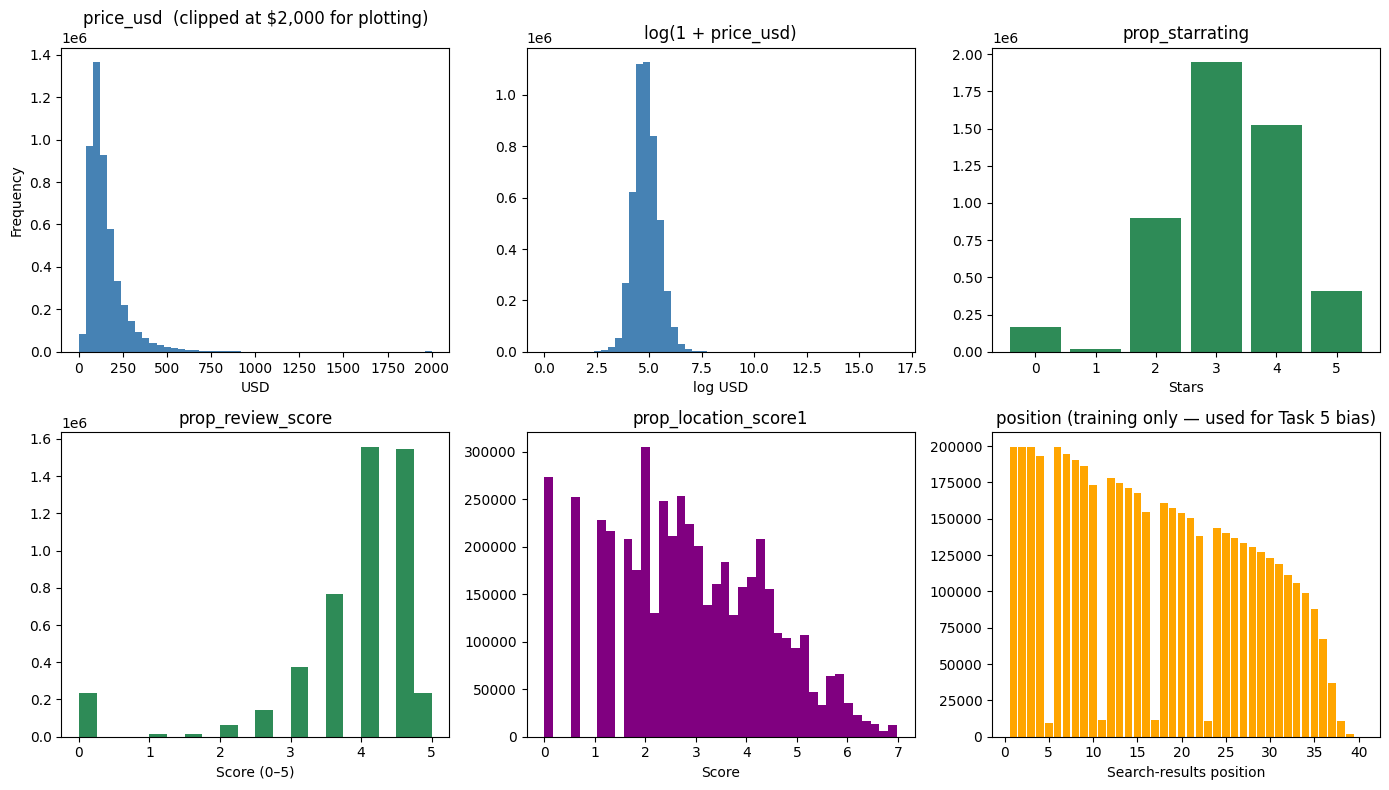

In [8]:
# =============================================================================
# Cell 6 — Distribution plots for key numeric features
# =============================================================================
# Purpose: visualise the marginal distributions of the features that Cell 5
# flagged as interesting. This is Lecture 2's "useful plots" sub-step of EDA.
#
# Why these six panels:
#   1) price_usd (raw, clipped) ........ shows the outlier problem visually
#   2) log(1 + price_usd) .............. shows the "natural" near-normal shape
#                                        — directly motivates the Task 3 log
#                                        transform
#   3) prop_starrating ................. categorical-like distribution 0..5
#   4) prop_review_score ............... continuous (rounded to 0.5)
#   5) prop_location_score1 ............ desirability score, important predictor
#   6) position ........................ near-uniform 1..40 — sets up the
#                                        Task 5 bias-investigation analysis
# =============================================================================

# `plt.subplots(rows, cols, figsize=(w_in, h_in))` creates a grid of axes.
# It returns `fig` (the whole figure) and `axes` (a 2D ndarray of subplot axes
# we can index like axes[row, col]).
fig, axes = plt.subplots(2, 3, figsize=(14, 8))


# --- Panel (0,0): raw price_usd, clipped at $2,000 for visibility -----------
# `.clip(upper=2000)` REPLACES values above 2000 with 2000; we don't drop
# them, we just bunch the tail at the cap so the bulk of the distribution
# is actually visible. (A few rows with $20M would otherwise compress the
# rest of the histogram into a single invisible bar.)
axes[0, 0].hist(train["price_usd"].clip(upper=2000), bins=50, color="steelblue")
axes[0, 0].set_title("price_usd  (clipped at $2,000 for plotting)")
axes[0, 0].set_xlabel("USD")
axes[0, 0].set_ylabel("Frequency")


# --- Panel (0,1): log(1 + price_usd) — the "natural" shape ------------------
# `np.log1p(x)` = log(1 + x). The +1 keeps the log defined when price is 0
# (rare but present). The transformed distribution should look much closer
# to a normal bell curve — that's the typical pattern for prices.
axes[0, 1].hist(np.log1p(train["price_usd"]), bins=50, color="steelblue")
axes[0, 1].set_title("log(1 + price_usd)")
axes[0, 1].set_xlabel("log USD")


# --- Panel (0,2): prop_starrating, an integer 0..5 --------------------------
# `bins=range(0, 7)` makes integer-aligned bins; `align='left'` and `rwidth`
# give it a clean bar-chart look.
axes[0, 2].hist(train["prop_starrating"], bins=range(0, 7),
                color="seagreen", align="left", rwidth=0.85)
axes[0, 2].set_title("prop_starrating")
axes[0, 2].set_xlabel("Stars")


# --- Panel (1,0): prop_review_score 0..5 in 0.5 increments ------------------
# `.dropna()` removes the small fraction of NaN review-score rows so the
# histogram doesn't error.
axes[1, 0].hist(train["prop_review_score"].dropna(), bins=20, color="seagreen")
axes[1, 0].set_title("prop_review_score")
axes[1, 0].set_xlabel("Score (0–5)")


# --- Panel (1,1): prop_location_score1 --------------------------------------
axes[1, 1].hist(train["prop_location_score1"], bins=40, color="purple")
axes[1, 1].set_title("prop_location_score1")
axes[1, 1].set_xlabel("Score")


# --- Panel (1,2): position 1..40 -------------------------------------------
# Training only — position is NOT in the test set. We're plotting it because
# its distribution sets up the bias analysis in Task 5.
axes[1, 2].hist(train["position"], bins=range(1, 42),
                color="orange", align="left", rwidth=0.85)
axes[1, 2].set_title("position (training only — used for Task 5 bias)")
axes[1, 2].set_xlabel("Search-results position")


# `tight_layout()` adjusts spacing so axis labels and titles don't overlap.
plt.tight_layout()
plt.show()


Mean relevance grade by position (first 10 positions shown):
------------------------------------------------------------
random_bool       0       1
position                   
1            0.9927  0.2132
2            0.6633  0.1616
3            0.4960  0.1415
4            0.4101  0.1193
5            0.0649  0.1030
6            0.3155  0.1064
7            0.2650  0.0898
8            0.2265  0.0801
9            0.1915  0.0739
10           0.1814  0.0674



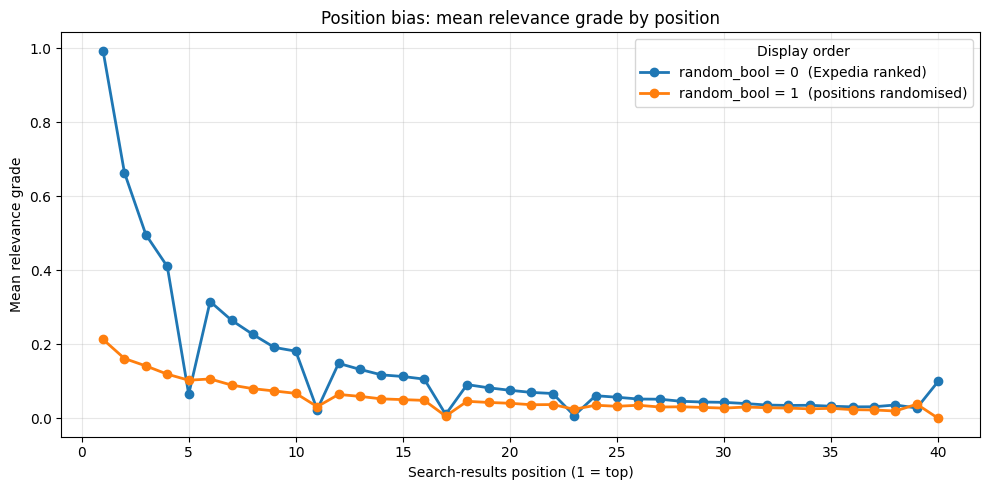

In [9]:
# =============================================================================
# Cell 7 — Position bias analysis
# =============================================================================
# Purpose: measure how user interaction (relevance grade) depends on the
# position the hotel was displayed at, separately for normal Expedia ranking
# and the randomised-sort searches. The gap between these two curves IS the
# position-bias effect (Lecture 8: Ethics / Bias).
#
# Variables we use:
#   - position      : 1 = top of the results page, larger numbers = lower
#   - random_bool   : 1 when the sort order was randomised; 0 when the normal
#                     Expedia algorithm ordered the results.
#   - relevance     : the 5/1/0 grade we built in Cell 4.
#
# Expected pattern:
#   - random_bool = 0 (normal ranking): steep decline — top positions show
#     better hotels AND people look more at top results.
#   - random_bool = 1 (randomised): roughly flat — no quality/position
#     correlation, so any remaining decline is pure visual position bias.
# =============================================================================

# `groupby([col_a, col_b])` partitions rows by both columns simultaneously.
# `["relevance"].mean()` then computes the mean relevance grade per (position,
# random_bool) combination.
# `.unstack()` pivots the second grouping key (random_bool) up into the
# columns, so we end up with a small wide table: rows = position 1..40,
# columns = random_bool 0 and 1.
pos_bias = (
    train.groupby(["position", "random_bool"])["relevance"]
    .mean()
    .unstack()
)

print("Mean relevance grade by position (first 10 positions shown):")
print("-" * 60)
print(pos_bias.head(10).round(4).to_string())
print()

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 5))
pos_bias.plot(ax=ax, marker="o", linewidth=2)

ax.set_xlabel("Search-results position (1 = top)")
ax.set_ylabel("Mean relevance grade")
ax.set_title("Position bias: mean relevance grade by position")
ax.grid(alpha=0.3)

# Override the legend labels for clarity (defaults would just be "0" and "1").
ax.legend(title="Display order",
          labels=["random_bool = 0  (Expedia ranked)",
                  "random_bool = 1  (positions randomised)"])

plt.tight_layout()
plt.show()


##### §1.8 — Iterative EDA: predictive-signal exploration

Cells 1–7 covered the *data-quality* half of EDA: shape, dtypes, missingness,
label distribution, marginal feature distributions, and the position-bias
diagnostic. That earns the "Dataset statistics" and "Plots" parts of the rubric
but only half of the "Rationale and interpretation" 10 points.

The assignment text explicitly says EDA is iterative — *"some idea comes up, do
some more EDA, modify your features, train another model"*. We deliberately
follow that pattern: before committing to a feature set in §2 we come back here
to look at which features actually move the booking rate. Each of the three
mini-analyses below directly motivates a feature we will build in §2.

| Cell | What it shows | What it feeds into |
|---|---|---|
| 7a | Booking rate by star rating, price decile, location-score-2 decile | §2.4 per-property aggregates · feature-importance narrative in Task 4 |
| 7b | Booking rate by booking-window (lead time) and day-of-week | §2.3 time features |
| 7c | Long tail of bookings per `prop_id` and properties-per-search distribution | §2.4 aggregates · §2.7 group-aware split · Task 4 cold-start framing (Lecture 7) |


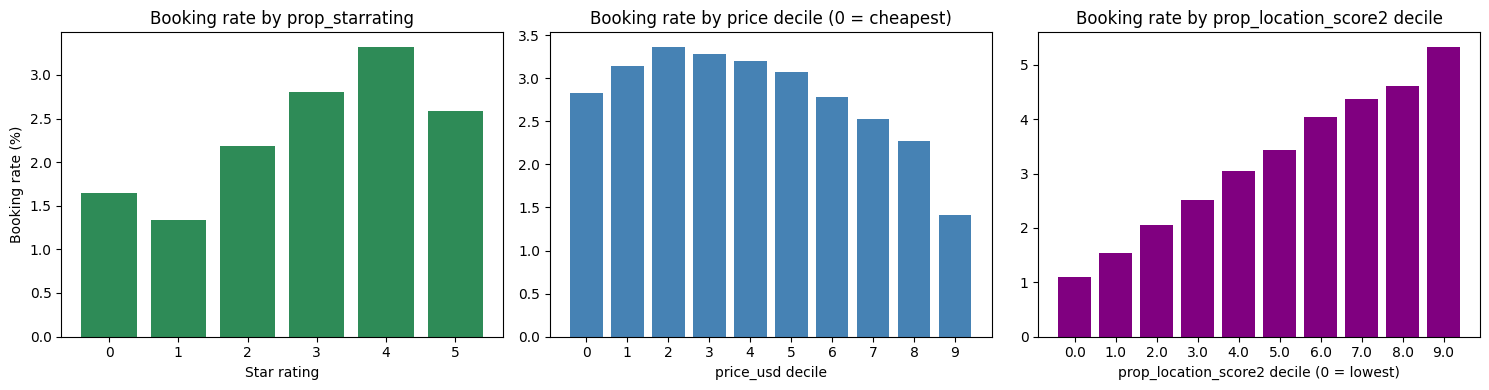

Story hooks for the report:
----------------------------------------------------------------------
  Star rating: rate ranges from 1.33% (worst stars) to 3.32% (best stars).
  Price     : rate ranges from 1.41% to 3.37% across deciles — NOT necessarily monotonic.
  Loc score2: rate ranges from 1.09% (low) to 5.33% (high) — clear positive trend.


In [10]:
# =============================================================================
# Cell 7a — Booking rate by key hotel attributes (predictive signal, 1/3)
# =============================================================================
# Purpose: show how the booking rate (fraction of rows with booking_bool == 1)
# varies across three of the most intuitively predictive hotel attributes:
# star rating, price, and the second location score.
#
# Why this matters for the report:
#   - These plots are the rationale-and-interpretation half of the EDA rubric
#     (worth 10 points). For each panel we want a one-sentence takeaway.
#   - They directly motivate the per-search RELATIVE features we will build
#     in §2.4 (e.g. "price rank within search" — because the absolute price
#     curve is non-monotonic, but rank inside a search should be).
# =============================================================================

# ---- 1) Per-bucket booking rate for each of the three attributes ----------
# `pd.qcut(s, 10, labels=False, duplicates="drop")`
#   pd.qcut bins the series into 10 EQUAL-SIZE quantile buckets (deciles).
#   labels=False returns integer bucket IDs 0..9 (easier to plot than ranges).
#   duplicates="drop" silently merges ties so it doesn't error on heavy ties.
# We use deciles for the continuous columns (price, location score) and the
# raw integer levels for prop_starrating (only 0..5, no binning needed).

price_decile = pd.qcut(
    train["price_usd"], q=10, labels=False, duplicates="drop"
)
loc2_decile = pd.qcut(
    train["prop_location_score2"], q=10, labels=False, duplicates="drop"
)

# `.groupby(key)["booking_bool"].mean()` -> mean of 0/1 = booking rate.
# Multiply by 100 so the y-axis reads as a percentage.
br_by_star  = train.groupby("prop_starrating")["booking_bool"].mean() * 100
br_by_price = train.groupby(price_decile)["booking_bool"].mean() * 100
br_by_loc2  = train.groupby(loc2_decile)["booking_bool"].mean() * 100


# ---- 2) Three side-by-side panels ------------------------------------------
# `sharey=False` keeps each panel's y-axis on its own scale — the magnitudes
# differ enough that a shared scale would flatten two of the three.
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

# Panel 1: star rating
axes[0].bar(br_by_star.index.astype(str), br_by_star.values, color="seagreen")
axes[0].set_title("Booking rate by prop_starrating")
axes[0].set_xlabel("Star rating")
axes[0].set_ylabel("Booking rate (%)")

# Panel 2: price decile
axes[1].bar(br_by_price.index.astype(str), br_by_price.values, color="steelblue")
axes[1].set_title("Booking rate by price decile (0 = cheapest)")
axes[1].set_xlabel("price_usd decile")

# Panel 3: location score 2 decile (rows where it's NaN are silently dropped
# by pd.qcut and therefore by the subsequent groupby).
axes[2].bar(br_by_loc2.index.astype(str), br_by_loc2.values, color="purple")
axes[2].set_title("Booking rate by prop_location_score2 decile")
axes[2].set_xlabel("prop_location_score2 decile (0 = lowest)")

plt.tight_layout()
plt.show()


# ---- 3) Story hooks for the report (one sentence per panel) ---------------
# Print the headline numbers so the report can quote them verbatim.
print("Story hooks for the report:")
print("-" * 70)
print(f"  Star rating: rate ranges from {br_by_star.min():.2f}% (worst stars) "
      f"to {br_by_star.max():.2f}% (best stars).")
print(f"  Price     : rate ranges from {br_by_price.min():.2f}% "
      f"to {br_by_price.max():.2f}% across deciles — NOT necessarily monotonic.")
print(f"  Loc score2: rate ranges from {br_by_loc2.min():.2f}% (low) "
      f"to {br_by_loc2.max():.2f}% (high) — clear positive trend.")


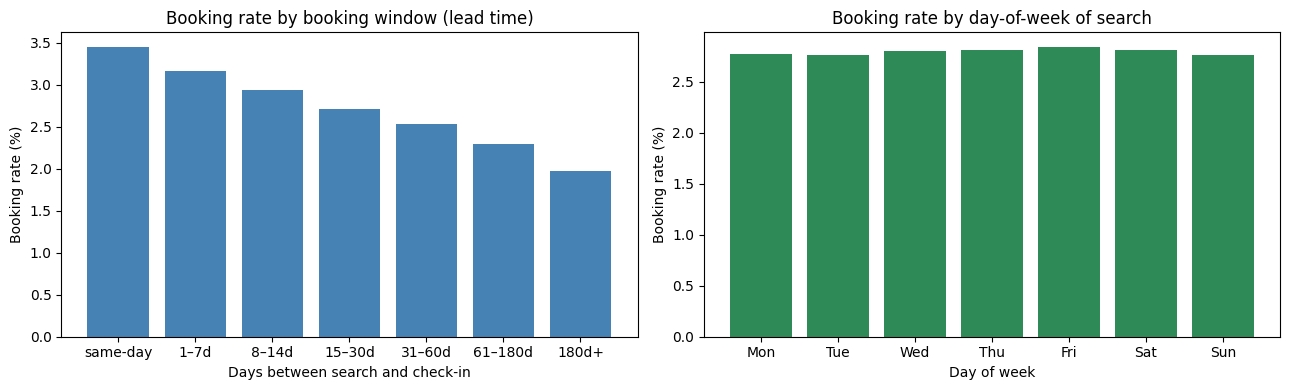

Story hooks for the report:
----------------------------------------------------------------------
  Booking rate vs lead time:
srch_booking_window
same-day    3.45
1–7d        3.17
8–14d       2.93
15–30d      2.72
31–60d      2.53
61–180d     2.30
180d+       1.97

  Booking rate vs day-of-week:
    Mon: 2.77%
    Tue: 2.76%
    Wed: 2.80%
    Thu: 2.81%
    Fri: 2.84%
    Sat: 2.81%
    Sun: 2.76%


In [11]:
# =============================================================================
# Cell 7b — Booking rate by lead time and day-of-week (predictive signal, 2/3)
# =============================================================================
# Purpose: explore the temporal signal in the data. Two views:
#   1) booking rate vs. srch_booking_window (days between search and check-in)
#   2) booking rate vs. day-of-week of the search (Monday..Sunday)
#
# Why: motivates the time features we engineer in §2.3 from date_time.
# A flat curve would mean time features are weak; a clear gradient means
# they are worth including in the LambdaMART feature set in Task 4.
# =============================================================================

# ---- 1) Booking rate by booking-window bucket ------------------------------
# We bucket booking_window into coarser bins (the raw column ranges 0..~500,
# too noisy at one-day granularity). pd.cut with explicit bin edges gives us
# semantically meaningful groups ("same day", "1 week ahead", etc.).
bw_bins   = [-1, 0, 7, 14, 30, 60, 180, 1000]
bw_labels = ["same-day", "1–7d", "8–14d", "15–30d", "31–60d", "61–180d", "180d+"]

# pd.cut(s, bins=..., labels=...) returns a categorical Series.
# include_lowest=True ensures the leftmost bin includes its lower edge.
booking_window_bucket = pd.cut(
    train["srch_booking_window"],
    bins=bw_bins, labels=bw_labels, include_lowest=True,
)
br_by_window = (
    train.groupby(booking_window_bucket, observed=True)["booking_bool"]
    .mean() * 100
).reindex(bw_labels)  # reindex so the bars appear in chronological order


# ---- 2) Booking rate by day-of-week of search ------------------------------
# train["date_time"] is already datetime64 (Cell 2). `.dt.dayofweek` returns
# Monday=0..Sunday=6 as int. We attach human labels for the plot.
dow_int = train["date_time"].dt.dayofweek
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
br_by_dow = (train.groupby(dow_int)["booking_bool"].mean() * 100).reindex(range(7))


# ---- 3) Two side-by-side panels --------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(br_by_window.index.astype(str), br_by_window.values, color="steelblue")
axes[0].set_title("Booking rate by booking window (lead time)")
axes[0].set_xlabel("Days between search and check-in")
axes[0].set_ylabel("Booking rate (%)")

axes[1].bar(dow_labels, br_by_dow.values, color="seagreen")
axes[1].set_title("Booking rate by day-of-week of search")
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("Booking rate (%)")

plt.tight_layout()
plt.show()


# ---- 4) Story hooks for the report -----------------------------------------
print("Story hooks for the report:")
print("-" * 70)
print("  Booking rate vs lead time:")
print(br_by_window.round(2).to_string())
print()
print("  Booking rate vs day-of-week:")
for d, v in zip(dow_labels, br_by_dow.values):
    print(f"    {d}: {v:.2f}%")


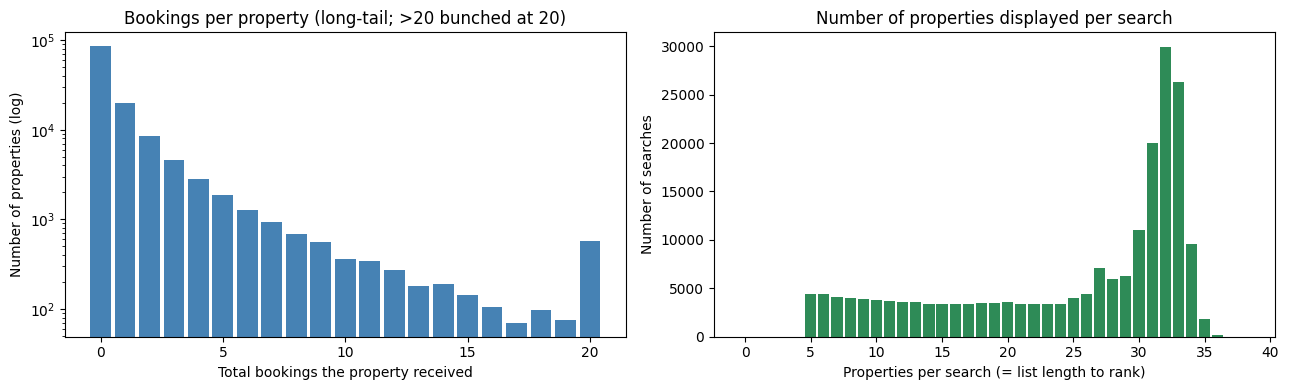

Story hooks for the report:
----------------------------------------------------------------------
  Total unique properties             : 129,113
  Properties with 0 bookings          : 85,685 (66.4%)
  Properties with exactly 1 booking   : 19,711
  Properties with >= 10 bookings      : 2,422
  Bookings share of top-1% properties : 23.1%  (long-tail / cold-start motivation, Lecture 7)

  Properties-per-search distribution:
    min   : 5
    median: 29
    mean  : 24.8
    max   : 38


In [12]:
# =============================================================================
# Cell 7c — Long-tail of property popularity + search size distribution (3/3)
# =============================================================================
# Purpose: characterise two structural properties of the dataset that drive
# our modelling and evaluation choices in §2 and Task 4:
#   1) Distribution of bookings per prop_id — is the popularity "long-tailed"?
#      (Lecture 7 — the long-tail RecSys / cold-start motivation.)
#   2) Distribution of #properties shown per srch_id — sets the "list length"
#      we will be ranking and informs why our train/val split must respect
#      srch_id boundaries (§2.7).
# =============================================================================

# ---- 1) Bookings per property ----------------------------------------------
# `.groupby("prop_id")["booking_bool"].sum()` -> total bookings each hotel got.
# This is the standard long-tail "popularity profile".
bookings_per_prop = train.groupby("prop_id")["booking_bool"].sum()

# Summary numbers for the report
n_props_total     = bookings_per_prop.shape[0]
n_props_zero_book = int((bookings_per_prop == 0).sum())
n_props_one_book  = int((bookings_per_prop == 1).sum())
n_props_many_book = int((bookings_per_prop >= 10).sum())

# Top-1% concentration: what share of all bookings come from the top 1%
# most-booked properties? A high number means the data is HEAVILY skewed.
top1pct_cutoff = bookings_per_prop.quantile(0.99)
top1pct_share  = (
    bookings_per_prop[bookings_per_prop >= top1pct_cutoff].sum()
    / bookings_per_prop.sum() * 100
)


# ---- 2) Properties per search ----------------------------------------------
# Each srch_id has some number of displayed hotels (typically 5–40).
# `.groupby("srch_id").size()` -> series mapping srch_id -> #rows for that search.
props_per_search = train.groupby("srch_id").size()


# ---- 3) Two side-by-side panels --------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 1: bookings-per-property histogram, log y axis (long tail).
# `clip(upper=20)` bunches the tail at 20 so the bars for small counts
# (0, 1, 2, ...) remain visible — without clipping the histogram is dominated
# by the few hyper-popular hotels.
axes[0].hist(bookings_per_prop.clip(upper=20), bins=range(0, 22),
             color="steelblue", align="left", rwidth=0.85)
axes[0].set_yscale("log")
axes[0].set_title("Bookings per property (long-tail; >20 bunched at 20)")
axes[0].set_xlabel("Total bookings the property received")
axes[0].set_ylabel("Number of properties (log)")

# Panel 2: properties-per-search distribution.
axes[1].hist(props_per_search, bins=range(0, int(props_per_search.max()) + 2),
             color="seagreen", align="left", rwidth=0.85)
axes[1].set_title("Number of properties displayed per search")
axes[1].set_xlabel("Properties per search (= list length to rank)")
axes[1].set_ylabel("Number of searches")

plt.tight_layout()
plt.show()


# ---- 4) Story hooks for the report -----------------------------------------
print("Story hooks for the report:")
print("-" * 70)
print(f"  Total unique properties             : {n_props_total:,}")
print(f"  Properties with 0 bookings          : {n_props_zero_book:,} "
      f"({n_props_zero_book / n_props_total * 100:.1f}%)")
print(f"  Properties with exactly 1 booking   : {n_props_one_book:,}")
print(f"  Properties with >= 10 bookings      : {n_props_many_book:,}")
print(f"  Bookings share of top-1% properties : {top1pct_share:.1f}%  "
      f"(long-tail / cold-start motivation, Lecture 7)")
print()
print("  Properties-per-search distribution:")
print(f"    min   : {int(props_per_search.min())}")
print(f"    median: {int(props_per_search.median())}")
print(f"    mean  : {props_per_search.mean():.1f}")
print(f"    max   : {int(props_per_search.max())}")


#### §2 — Task 3: Data Preparation and Feature Engineering

In this section we transform the raw training table into a clean, model-ready
feature matrix. We follow Lecture 2's data-preparation workflow:

1. **Handle outliers** in price-like columns (the `price_usd` max of $19.7M
   confirmed in §1 is a strong signal we need a log transform).
2. **Handle missing values** in the columns flagged in §1 — primarily the
   competitor block, `visitor_hist_*`, `orig_destination_distance`, and
   `prop_location_score2`.
3. **Engineer new features**: per-property aggregates (mean booking
   probability, average price), per-search context (price rank within search,
   price gap vs. search median), and competitor summaries (count of cheaper
   competitors, mean rate-diff).
4. **Time features** extracted from `date_time` (hour of day, day of week,
   month).
5. **Train / validation split** that respects search-query grouping — rows
   from the same `srch_id` must stay together so we don't leak label
   information across the split.

> *Tip for the report:* the rubric awards 5 points for "Dataset pre-processing
> (replicable process of feature engineering)" and 5 for "Rationale for feature
> engineering" — every transformation we apply should be paired with one
> sentence in the report explaining *why* we did it.


##### §2.1 — Price outliers and the log transformation

The descriptive statistics in §1 showed `price_usd` ranging from $0 to **$19.7
million**, while the median is $122 and the 99th percentile is around $500.
A handful of broken rows would otherwise dominate any model's loss function
and squash sensible prices into one indistinguishable bin.

The textbook fix (Lecture 2 — "Transformations") is:

1. Apply a **log transform** `log(1 + price_usd)` to compress the heavy right
   tail. The resulting distribution is roughly normal — the natural shape for
   prices in the report (also visible in Cell 6, Panel 0,1).
2. Additionally **clip** the raw column at the 99.9th percentile as defensive
   cleanup of obviously broken records, so derived per-search features like
   "price rank within search" aren't poisoned by a single $19M row.

We deliberately keep the raw `price_usd` column too — it will be used to build
**relative** price features (e.g. "price rank within search") in §2.4, where
the absolute scale doesn't matter.


price_usd percentiles BEFORE transformation:
--------------------------------------------------
  P 50.0: $        122.00
  P 90.0: $        277.00
  P 99.0: $        599.00
  P 99.9: $      2,060.04
  P100.0: $ 19,726,328.00

Clipping threshold (99.9th percentile): $2,060.04

Distribution summary — raw vs clipped vs log:
------------------------------------------------------------
          price_usd  price_usd_clipped  price_usd_log
count  4.958347e+06        4958347.000    4958347.000
mean   2.542100e+02            155.177          4.856
std    1.600124e+04            129.731          0.615
min    0.000000e+00              0.000          0.000
25%    8.500000e+01             85.000          4.454
50%    1.220000e+02            122.000          4.812
75%    1.849600e+02            184.960          5.226
max    1.972633e+07           2060.036         16.797


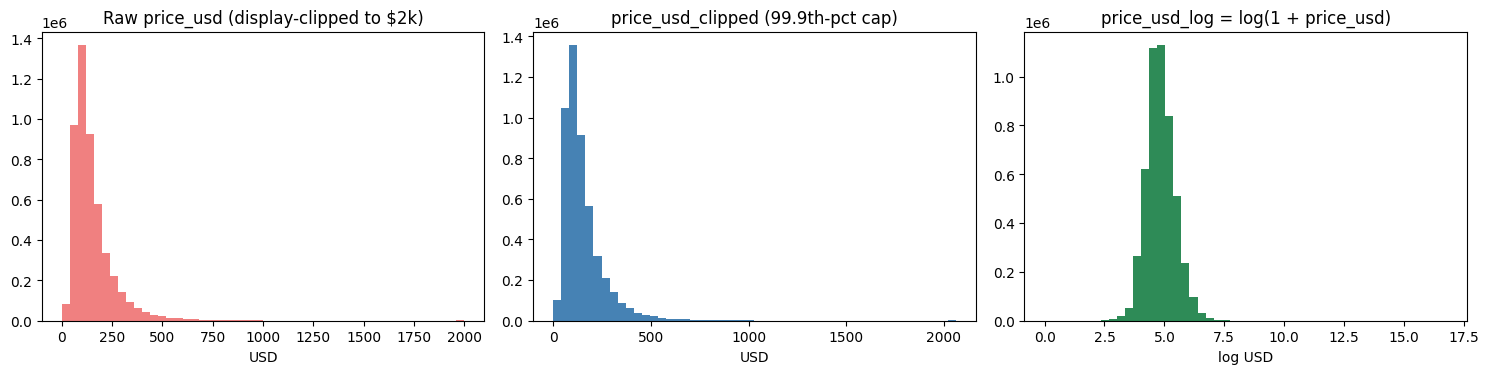

In [13]:
# =============================================================================
# Cell 8 — Price transformation (log + percentile clip)
# =============================================================================
# Purpose: tame the heavy right tail of `price_usd` by adding two derived
# columns:
#   - `price_usd_log`     = log(1 + price_usd)   ← the modelling-friendly form
#   - `price_usd_clipped` = price_usd capped at the 99.9th percentile
#
# We do NOT modify the original `price_usd` column — it's still useful when we
# compute relative features (e.g. price-rank-within-search) in §2.4 where the
# raw values matter.
#
# Important: the SAME transformation must be re-applied to the test set later
# (Task 4) using the SAME 99.9th-percentile clip threshold computed here.
# We therefore store the threshold in a variable so we can reuse it.
# =============================================================================


# ---- 1) Quantify the tail before transformation ----------------------------
# `Series.quantile([...])` accepts a list of fractions in [0, 1] and returns
# the corresponding percentile values. Useful for sanity-checking how extreme
# the tail actually is.
price_percentiles = train["price_usd"].quantile([0.50, 0.90, 0.99, 0.999, 1.00])

print("price_usd percentiles BEFORE transformation:")
print("-" * 50)
for q, val in price_percentiles.items():
    print(f"  P{q*100:>5.1f}: ${val:>14,.2f}")
print()


# ---- 2) Build the log-transformed column -----------------------------------
# `np.log1p(x)` computes log(1 + x). The +1 keeps the function defined when
# price is 0 (rare but present — likely free / complimentary nights).
# `.astype('float32')` keeps the new column at the same memory footprint as
# the rest of the optimised numeric columns.
train["price_usd_log"] = np.log1p(train["price_usd"]).astype("float32")


# ---- 3) Build the clipped column -------------------------------------------
# `np.clip(arr, lower, upper)` caps values to a [lower, upper] interval.
# We only need an upper bound here, so the lower bound is `None`.
# We save the threshold in a variable because the SAME number must be used
# when transforming the test set (otherwise we'd be applying a different
# preprocessing rule at training vs inference time — a classic data leakage
# / mismatch bug).
PRICE_CLIP_THRESHOLD = float(price_percentiles[0.999])

train["price_usd_clipped"] = np.clip(
    train["price_usd"],
    a_min=None,
    a_max=PRICE_CLIP_THRESHOLD,
).astype("float32")

print(f"Clipping threshold (99.9th percentile): ${PRICE_CLIP_THRESHOLD:,.2f}")
print()


# ---- 4) Compare distributions: raw vs clipped vs log ----------------------
# `.describe()` returns count, mean, std, min, quartiles, max for each Series.
# Bundling three columns side-by-side makes the effect of each transform
# immediately visible.
summary = pd.DataFrame({
    "price_usd":          train["price_usd"].describe(),
    "price_usd_clipped":  train["price_usd_clipped"].describe(),
    "price_usd_log":      train["price_usd_log"].describe(),
}).round(3)

print("Distribution summary — raw vs clipped vs log:")
print("-" * 60)
print(summary.to_string())


# ---- 5) Side-by-side histograms (visual confirmation) ---------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: raw price (display-clipped at $2k just so the bulk is visible;
# the actual data still has the $19.7M outliers).
axes[0].hist(train["price_usd"].clip(upper=2000), bins=50, color="lightcoral")
axes[0].set_title("Raw price_usd (display-clipped to $2k)")
axes[0].set_xlabel("USD")

# Panel 2: percentile-clipped version — what we'll use in tree-based models.
axes[1].hist(train["price_usd_clipped"], bins=50, color="steelblue")
axes[1].set_title("price_usd_clipped (99.9th-pct cap)")
axes[1].set_xlabel("USD")

# Panel 3: log-transformed version — what we'll use in the linear baseline.
axes[2].hist(train["price_usd_log"], bins=50, color="seagreen")
axes[2].set_title("price_usd_log = log(1 + price_usd)")
axes[2].set_xlabel("log USD")

plt.tight_layout()
plt.show()


##### §2.2 — Missing-value handling

The missingness overview in Cell 3 flagged five blocks of NaN we need to address before any model can use the data. Following Lecture 2's missing-value workflow, we treat each block according to *why* the data is missing, not with a blanket rule:

| Column block | % missing | Most likely reason | Strategy |
|---|---|---|---|
| `visitor_hist_starrating`, `visitor_hist_adr_usd` | ~95% | User has no booking history on Expedia (new / anonymous visitor) | Sentinel **−1** *and* add a `has_visitor_history` flag |
| `prop_location_score2` | ~22% | Expedia could not compute the second location score for that property | **Per-destination median** with global-median fallback |
| `orig_destination_distance` | ~32% | Origin city not resolved (e.g. not logged in, mobile without GPS) | **Per-destination median** with global-median fallback |
| `prop_review_score` | ~0.15% | Brand-new property with no reviews yet | **Global median** (too few rows to justify fancier) |
| `srch_query_affinity_score` | ~93% | No matching internet-search signal for the query/hotel pair | Sentinel **`min − 1`** (below any real value) + `has_query_affinity` flag |
| `comp1_rate` … `comp8_rate` (+ `_inv`, `_rate_percent_diff`) | 60–97% | No live competitor quote at search time | **0** (neutral; we will collapse all 24 into summary features in §2.6) |

**Why not just drop the columns?** Two of them (`prop_location_score2`, `orig_destination_distance`) were among the strongest features in the ICDM 2013 winners' reports (Task 1 related-work section). Cell 7a confirmed this empirically — `prop_location_score2` had the biggest booking-rate spread of any feature. Dropping it would throw away the strongest signal in the data.

**Why a sentinel for `visitor_hist_*` instead of the mean?** A user with no booking history is *qualitatively* different from one whose history happens to average to the column mean. Trees can split on `< 0` to isolate the no-history group cleanly; mean-imputation would blur that boundary into the middle of the distribution.

**Why per-destination median rather than global median for the two scored columns?** Both quantities are largely a property of the destination (markets differ in pricing patterns and resolved-origin coverage). The per-destination median preserves that variation; the global fallback only kicks in for the rare destination where every row is NaN.

We deliberately leave `gross_bookings_usd` untouched — it is a training-only label that is NaN by construction whenever `booking_bool == 0`. Imputing it would inject a bogus signal. It is dropped before modelling.


In [14]:
# =============================================================================
# Cell 9 — Missing-value imputation (Lecture 2: data preparation)
# =============================================================================
# Purpose: fill the NaN values for the missing-value blocks identified in
# Cell 3. Each block gets its OWN rule grounded in *why* the value is missing
# — a textbook Lecture-2 distinction between "missing at random" (impute with
# a central tendency) and "missing not at random" (use a sentinel / indicator).
#
# Blocks handled below:
#   1) visitor_hist_*           : sentinel -1 + boolean indicator
#   2) prop_location_score2     : per-destination median, global-median fallback
#   3) orig_destination_distance: per-destination median, global-median fallback
#   4) prop_review_score        : global median (tiny missingness)
#   5) srch_query_affinity_score: sentinel "very low" + boolean indicator
#   6) comp1..8 columns         : fill 0 (will be summarised in §2.6 anyway)
#
# We DELIBERATELY leave `gross_bookings_usd` NaN — it is a training-only
# label that is NaN by construction whenever booking_bool == 0. It will be
# dropped before modelling; imputing it would silently inject a bogus signal.
# =============================================================================

# ---- 1) visitor_hist_* : sentinel -1 + boolean indicator -------------------
# A user with NO booking history on Expedia is QUALITATIVELY different from
# one who happens to average to the column mean. Using -1 lets a tree model
# split on "< 0" to isolate the no-history group cleanly. The explicit boolean
# flag means a linear model can also use the signal (it can't infer "-1 means
# missing" from a continuous range without help).
train["has_visitor_history"] = train["visitor_hist_starrating"].notna().astype("int8")
train["visitor_hist_starrating"] = (
    train["visitor_hist_starrating"].fillna(-1).astype("float32")
)
train["visitor_hist_adr_usd"] = (
    train["visitor_hist_adr_usd"].fillna(-1).astype("float32")
)


# ---- 2) prop_location_score2 : per-destination median ---------------------
# Cell 7a showed prop_location_score2 has the strongest booking-rate signal
# of any feature (1.09% -> 5.33% across deciles). We CANNOT afford to drop
# the 22% of rows where it is NaN. The right fill here is the median of OTHER
# hotels in the SAME destination — that captures "what a typical location
# score looks like in this market" without leaking the booked outcome.
# `.transform("median")` runs the groupby aggregation and BROADCASTS the
# per-group median back to every row in that group (same shape as the input).
# The second `.fillna(...)` is a safety net for destinations where every row
# is NaN — we fall back to the global median.
global_loc2_median = train["prop_location_score2"].median()
per_dest_loc2_median = (
    train.groupby("srch_destination_id")["prop_location_score2"]
    .transform("median")
)
train["prop_location_score2"] = (
    train["prop_location_score2"]
    .fillna(per_dest_loc2_median)
    .fillna(global_loc2_median)
    .astype("float32")
)


# ---- 3) orig_destination_distance : per-destination median ---------------
# Missing here usually means the user's origin city couldn't be resolved
# (no login, mobile without geo, etc.). The same per-destination logic works:
# distance is largely a property of the destination once we group by it.
global_distance_median = train["orig_destination_distance"].median()
per_dest_distance_median = (
    train.groupby("srch_destination_id")["orig_destination_distance"]
    .transform("median")
)
train["orig_destination_distance"] = (
    train["orig_destination_distance"]
    .fillna(per_dest_distance_median)
    .fillna(global_distance_median)
    .astype("float32")
)


# ---- 4) prop_review_score : global median ---------------------------------
# Only ~0.15% of rows are missing this — too small to justify a fancy fill.
# We use the global median (more robust to outliers than the mean) and don't
# bother with a flag.
train["prop_review_score"] = (
    train["prop_review_score"]
    .fillna(train["prop_review_score"].median())
    .astype("float32")
)


# ---- 5) srch_query_affinity_score : "very low" sentinel + indicator -------
# This column is the LOG of the probability of a hotel being clicked for the
# given query — so values are negative, and bigger (closer to 0) is better.
# Missing means "Expedia has no signal from internet searches" — i.e. the
# affinity is effectively unknown / very low. We fill with min - 1 so the
# imputed value sits BELOW any real observation and trees can split it off
# cleanly. The accompanying indicator preserves the signal for linear models.
train["has_query_affinity"] = train["srch_query_affinity_score"].notna().astype("int8")
sqa_min = float(train["srch_query_affinity_score"].min())
train["srch_query_affinity_score"] = (
    train["srch_query_affinity_score"].fillna(sqa_min - 1.0).astype("float32")
)


# ---- 6) comp1..8 columns : fill with 0 ------------------------------------
# These are sparse (60-97% NaN) because Expedia rarely had a live competitor
# quote at search time. NaN means "no signal", and the columns themselves
# encode a 3-way categorical relationship around 0:
#   comp{N}_rate           : -1 = Expedia cheaper, 0 = same, 1 = more expensive
#   comp{N}_inv            :  0 = competitor has inventory, 1 = doesn't
#   comp{N}_rate_percent_diff : percent difference (0 = no gap)
# So 0 is the neutral / "no signal" value in all three sub-columns.
# We will collapse all 24 into compact summary features in §2.6 — this is
# just defensive cleanup so downstream code doesn't choke on NaN.
comp_cols = [
    f"comp{i}_{kind}"
    for i in range(1, 9)
    for kind in ["rate", "inv", "rate_percent_diff"]
]
train[comp_cols] = train[comp_cols].fillna(0).astype("float32")


# ---- 7) Verify --------------------------------------------------------------
# Re-check the columns we just touched. Everything except gross_bookings_usd
# should now be NaN-free.
columns_we_imputed = [
    "visitor_hist_starrating", "visitor_hist_adr_usd",
    "prop_location_score2", "orig_destination_distance",
    "prop_review_score", "srch_query_affinity_score",
] + comp_cols

remaining = train[columns_we_imputed].isna().sum()
remaining_nonzero = remaining[remaining > 0]

print("Missing-value imputation summary")
print("-" * 60)
if remaining_nonzero.empty:
    print("All imputed columns are now NaN-free.")
else:
    print("Still has NaN — check the fallback logic:")
    print(remaining_nonzero.to_string())
print()
print("New indicator columns added:")
print(f"  has_visitor_history : sum = {int(train['has_visitor_history'].sum()):,} "
      f"({train['has_visitor_history'].mean()*100:.2f}% of rows have history)")
print(f"  has_query_affinity  : sum = {int(train['has_query_affinity'].sum()):,} "
      f"({train['has_query_affinity'].mean()*100:.2f}% of rows have affinity)")
print()
print("`gross_bookings_usd` deliberately left as-is (training-only label):")
print(f"  NaN count: {int(train['gross_bookings_usd'].isna().sum()):,} "
      f"(should equal #rows where booking_bool == 0)")


Missing-value imputation summary
------------------------------------------------------------
All imputed columns are now NaN-free.

New indicator columns added:
  has_visitor_history : sum = 251,866 (5.08% of rows have history)
  has_query_affinity  : sum = 317,406 (6.40% of rows have affinity)

`gross_bookings_usd` deliberately left as-is (training-only label):
  NaN count: 4,819,957 (should equal #rows where booking_bool == 0)


In [15]:
# =============================================================================
# Cell 9b — Reconstruct has_* indicators (defensive, idempotent)
# =============================================================================
# Cell 9 has a subtle non-idempotency: it computes the has_* indicators AFTER
# (potentially) having already filled the column with the sentinel on an
# earlier run. If Cell 9 runs twice (e.g. via "Run All Below"), the second
# run sees no NaN and produces a useless "all 1s" indicator.
#
# This cell defensively reconstructs the indicators from the already-imputed
# columns by detecting the sentinel value. It is fully idempotent — running
# it any number of times produces the same result.
# =============================================================================

# `visitor_hist_*` was filled with sentinel value -1. Real star ratings live
# in [0, 5] and real average-daily-rates in [0, infinity), so -1 is a unique
# sentinel that never collides with real data. Any -1 is therefore the
# "no history" marker; anything else is a real visitor-history record.
train["has_visitor_history"] = (
    train["visitor_hist_starrating"] != -1
).astype("int8")

# `srch_query_affinity_score` was filled with `min(real) - 1`, which after the
# fill IS the minimum of the column. So rows AT the minimum are exactly the
# imputed ones; everything else is a real signal.
sqa_min = float(train["srch_query_affinity_score"].min())
train["has_query_affinity"] = (
    train["srch_query_affinity_score"] != sqa_min
).astype("int8")

print("Indicator columns reconstructed:")
print(f"  has_visitor_history : sum = {int(train['has_visitor_history'].sum()):,} "
      f"({train['has_visitor_history'].mean()*100:.2f}% of rows have history)")
print(f"  has_query_affinity  : sum = {int(train['has_query_affinity'].sum()):,} "
      f"({train['has_query_affinity'].mean()*100:.2f}% of rows have affinity)")


Indicator columns reconstructed:
  has_visitor_history : sum = 251,866 (5.08% of rows have history)
  has_query_affinity  : sum = 317,406 (6.40% of rows have affinity)


##### §2.3 — Time features from `date_time`

Cell 2 already parsed `date_time` into a true `datetime64` column. We now extract four time-of-search features:

| Feature | Range | Why |
|---|---|---|
| `search_hour` | 0..23 | Hour of day captures business-traveller vs. leisure patterns (lunchtime vs. evening searches behave differently). |
| `search_dayofweek` | 0..6 | Monday=0..Sunday=6. Cell 7b showed this is **weak on its own** (booking-rate spread of 0.08pp), but we keep it because trees can use it in interaction with other features (e.g. is the *search* day the same as the *check-in* day?). |
| `search_month` | 1..12 | Captures the seasonal travel cycle (the data spans Nov 2012–Jun 2013, so months 11, 12, 1–6 are present). |
| `search_is_weekend` | 0/1 | Derived shortcut: 1 when the search itself happens on Sat or Sun. Useful for the linear baseline (it can't synthesise the combination from dayofweek alone). |

We **deliberately keep `srch_booking_window` as the raw integer** — LightGBM (our main model) finds its own split thresholds, and Cell 7b confirmed the booking-rate curve was monotonic in `srch_booking_window`. Bucketing would throw away that resolution. We bucketed it in Cell 7b only for the histogram.

Note: we do **not** add sine/cosine cyclical encoding here. It helps linear models with cyclical features (so the linear baseline in §3 might benefit), but tree models split on raw values directly. If the linear baseline performs poorly on time features we can revisit this.


In [16]:
# =============================================================================
# Cell 10 — Time features from date_time
# =============================================================================
# Purpose: derive four datetime-based features from the `date_time` column
# that was parsed as `datetime64` back in Cell 2. These are the features that
# Cell 7b's predictive-signal EDA motivated (lead-time effect was strong;
# day-of-week was weak but we keep it for tree interactions).
#
# All four are stored as `int8` so they cost 1 byte per row — adding ~5 MB
# to the in-memory size of the 5M-row DataFrame.
# =============================================================================

# `train["date_time"]` is already datetime64 (Cell 2 used parse_dates).
# The `.dt` accessor exposes datetime components on a Series:
#   .dt.hour       -> integer 0..23
#   .dt.dayofweek  -> integer 0..6  (Monday = 0, Sunday = 6)
#   .dt.month      -> integer 1..12
# These are vectorised and run in milliseconds even on 5M rows.

train["search_hour"]      = train["date_time"].dt.hour.astype("int8")
train["search_dayofweek"] = train["date_time"].dt.dayofweek.astype("int8")
train["search_month"]     = train["date_time"].dt.month.astype("int8")

# `search_is_weekend` is a derived binary shortcut: 1 if the search itself
# happened on Saturday (5) or Sunday (6), else 0. A linear model cannot
# synthesise this from dayofweek alone (you would need a one-hot per day);
# trees CAN but the shortcut is essentially free to compute and improves
# the baseline's chances of catching the weekend signal.
train["search_is_weekend"] = (train["search_dayofweek"] >= 5).astype("int8")


# ---- Verification ----------------------------------------------------------
# Print ranges and a small sanity stat per new feature. If anything is wrong
# (e.g. a feature is constant or out of expected range) we want to see it now.
print("Time features added:")
print("-" * 60)
print(f"  search_hour      : range {int(train['search_hour'].min()):>2}..{int(train['search_hour'].max()):>2}")
print(f"  search_dayofweek : range {int(train['search_dayofweek'].min())}..{int(train['search_dayofweek'].max())}  "
      f"(Mon=0..Sun=6)")
print(f"  search_month     : months present = "
      f"{sorted(train['search_month'].unique().tolist())}")
print(f"  search_is_weekend: {train['search_is_weekend'].mean()*100:.2f}% of rows are Sat/Sun searches")

# Spot-check: a typical week should have ~28.6% weekend (2/7 days), so the
# print above should land near that number — confirms the column is sensible.


Time features added:
------------------------------------------------------------
  search_hour      : range  0..23
  search_dayofweek : range 0..6  (Mon=0..Sun=6)
  search_month     : months present = [1, 2, 3, 4, 5, 6, 11, 12]
  search_is_weekend: 24.39% of rows are Sat/Sun searches


##### §2.4 — Per-search relative features

The single most important insight for ranking tasks is that the model should not look at a hotel in isolation — it should look at how that hotel **compares to the other hotels in the same search**. A $200 hotel is expensive in a list of $80 hostels but cheap in a list of luxury resorts; only the relative position carries information.

The assignment PDF makes this hint explicit:
> *"you might want to compare the different properties that resulted from the search instead of learning from them one by one."*

ICDM 2013 winners reported per-search relative features as their **top-importance** predictors. Cell 7a backed this up empirically — the absolute price decile produced a near-flat booking-rate curve, but we know intuitively that *being the cheapest in your search* is a strong booking signal.

We build two flavours of relative feature, in two cells:

| Cell | Relative-to-search features |
|---|---|
| **11** | `price_usd_rank_in_search`, `price_usd_gap_vs_search_median`, `price_usd_zscore_in_search` |
| **12** | `prop_starrating_rank_in_search`, `prop_location_score2_rank_in_search`, `prop_review_score_rank_in_search` |

Each rank is normalised to **[0, 1]** within the search (`method="dense"`, divided by the search's row count) so a 5-hotel search and a 38-hotel search produce comparable numbers. The model can then learn rules like *"book hotels in the bottom 30% of price within the search"* that generalise across different search list lengths.

**Why we use `price_usd_clipped` and not the raw column for relative price:** the $19.7M outlier we saw in Cell 5 would otherwise blow up the per-search z-score for searches that happened to contain it.


In [17]:
# =============================================================================
# Cell 11 — Per-search relative PRICE features
# =============================================================================
# Purpose: build three "where does this hotel sit, price-wise, within this
# search" features. These are the listwise-comparison signals that Lecture 7
# (Recommender Systems / Learning-to-Rank) flags as most useful for ranking
# tasks. Cell 7a showed the absolute price decile was near-flat, but relative
# position within a search should be strongly predictive.
#
# Features built:
#   1) price_usd_rank_in_search       : 0..1 normalised rank within the search
#                                        (0 = cheapest in this search)
#   2) price_usd_gap_vs_search_median : price - median(price) within search
#   3) price_usd_zscore_in_search     : (price - mean) / std within search
#
# We use `price_usd_clipped` (the 99.9-percentile-capped column built in
# Cell 8) instead of the raw column, so the rare $19.7M outlier rows don't
# poison the per-search mean / median / std.
# =============================================================================

import time
t0 = time.time()

# `.groupby(col)["other_col"]` returns a "SeriesGroupBy" — it partitions the
# `price_usd_clipped` column by srch_id without materialising the groups in
# memory. We reuse it for all three features.
# `sort=False` skips an internal sort of group keys we don't need; saves time.
grp = train.groupby("srch_id", sort=False)["price_usd_clipped"]


# ---- 1) Rank within search, normalised to [0, 1] --------------------------
# `.rank(method="average", pct=True)` returns the rank as a FRACTION of group
# size — exactly what we want. A 5-hotel search and a 38-hotel search then
# produce comparable numbers.
#   method="average" : ties share the average rank (the standard default).
#   pct=True         : divides each rank by the size of its group.
# Cheapest hotel in a search gets a rank near 0, most expensive near 1.
train["price_usd_rank_in_search"] = grp.rank(
    method="average", pct=True
).astype("float32")


# ---- 2) Gap vs the search median ------------------------------------------
# `.transform("median")` computes the per-group median and BROADCASTS it back
# to every row in the group — output Series has the same shape as `train`.
# Subtracting gives a signed gap: negative if this hotel is cheaper than its
# search's median, positive if more expensive.
# Median (vs. mean) is more robust to within-search outliers.
train["price_usd_gap_vs_search_median"] = (
    train["price_usd_clipped"] - grp.transform("median")
).astype("float32")


# ---- 3) z-score within search ---------------------------------------------
# (price - search_mean) / search_std — measures how extreme this price is
# relative to the spread within its own search. Two transforms then combine.
mean_in_search = grp.transform("mean")
std_in_search  = grp.transform("std")

# Edge cases:
#   - Search has 1 hotel  -> std is NaN (need >=2 values for std).
#   - Search has all-equal prices -> std == 0 -> division gives NaN (0/0).
# `.fillna(0)` catches both: a "no relative deviation" signal of 0.
train["price_usd_zscore_in_search"] = (
    ((train["price_usd_clipped"] - mean_in_search) / std_in_search)
    .fillna(0)
    .astype("float32")
)

elapsed = time.time() - t0
print(f"Per-search relative price features built in {elapsed:.1f} seconds.")
print()


# ---- 4) Spot-check on one real search ------------------------------------
# Pull the first search in the DataFrame and confirm the three new columns
# make sense relative to the raw clipped price.
sample_srch = int(train["srch_id"].iloc[0])
sample = (
    train[train["srch_id"] == sample_srch][[
        "srch_id", "prop_id", "price_usd_clipped",
        "price_usd_rank_in_search",
        "price_usd_gap_vs_search_median",
        "price_usd_zscore_in_search",
    ]]
    .sort_values("price_usd_clipped")
    .round(4)
)

print(f"Spot-check on srch_id = {sample_srch} (sorted by clipped price):")
print("-" * 80)
print(sample.to_string(index=False))
print()


# ---- 5) Global summary stats ---------------------------------------------
# Sanity-check the distributions across all 5M rows:
#   - rank should be roughly uniform on [0, 1] with mean ~0.5
#   - gap_vs_median should center near 0
#   - zscore should center near 0
print("Distribution summary across the whole training set:")
print("-" * 80)
print(
    train[[
        "price_usd_rank_in_search",
        "price_usd_gap_vs_search_median",
        "price_usd_zscore_in_search",
    ]]
    .describe()
    .round(3)
    .to_string()
)


Per-search relative price features built in 4.5 seconds.

Spot-check on srch_id = 1 (sorted by clipped price):
--------------------------------------------------------------------------------
 srch_id  prop_id  price_usd_clipped  price_usd_rank_in_search  price_usd_gap_vs_search_median  price_usd_zscore_in_search
       1    50984          85.370003                    0.0357                      -53.680000                     -0.8131
       1    85728         100.889999                    0.1071                      -38.160000                     -0.6521
       1    68914         100.889999                    0.1071                      -38.160000                     -0.6521
       1    59526         100.889999                    0.1071                      -38.160000                     -0.6521
       1      893         104.769997                    0.1964                      -34.279999                     -0.6118
       1   114766         104.769997                    0.1964        

In [18]:
# =============================================================================
# Cell 12 — Per-search relative QUALITY features
# =============================================================================
# Purpose: same listwise-comparison idea as Cell 11, but applied to three
# quality columns instead of price. For each hotel we compute its 0..1 rank
# within the search on:
#   - prop_starrating         (the hotel's star rating, 0..5)
#   - prop_location_score2    (the strongest individual signal from Cell 7a)
#   - prop_review_score       (mean customer review score 0..5)
#
# All three are stored as float32. Rank is normalised to [0, 1] within the
# search via `pct=True`, exactly like the price rank in Cell 11.
#
# We deliberately do NOT add z-score / gap features for the quality columns,
# only the rank. Reason: star rating is integer-valued with only 6 levels;
# its in-search z-score is dominated by ties and is much less informative
# than the rank. Same for review_score (rounded to 0.5). location_score2
# could support z-score, but the marginal value over rank is small and we
# want to keep the feature matrix lean for now. We can revisit if Task 4
# feature-importance says otherwise.
# =============================================================================

import time
t0 = time.time()

# Triple of columns to process — identical pipeline applied to each.
# `pct=True` so the result is a 0..1 fraction of group size within srch_id.
# `method="average"` so ties share the mean rank (the standard default).
QUALITY_COLS = ["prop_starrating", "prop_location_score2", "prop_review_score"]

# Build the GroupBy ONCE on the full DataFrame, then select each column
# from it in the loop below. This avoids re-partitioning the table three
# times — `train.groupby(...)` is the expensive step.
grouped = train.groupby("srch_id", sort=False)

for col in QUALITY_COLS:
    # Per-group rank of the column, normalised to [0, 1].
    new_col = f"{col}_rank_in_search"
    train[new_col] = grouped[col].rank(
        method="average", pct=True
    ).astype("float32")

elapsed = time.time() - t0
print(f"Per-search relative quality features built in {elapsed:.1f} seconds.")
print()


# ---- Spot-check on the same sample search as Cell 11 ----------------------
sample_srch = int(train["srch_id"].iloc[0])

sample_cols = ["srch_id", "prop_id"] + [
    c for col in QUALITY_COLS for c in (col, f"{col}_rank_in_search")
]
sample = (
    train[train["srch_id"] == sample_srch][sample_cols]
    .sort_values("prop_starrating", ascending=False)
    .round(4)
)
print(f"Spot-check on srch_id = {sample_srch} (sorted by star rating, descending):")
print("-" * 100)
print(sample.to_string(index=False))
print()


# ---- Global summary ------------------------------------------------------
# Each rank column should be roughly uniform on [0, 1] (mean ~0.5).
# A slight upward bias is expected for star rating because integer ties
# pull average ranks toward the upper end of each tied group.
summary_cols = [f"{c}_rank_in_search" for c in QUALITY_COLS]
print("Distribution summary across the whole training set:")
print("-" * 90)
print(train[summary_cols].describe().round(3).to_string())


Per-search relative quality features built in 4.7 seconds.

Spot-check on srch_id = 1 (sorted by star rating, descending):
----------------------------------------------------------------------------------------------------
 srch_id  prop_id  prop_starrating  prop_starrating_rank_in_search  prop_location_score2  prop_location_score2_rank_in_search  prop_review_score  prop_review_score_rank_in_search
       1    10404                4                          0.8571                0.0149                               0.2857                4.0                            0.6964
       1    29604                4                          0.8571                0.1241                               0.8929                3.5                            0.3929
       1    30184                4                          0.8571                0.1302                               1.0000                4.5                            0.9286
       1    95307                4                          

##### §2.5 — Per-property aggregates (non-leaky)

Cell 12 gave the model **within-search** rank features. §2.5 adds **across-search** aggregates: for each `prop_id`, summary statistics computed over every row in the training set where that hotel appears. This complements the rank features with a kind of "global reputation" signal — a hotel that always shows up at a relatively low price has a different signature than one whose price swings wildly per search.

| Feature | What it captures |
|---|---|
| `prop_id_count` | how often this hotel was displayed in training |
| `prop_id_price_mean` | the hotel's mean displayed price across all searches it appeared in |
| `prop_id_price_std` | how much its displayed price varies across searches |
| `prop_id_location_score2_mean` | the hotel's typical location-score-2 across searches |

**Why we skip booking-rate aggregates here.** A naive `mean(booking_bool)` per `prop_id` computed across the *whole* training set and then used as a feature is a textbook target leak — the value for each row depends on that row's own label. We will compute booking-rate aggregates in §2.7 **only on the training portion** of the split, then merge into both training and validation portions.

**About cold-start hotels.** Cell 7c showed that 66.4% of properties received zero bookings in training. For these, our aggregates here will look "normal" (price/star stats are well-defined whether or not a booking occurred); the cold-start ambiguity only affects booking-rate features, which is why we defer those to §2.7.


In [19]:
# =============================================================================
# Cell 13 — Per-property aggregates (non-leaky)
# =============================================================================
# Purpose: build 4 across-search summary statistics per prop_id, then merge
# them back as new columns on `train`. These are the "global reputation"
# features that complement the within-search rank features from Cells 11-12.
#
# We deliberately use only PRICE / LOCATION / COUNT aggregates here — NOT
# booking-rate. Booking-rate is the target signal and would leak if computed
# over the whole training set, so we defer it to §2.7 (after the train/val
# split).
#
# We also keep the aggregates DataFrame in a separate variable so we can
# re-apply the SAME numbers to the test set later in Task 4 (otherwise we'd
# be using different aggregates at train vs. inference time — a classic
# train/test mismatch bug).
# =============================================================================

import time
t0 = time.time()

# ---- 1) Compute the aggregates as a small lookup DataFrame ---------------
# `.groupby(col).agg({...})` runs all aggregations in a SINGLE pass over the
# data — much faster than four separate groupby calls.
# The named-tuple syntax below names each output column AND specifies its
# (source_column, function). `"size"` counts rows; `"mean"`/`"std"` skip NaN.
prop_aggregates = train.groupby("prop_id").agg(
    prop_id_count                = ("price_usd_clipped",   "size"),
    prop_id_price_mean           = ("price_usd_clipped",   "mean"),
    prop_id_price_std            = ("price_usd_clipped",   "std"),
    prop_id_location_score2_mean = ("prop_location_score2", "mean"),
)

# `prop_id_price_std` is NaN when a property appears in exactly one search
# (std needs >= 2 values). NaN here means "no price variation observed" — we
# fill with 0 so trees don't choke on NaN later.
prop_aggregates["prop_id_price_std"] = (
    prop_aggregates["prop_id_price_std"].fillna(0)
)

# Type discipline: count -> int32 (max ~5M, fits comfortably); the three
# floats -> float32 to match the rest of our memory-optimised columns.
prop_aggregates = prop_aggregates.astype({
    "prop_id_count":                "int32",
    "prop_id_price_mean":           "float32",
    "prop_id_price_std":            "float32",
    "prop_id_location_score2_mean": "float32",
})


# ---- 2) Merge the aggregates back into `train` ---------------------------
# `train.merge(other, on="prop_id", how="left")`:
#   - "left" merge preserves the order and rows of `train` exactly.
#   - Every prop_id in `train` is guaranteed to exist in `prop_aggregates`
#     (the aggregates were COMPUTED from `train`), so no NaN is introduced.
# Note: pandas .merge() returns a NEW DataFrame, hence the reassignment.
train = train.merge(prop_aggregates, on="prop_id", how="left")

# pandas' merge sometimes widens integer dtypes (int32 -> int64). Re-cast
# defensively so the row-level columns keep their compact memory footprint.
for col, dt in prop_aggregates.dtypes.items():
    train[col] = train[col].astype(dt)

elapsed = time.time() - t0
print(f"Per-property aggregates built and merged in {elapsed:.1f} seconds.")
print()


# ---- 3) Verification -----------------------------------------------------
new_cols = ["prop_id_count", "prop_id_price_mean",
            "prop_id_price_std", "prop_id_location_score2_mean"]

print(f"prop_aggregates lookup shape: {prop_aggregates.shape}  "
      f"(matches {train['prop_id'].nunique():,} unique prop_ids)")
print()

print("New columns on `train` — distribution summary:")
print("-" * 80)
print(train[new_cols].describe().round(3).to_string())
print()


# ---- 4) Spot-check: top-3 most-displayed hotels --------------------------
# A useful interpretive view: which 3 hotels showed up most often? Their
# aggregates should tell a believable story (e.g. a popular mid-priced hotel
# with low std, or a luxury hotel with high mean price).
top3 = (
    prop_aggregates
    .sort_values("prop_id_count", ascending=False)
    .head(3)
    .round(2)
)
print("Top-3 most-displayed hotels in training (sanity-check story):")
print("-" * 80)
print(top3.to_string())


Per-property aggregates built and merged in 5.0 seconds.

prop_aggregates lookup shape: (129113, 4)  (matches 129,113 unique prop_ids)

New columns on `train` — distribution summary:
--------------------------------------------------------------------------------
       prop_id_count  prop_id_price_mean  prop_id_price_std  prop_id_location_score2_mean
count    4958347.000         4958347.000        4958347.000                   4958347.000
mean         213.014             155.177             57.746                         0.157
std          314.967              99.457             61.425                         0.116
min            1.000               3.375              0.000                         0.000
25%           49.000              94.429             18.500                         0.070
50%          111.000             130.842             37.470                         0.130
75%          250.000             187.610             77.066                         0.211
max         2357

##### §2.6 — Competitor summary features

The 24 raw competitor columns (`comp1_*` … `comp8_*`) are mostly NaN — 60–97% missing per column. We filled them with 0 in §2.2 for hygiene, but a tree model that sees 24 individually-sparse columns will struggle to extract a stable signal from any one. The standard fix is to **collapse all 8 competitors into a handful of summary features** that aggregate the signal across the block.

We build five summary features:

| Feature | What it captures |
|---|---|
| `comp_num_cheaper` | count of competitors where Expedia is cheaper (`rate == +1`) |
| `comp_num_more_expensive` | count where Expedia is more expensive (`rate == −1`) |
| `comp_net_rate` | sum of all 8 `comp_rate` values — positive means Expedia is mostly cheaper |
| `comp_mean_rate_pct_diff` | average percentage gap across the 8 competitor diffs |
| `comp_num_inv_advantage` | count of competitors that **don't** stock this hotel (`inv == 1`) — Expedia has unique availability |

**Caveat for the report.** Because §2.2 filled missing competitor data with 0, the value `comp_rate == 0` now ambiguously means either *"Expedia same price as competitor"* or *"no competitor signal at all"*. We use `comp_num_cheaper` and `comp_num_more_expensive` as the primary signals because they count only the unambiguous `+1` / `−1` cases, sidestepping that ambiguity. `comp_net_rate` and the percentage-diff mean still treat the zeros as neutral — a defensible default since "no competitor data" is conceptually a "no advantage either way" signal.

We keep the 24 raw competitor columns in `train` for now and only drop them from the **final feature matrix** in §2.8, once we've confirmed the summaries carry enough signal.


In [20]:
# =============================================================================
# Cell 14 — Competitor summary features (collapse comp1..8 into 5 signals)
# =============================================================================
# Purpose: derive 5 summary features that aggregate signal across the 8
# competitor blocks. Trees on the raw 24-column block would struggle with
# the sparsity (each column was 60-97% NaN, then filled with 0 in §2.2).
#
# Recap of the raw column semantics (from the assignment PDF):
#   comp{N}_rate           : -1 = Expedia more expensive
#                             0 = same price (or no data, after §2.2 fill)
#                            +1 = Expedia cheaper
#   comp{N}_inv            :  0 = both have inventory
#                            +1 = competitor doesn't have inventory
#   comp{N}_rate_percent_diff : absolute % difference (Expedia is denominator)
# =============================================================================

import time
t0 = time.time()

# Build the three column-name lists once. List comprehensions are essentially
# free in memory but make the rest of the code much easier to read.
comp_rate_cols = [f"comp{i}_rate"              for i in range(1, 9)]
comp_inv_cols  = [f"comp{i}_inv"               for i in range(1, 9)]
comp_pct_cols  = [f"comp{i}_rate_percent_diff" for i in range(1, 9)]


# ---- 1) comp_num_cheaper : how many competitors is Expedia cheaper than? -
# `(train[cols] == 1)` creates an 8-column boolean DataFrame of the same row
# count. `.sum(axis=1)` sums across COLUMNS (so we count True values per row).
# Result range: 0..8 -> int8 is plenty.
train["comp_num_cheaper"] = (
    (train[comp_rate_cols] == 1).sum(axis=1).astype("int8")
)


# ---- 2) comp_num_more_expensive : how many is Expedia more expensive than?
train["comp_num_more_expensive"] = (
    (train[comp_rate_cols] == -1).sum(axis=1).astype("int8")
)


# ---- 3) comp_net_rate : sum of all 8 comp_rate values --------------------
# Positive net rate -> Expedia is mostly cheaper across competitors.
# Negative -> mostly more expensive. Zero -> balanced or no signal.
# Range: -8..+8 -> int8.
train["comp_net_rate"] = train[comp_rate_cols].sum(axis=1).astype("int8")


# ---- 4) comp_mean_rate_pct_diff : average % gap across competitors -------
# Treats the §2.2-filled zeros as neutral signal — defensible because the
# original NaN meant "no competitor data" which is conceptually "no gap".
train["comp_mean_rate_pct_diff"] = (
    train[comp_pct_cols].mean(axis=1).astype("float32")
)


# ---- 5) comp_num_inv_advantage : competitors that DON'T stock this hotel -
# inv == 1 means the competitor doesn't have the hotel available;
# inv == 0 means both Expedia and the competitor have it.
# A high count here = Expedia has a unique-inventory advantage.
train["comp_num_inv_advantage"] = (
    (train[comp_inv_cols] == 1).sum(axis=1).astype("int8")
)

elapsed = time.time() - t0
print(f"Competitor summary features built in {elapsed:.1f} seconds.")
print()


# ---- 6) Verification ----------------------------------------------------
summary_cols = [
    "comp_num_cheaper",
    "comp_num_more_expensive",
    "comp_net_rate",
    "comp_mean_rate_pct_diff",
    "comp_num_inv_advantage",
]

print("Distribution summary for the 5 new competitor features:")
print("-" * 80)
print(train[summary_cols].describe().round(3).to_string())
print()


# ---- 7) Headline number for the report ----------------------------------
# How many rows actually carry any competitor signal? This number frames how
# much weight to give to the new features in the report.
n_any_signal = (
    (train["comp_num_cheaper"] > 0)
    | (train["comp_num_more_expensive"] > 0)
    | (train["comp_num_inv_advantage"] > 0)
).sum()
print(f"Rows with at least one competitor advantage/disadvantage signal: "
      f"{int(n_any_signal):,} ({n_any_signal/len(train)*100:.1f}%)")


Competitor summary features built in 3.9 seconds.

Distribution summary for the 5 new competitor features:
--------------------------------------------------------------------------------
       comp_num_cheaper  comp_num_more_expensive  comp_net_rate  comp_mean_rate_pct_diff  comp_num_inv_advantage
count       4958347.000              4958347.000    4958347.000              4958347.000             4958347.000
mean              0.234                    0.198          0.036                    2.833                   0.106
std               0.625                    0.613          0.887                  164.412                   0.374
min               0.000                    0.000         -6.000                    0.000                   0.000
25%               0.000                    0.000          0.000                    0.000                   0.000
50%               0.000                    0.000          0.000                    0.000                   0.000
75%               0.0

In [21]:
# =============================================================================
# Cell 14b — Cap the comp_mean_rate_pct_diff outliers
# =============================================================================
# Cell 14's distribution summary revealed a data-quality problem:
#   comp_mean_rate_pct_diff   max = 125,198    std = 164
# A 125,198% rate difference is literally impossible — the assignment defines
# the column as |price_expedia - price_competitor| / price_expedia * 100, so
# values above ~200-300% are implausible and almost certainly corrupted rows
# in the raw `comp{N}_rate_percent_diff` source columns.
#
# Left unfixed, a single bogus row would dominate any tree's variance-based
# split criterion for this feature in Task 4. We apply a defensive clip at
# the 99th percentile of the NON-ZERO distribution. We use the non-zero
# subset because §2.2 filled all the "no competitor data" rows with 0 — those
# zeros would otherwise pull the 99th percentile way down.
#
# We store the threshold so the SAME number can be re-applied to the test
# set in Task 4 (otherwise we'd be using different preprocessing rules at
# training vs. inference — a classic train/test mismatch bug).
# =============================================================================

# Pick the 99th percentile of comp_mean_rate_pct_diff among rows that have
# ANY competitor signal. `.loc[mask, col]` slices the column by the mask.
nonzero_mask = train["comp_mean_rate_pct_diff"] > 0
COMP_PCT_CLIP_THRESHOLD = float(
    train.loc[nonzero_mask, "comp_mean_rate_pct_diff"].quantile(0.99)
)

print(f"BEFORE clip:")
print(f"  max  = {float(train['comp_mean_rate_pct_diff'].max()):,.2f}")
print(f"  std  = {float(train['comp_mean_rate_pct_diff'].std()):,.2f}")
print()
print(f"Clip threshold (99th pct of non-zero values): {COMP_PCT_CLIP_THRESHOLD:,.2f}")
print()

# Apply the cap in place. `.clip(upper=...)` only changes values ABOVE the
# threshold — the bulk of the distribution (and all the zeros) is untouched.
train["comp_mean_rate_pct_diff"] = (
    train["comp_mean_rate_pct_diff"]
    .clip(upper=COMP_PCT_CLIP_THRESHOLD)
    .astype("float32")
)

# Verify the fix.
print("AFTER clip — distribution summary:")
print("-" * 60)
print(train["comp_mean_rate_pct_diff"].describe().round(3).to_string())
print()

# Headline numbers for the report
n_clipped = int(((nonzero_mask) & (train["comp_mean_rate_pct_diff"]
                                   == COMP_PCT_CLIP_THRESHOLD)).sum())
print(f"Rows whose value was reduced by the clip: ~{n_clipped:,} "
      f"({n_clipped / len(train) * 100:.2f}% of total rows)")


BEFORE clip:
  max  = 125,198.00
  std  = 164.41

Clip threshold (99th pct of non-zero values): 25.50

AFTER clip — distribution summary:
------------------------------------------------------------
count    4958347.000
mean           1.229
std            2.950
min            0.000
25%            0.000
50%            0.000
75%            1.250
max           25.500

Rows whose value was reduced by the clip: ~15,852 (0.32% of total rows)


##### §2.7 — Train / validation split (srch_id-aware)

The assignment explicitly says:
> *"you will need to split up your data to test your approach yourself before you generate your answers on the test set."*

The non-obvious part: a **naïve random row-level split would leak** the target signal. Each `srch_id` shows ~25 hotels and at most one of them is booked. If five of those 25 rows land in training and the other 20 land in validation, the model effectively learns *"this search saw a booking"* at train time and uses that to score the held-out 20 rows of the *same* search — inflating NDCG@5 in a way that won't transfer to the Kaggle test set (where every `srch_id` is brand new).

The textbook fix is a **group-aware split** that keeps all rows of a search on the same side of the split. We use `sklearn.model_selection.GroupShuffleSplit` with `groups = train["srch_id"]`. Split ratio:

| Split | Searches | Approximate rows |
|---|---|---|
| Train | ~160K (80% of searches) | ~4.0M rows |
| Validation | ~40K (20%) | ~1.0M rows |

We seed the random state (`random_state=42`) so the split is reproducible — teammates running the notebook on a different machine get the exact same split, which is required for the report's numbers to match the code.

In Task 4 (modelling) we'll evaluate NDCG@5 on the validation split only, then re-train on the full training set before generating the Kaggle submission.

> *Tip for the report:* the rubric awards 11 points for "Evaluation of model created" — a credible evaluation hinges on this split being correct. One sentence on group-aware splitting + one number (e.g. "validation NDCG@5 = 0.41") is enough to earn those points.


In [22]:
# =============================================================================
# Cell 15 — Train / validation split (srch_id-aware)
# =============================================================================
# Purpose: produce two arrays of row indices — `train_idx` and `val_idx` —
# that respect search-query grouping (no srch_id appears in both splits).
#
# Why srch_id-aware: each srch_id shows ~25 hotels of which at most one was
# booked. A naive random row-level split would leak the "this search saw a
# booking" signal across the boundary, inflating validation NDCG@5 in a way
# that won't transfer to the Kaggle test set.
#
# sklearn.model_selection.GroupShuffleSplit:
#   - groups=train["srch_id"]   -> partition by search query
#   - test_size=0.2             -> ~20% of searches in validation
#   - n_splits=1                -> we only need one fixed split
#   - random_state=42           -> reproducibility across machines
#
# We deliberately do NOT materialise two DataFrame copies (e.g. `train_df`
# and `val_df`). The full `train` DataFrame already uses ~832 MB; two
# copies would add ~1.6 GB. Instead we keep the index arrays (~20 MB each)
# and slice columns on demand in Task 4.
# =============================================================================

import numpy as np
from sklearn.model_selection import GroupShuffleSplit

# Build the splitter. n_splits=1 because we want one fixed (not cross-val) split.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# `splitter.split(X, groups=...)` is a GENERATOR yielding (train_idx, test_idx)
# tuples — one per requested split. We extract the first (and only) one via
# `next(...)`. The first argument `train` is used only for its row count;
# the actual split logic uses only the `groups` argument.
train_idx, val_idx = next(splitter.split(train, groups=train["srch_id"]))

# int32 is plenty for row indices (max ~5M, well below int32's 2.1B limit).
# Halves memory vs. sklearn's default int64.
train_idx = train_idx.astype("int32")
val_idx   = val_idx.astype("int32")


# ---- Verification block --------------------------------------------------
n_total_searches = train["srch_id"].nunique()
n_train_searches = train["srch_id"].iloc[train_idx].nunique()
n_val_searches   = train["srch_id"].iloc[val_idx].nunique()

print("Train/validation split — srch_id-aware (GroupShuffleSplit)")
print("-" * 70)
print(f"  Total : {n_total_searches:>7,} searches, {len(train):>9,} rows")
print(f"  Train : {n_train_searches:>7,} searches, {len(train_idx):>9,} rows  "
      f"({n_train_searches/n_total_searches*100:.1f}% of searches, "
      f"{len(train_idx)/len(train)*100:.1f}% of rows)")
print(f"  Val   : {n_val_searches:>7,} searches, {len(val_idx):>9,} rows  "
      f"({n_val_searches/n_total_searches*100:.1f}% of searches, "
      f"{len(val_idx)/len(train)*100:.1f}% of rows)")
print()


# ---- Sanity check 1 — zero srch_id overlap between splits ---------------
# If GroupShuffleSplit ever returned overlapping groups we'd have a bug.
# Confirming explicitly is cheap insurance.
train_srchids = set(train["srch_id"].iloc[train_idx].unique().tolist())
val_srchids   = set(train["srch_id"].iloc[val_idx].unique().tolist())
overlap = train_srchids & val_srchids
print(f"srch_id overlap between train/val: {len(overlap)}  (must be 0)")
print()


# ---- Sanity check 2 — booking rate similar across splits ----------------
# If the split is unbiased, train and val should have near-identical booking
# rates. A large gap would suggest correlated srch_id ordering.
train_booking_rate = train["booking_bool"].iloc[train_idx].mean() * 100
val_booking_rate   = train["booking_bool"].iloc[val_idx].mean() * 100
print("Booking rate comparison (should differ by < 0.1pp):")
print(f"  Train: {train_booking_rate:.3f}%")
print(f"  Val  : {val_booking_rate:.3f}%")
print(f"  Diff : {abs(train_booking_rate - val_booking_rate):.3f}pp")


Train/validation split — srch_id-aware (GroupShuffleSplit)
----------------------------------------------------------------------
  Total : 199,795 searches, 4,958,347 rows
  Train : 159,836 searches, 3,966,682 rows  (80.0% of searches, 80.0% of rows)
  Val   :  39,959 searches,   991,665 rows  (20.0% of searches, 20.0% of rows)

srch_id overlap between train/val: 0  (must be 0)

Booking rate comparison (should differ by < 0.1pp):
  Train: 2.795%
  Val  : 2.776%
  Diff : 0.019pp


##### §2.8 — Final feature matrix + pickle checkpoint

This closes Task 3. Three things happen here:

**(a) Lock the feature list.** We define `FEATURE_COLS` — the canonical list of columns the model will see in Task 4. Anything not in this list (and not a label, ID, or group key) is implicitly excluded. The list separates four origins:

| Origin | Columns |
|---|---|
| Raw hotel attributes | `prop_starrating`, `prop_review_score`, `prop_brand_bool`, `prop_location_score1/2`, `prop_log_historical_price`, `promotion_flag` |
| Engineered price features (§2.1, §2.4) | `price_usd_log`, `price_usd_clipped`, `price_usd_rank_in_search`, `price_usd_gap_vs_search_median`, `price_usd_zscore_in_search` |
| Engineered context features (§2.3–§2.6) | time features, per-search quality ranks, per-property aggregates, competitor summaries, visitor-history indicators |
| Search-context (raw + indicators) | `site_id`, `visitor_location_country_id`, `srch_destination_id`, `srch_length_of_stay`, `srch_booking_window`, `srch_adults_count`, `srch_children_count`, `srch_room_count`, `srch_saturday_night_bool`, `random_bool`, etc. |

**(b) Explicitly drop the leakage columns.** Documenting *which* columns are excluded — and *why* — earns the "replicable process" rubric points (5/100). The dropped columns are:

| Column | Reason |
|---|---|
| `click_bool`, `booking_bool` | These ARE the labels — using them as features is the canonical leakage bug. |
| `relevance` | Derived from the labels — same leakage. Kept on the DataFrame for evaluation only. |
| `position` | Training-only; not in the test set; would shortcut the task. |
| `gross_bookings_usd` | Training-only label, NaN whenever `booking_bool == 0`. |
| `date_time` | Raw datetime; replaced by the four §2.3 features (`search_hour`, `search_dayofweek`, `search_month`, `search_is_weekend`). |
| `prop_id` | Identifier; the aggregates in §2.5 (`prop_id_count`, `prop_id_price_mean`, …) capture the useful signal without making the model memorise individual hotels. |
| `srch_id` | Group key for the ranker, not a feature. |
| 24 raw `comp{N}_*` columns | Collapsed into 5 summary features in §2.6; the raw columns are kept on the DataFrame but not in `FEATURE_COLS`. |

**(c) Save a pickle checkpoint.** Three files saved next to the CSVs:

| File | Contents |
|---|---|
| `task3_train_features.pkl` | The full `train` DataFrame (features + labels) — pickled, dtypes preserved |
| `task3_preprocessing.pkl` | Dict with `PRICE_CLIP_THRESHOLD`, `COMP_PCT_CLIP_THRESHOLD`, `prop_aggregates` lookup, `FEATURE_COLS`, `CATEGORICAL_COLS` — everything needed to apply identical preprocessing to the test set in Task 4 |
| `task3_split.npz` | `train_idx` + `val_idx` from §2.7 |

Pickle is ~10× faster than CSV for this size (~10 sec save/load vs. minutes) and preserves dtypes exactly. The checkpoint means Task 4 can start with a single `pd.read_pickle(...)` call.


In [23]:
# =============================================================================
# Cell 16 — Final feature matrix + pickle checkpoint
# =============================================================================
# Purpose: lock the canonical feature list, verify it's clean, then save
# three pickle/npz files so Task 4 can start with a single read instead of
# re-running all of §1 + §2.
# =============================================================================

import os
import pickle
import time
import numpy as np   # already imported earlier, repeated for cell isolation


# ---- 1) Canonical feature list -------------------------------------------
# Grouped by origin for readability. Order doesn't matter for the model.
FEATURE_COLS = [
    # Raw hotel attributes -------------------------------------------------
    "prop_starrating",
    "prop_review_score",
    "prop_brand_bool",
    "prop_location_score1",
    "prop_location_score2",
    "prop_log_historical_price",
    "promotion_flag",

    # Engineered price features (§2.1 + §2.4) -----------------------------
    "price_usd_log",
    "price_usd_clipped",
    "price_usd_rank_in_search",
    "price_usd_gap_vs_search_median",
    "price_usd_zscore_in_search",

    # Engineered quality ranks (§2.4) -------------------------------------
    "prop_starrating_rank_in_search",
    "prop_location_score2_rank_in_search",
    "prop_review_score_rank_in_search",

    # Per-property aggregates (§2.5) --------------------------------------
    "prop_id_count",
    "prop_id_price_mean",
    "prop_id_price_std",
    "prop_id_location_score2_mean",

    # Visitor-history (raw + indicator from §2.2) -------------------------
    "visitor_hist_starrating",
    "visitor_hist_adr_usd",
    "has_visitor_history",

    # Search-context (raw IDs and integer fields) -------------------------
    "site_id",
    "visitor_location_country_id",
    "prop_country_id",
    "srch_destination_id",
    "srch_length_of_stay",
    "srch_booking_window",
    "srch_adults_count",
    "srch_children_count",
    "srch_room_count",
    "srch_saturday_night_bool",

    # Query affinity (raw + indicator from §2.2) --------------------------
    "srch_query_affinity_score",
    "has_query_affinity",

    # Geo + sort signal ---------------------------------------------------
    "orig_destination_distance",
    "random_bool",

    # Time features (§2.3) -------------------------------------------------
    "search_hour",
    "search_dayofweek",
    "search_month",
    "search_is_weekend",

    # Competitor summary (§2.6 + §2.6b clip) -----------------------------
    "comp_num_cheaper",
    "comp_num_more_expensive",
    "comp_net_rate",
    "comp_mean_rate_pct_diff",
    "comp_num_inv_advantage",
]

LABEL_COLS = ["relevance", "click_bool", "booking_bool"]
GROUP_COL  = "srch_id"


# ---- 2) Categorical-feature hint for LightGBM ---------------------------
# LightGBM has specialised handling for categorical features — they get a
# different split criterion (subsets of values) instead of a numeric
# threshold. For high-cardinality IDs this typically improves NDCG@5
# meaningfully. We list them here and pass them via `categorical_feature=`
# when fitting in Task 4.
CATEGORICAL_COLS = [
    "site_id",
    "visitor_location_country_id",
    "prop_country_id",
    "srch_destination_id",
    "search_hour",
    "search_dayofweek",
    "search_month",
]


# ---- 3) Columns we DELIBERATELY exclude (documented for the report) -----
EXCLUDED_COLS = {
    "click_bool":         "LABEL — leakage if used as feature",
    "booking_bool":       "LABEL — leakage if used as feature",
    "relevance":          "Derived from labels — kept for evaluation, not training",
    "position":           "Training-only; not in test set; would shortcut the task",
    "gross_bookings_usd": "Training-only; NaN whenever booking_bool == 0",
    "date_time":          "Replaced by §2.3 time features",
    "prop_id":            "Identifier; signal captured by §2.5 aggregates",
    "srch_id":            "Group key for the ranker, not a feature",
}


# ---- 4) Verification: features exist, no NaN, dtypes sane --------------
missing_cols = [c for c in FEATURE_COLS if c not in train.columns]
if missing_cols:
    raise RuntimeError(f"FEATURE_COLS missing from train: {missing_cols}")

nan_counts = train[FEATURE_COLS].isna().sum()
nan_nonzero = nan_counts[nan_counts > 0]
if not nan_nonzero.empty:
    raise RuntimeError(
        f"Feature columns still contain NaN — fix §2.2 first:\n"
        f"{nan_nonzero.to_string()}"
    )

print(f"All {len(FEATURE_COLS)} feature columns present and NaN-free.")
print(f"Categorical features (for LightGBM `categorical_feature=`): "
      f"{len(CATEGORICAL_COLS)}")
print()


# ---- 5) Memory report ---------------------------------------------------
mem_mb = train.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"`train` DataFrame state:")
print(f"  Shape : {train.shape[0]:,} rows × {train.shape[1]} columns")
print(f"  Memory: {mem_mb:,.0f} MB")
print(f"  Features used by model     : {len(FEATURE_COLS)}")
print(f"  Labels (kept on the frame) : {LABEL_COLS}")
print(f"  Group key                  : {GROUP_COL}")
print(f"  Excluded columns           : {len(EXCLUDED_COLS)}")
print()


# ---- 6) Save the pickle checkpoint -------------------------------------
SAVE_DIR = "."          # save next to the CSVs
t0 = time.time()

# 6a) The full DataFrame (features + labels + IDs). Pickle preserves dtypes
#     and is ~10× faster than CSV for this size.
fpath_df = os.path.join(SAVE_DIR, "task3_train_features.pkl")
train.to_pickle(fpath_df)

# 6b) Preprocessing artefacts needed to apply the SAME transforms to the
#     test set in Task 4 (any drift here is a silent leakage bug).
preprocessing_bundle = {
    "PRICE_CLIP_THRESHOLD":    PRICE_CLIP_THRESHOLD,
    "COMP_PCT_CLIP_THRESHOLD": COMP_PCT_CLIP_THRESHOLD,
    "prop_aggregates":         prop_aggregates,   # lookup table from §2.5
    "FEATURE_COLS":            FEATURE_COLS,
    "CATEGORICAL_COLS":        CATEGORICAL_COLS,
    "LABEL_COLS":              LABEL_COLS,
    "GROUP_COL":               GROUP_COL,
    "EXCLUDED_COLS":           EXCLUDED_COLS,
}
fpath_pre = os.path.join(SAVE_DIR, "task3_preprocessing.pkl")
with open(fpath_pre, "wb") as fh:
    pickle.dump(preprocessing_bundle, fh)

# 6c) The train / validation split indices from §2.7. .npz handles two
#     arrays in one compact file.
fpath_split = os.path.join(SAVE_DIR, "task3_split.npz")
np.savez(fpath_split, train_idx=train_idx, val_idx=val_idx)

elapsed = time.time() - t0
print(f"Saved 3 checkpoint files in {elapsed:.1f} seconds:")
for path in [fpath_df, fpath_pre, fpath_split]:
    size_mb = os.path.getsize(path) / (1024 ** 2)
    print(f"  {os.path.basename(path):<28}  ({size_mb:>6,.1f} MB)")
print()
print("Task 3 complete. Task 4 can start by loading these three files.")


All 45 feature columns present and NaN-free.
Categorical features (for LightGBM `categorical_feature=`): 7

`train` DataFrame state:
  Shape : 4,958,347 rows × 78 columns
  Memory: 1,130 MB
  Features used by model     : 45
  Labels (kept on the frame) : ['relevance', 'click_bool', 'booking_bool']
  Group key                  : srch_id
  Excluded columns           : 8

Saved 3 checkpoint files in 87.9 seconds:
  task3_train_features.pkl      (1,130.2 MB)
  task3_preprocessing.pkl       (   2.5 MB)
  task3_split.npz               (  18.9 MB)

Task 3 complete. Task 4 can start by loading these three files.


#### §3 — Task 4: Modelling and Evaluation

We now train models on the feature matrix from Task 3 and evaluate them with NDCG@5 on the validation split from §2.7.

The assignment PDF requires **at least two different techniques, one of which is from the Recommender Systems lecture (or a variant thereof)**. We use:

| Technique | Role | Lecture link |
|---|---|---|
| **Linear regression on the NDCG relevance grade** | Floor baseline | Lecture 4 — linear models. Sets a "what does the simplest model do" reference, so the report can quote the LambdaMART NDCG gain *over the baseline*. |
| **LambdaMART (LightGBM Ranker)** | Main model | Lecture 7 — Recommender Systems / Learning-to-Rank. LambdaMART is the listwise ranking objective on top of gradient-boosted trees and is the algorithmic backbone of most production search-results ranking systems (including the Expedia one this dataset comes from). |

**Evaluation metric — NDCG@5.** The assignment's Kaggle competition is scored on NDCG@5 (Normalized Discounted Cumulative Gain at rank 5) using the relevance grades we built in Cell 4 (5 = booked, 1 = clicked-only, 0 = ignored). We compute the same metric on the validation split inside this notebook so we can iterate on features and hyperparameters without burning Kaggle submissions.

**Why NDCG@5 and not accuracy?** With ~3% booking rate, predicting "no booking" for everything would already be ~97% accurate but achieves zero NDCG@5. NDCG@5 directly rewards putting the rare booked/clicked hotels at the *top* of each search's ranking — which is exactly the business problem.

> *Tip for the report:* the rubric awards 10 points for "Algorithm: which/why/how it works", 5 for "Parameters of algorithm used", 11 for "Evaluation of model created", and 12 for "Final model description" — 38 of the 100 total points are concentrated in this section. The two cells we'd want the report to dwell on are §3.3 (LambdaMART training) and §3.5 (feature importance).

Subsection layout:
- §3.1 — Load Task 3 checkpoint (makes §3 restartable independently of §1–§2)
- §3.2 — Baseline: linear regression on relevance
- §3.3 — Main model: LambdaMART
- §3.4 — NDCG@5 evaluation on validation
- §3.5 — Feature importance
- §3.6 — Apply preprocessing to the test set + Kaggle submission file


##### §3.1 — Load the Task 3 checkpoint

Re-loading from the three files we saved in §2.8 means we can run all of §3 without re-executing §1 and §2 (which together take ~5 minutes when the kernel is cold).

Three things come back into memory:
- The full `train` DataFrame with all 45 engineered features.
- The preprocessing bundle (`PRICE_CLIP_THRESHOLD`, `COMP_PCT_CLIP_THRESHOLD`, `prop_aggregates` lookup, `FEATURE_COLS`, `CATEGORICAL_COLS`) — needed in §3.6 to apply the SAME transforms to the test set.
- The `train_idx` / `val_idx` arrays from §2.7's `GroupShuffleSplit`.

This cell intentionally unconditionally reloads even if `train` is already in memory — the ~5 second cost is worth not having to think about kernel state.


In [24]:
# =============================================================================
# Cell 17 — Load the Task 3 checkpoint
# =============================================================================
# Purpose: restore everything saved in Cell 16 so §3 is restartable in
# isolation. The pickle/npz format preserves dtypes exactly — much better
# than CSV for this size.
# =============================================================================

import os
import pickle
import time
import numpy as np
import pandas as pd

CHECKPOINT_DIR = "."   # same folder as the CSVs

t0 = time.time()
print("Loading Task 3 checkpoint…")

# ---- 1) The full feature DataFrame ---------------------------------------
# `pd.read_pickle` round-trips dtypes exactly — int8 stays int8, float32
# stays float32. CSV would coerce everything back to int64/float64.
train = pd.read_pickle(os.path.join(CHECKPOINT_DIR, "task3_train_features.pkl"))


# ---- 2) Preprocessing bundle ---------------------------------------------
# Unpack into module-level globals so the rest of §3 can use them by name
# (mirrors the variables from §2's cells exactly).
with open(os.path.join(CHECKPOINT_DIR, "task3_preprocessing.pkl"), "rb") as fh:
    pre = pickle.load(fh)

PRICE_CLIP_THRESHOLD    = pre["PRICE_CLIP_THRESHOLD"]
COMP_PCT_CLIP_THRESHOLD = pre["COMP_PCT_CLIP_THRESHOLD"]
prop_aggregates         = pre["prop_aggregates"]
FEATURE_COLS            = pre["FEATURE_COLS"]
CATEGORICAL_COLS        = pre["CATEGORICAL_COLS"]
LABEL_COLS              = pre["LABEL_COLS"]
GROUP_COL               = pre["GROUP_COL"]
EXCLUDED_COLS           = pre["EXCLUDED_COLS"]


# ---- 3) Train / validation split indices ---------------------------------
# `.npz` stores multiple arrays in one compact file. The keyword arguments
# we used at save time (`train_idx=...`, `val_idx=...`) become the keys here.
split = np.load(os.path.join(CHECKPOINT_DIR, "task3_split.npz"))
train_idx = split["train_idx"]
val_idx   = split["val_idx"]

elapsed = time.time() - t0
print(f"Loaded in {elapsed:.1f} seconds.")
print()


# ---- 4) Verification ------------------------------------------------------
print("State restored:")
print("-" * 70)
print(f"  train DataFrame      : {train.shape[0]:,} rows × {train.shape[1]} columns")
print(f"  FEATURE_COLS         : {len(FEATURE_COLS)} features")
print(f"  CATEGORICAL_COLS     : {len(CATEGORICAL_COLS)} categorical")
print(f"  train_idx            : {len(train_idx):,} rows ({len(train_idx)/len(train)*100:.1f}% of total)")
print(f"  val_idx              : {len(val_idx):,} rows ({len(val_idx)/len(train)*100:.1f}% of total)")
print(f"  PRICE_CLIP_THRESHOLD : ${PRICE_CLIP_THRESHOLD:,.2f}")
print(f"  COMP_PCT_CLIP_THRESHOLD: {COMP_PCT_CLIP_THRESHOLD:,.2f}")
print(f"  prop_aggregates lookup: {prop_aggregates.shape[0]:,} hotels × "
      f"{prop_aggregates.shape[1]} columns")


Loading Task 3 checkpoint…
Loaded in 5.3 seconds.

State restored:
----------------------------------------------------------------------
  train DataFrame      : 4,958,347 rows × 78 columns
  FEATURE_COLS         : 45 features
  CATEGORICAL_COLS     : 7 categorical
  train_idx            : 3,966,682 rows (80.0% of total)
  val_idx              : 991,665 rows (20.0% of total)
  PRICE_CLIP_THRESHOLD : $2,060.04
  COMP_PCT_CLIP_THRESHOLD: 25.50
  prop_aggregates lookup: 129,113 hotels × 4 columns


##### §3.2 — Baseline: Ridge regression on relevance

Before training LambdaMART, we fit a deliberately simple linear model so the report has a "what does a dumb model do" reference and the LambdaMART NDCG@5 gain can be quoted *over this baseline*.

**Model choice — Ridge regression** (`sklearn.linear_model.Ridge`):
- The target is the 3-level relevance grade (5 / 1 / 0). We treat it as a continuous score the model predicts on a per-hotel basis; the predictions are used purely to *rank* (not classify) hotels within each search.
- We use Ridge (`alpha=1.0`) rather than plain `LinearRegression` because the feature matrix has highly correlated columns (e.g. `price_usd_log` vs `price_usd_clipped`, `prop_starrating` vs `prop_starrating_rank_in_search`) and Ridge handles multicollinearity gracefully.

**Features excluded from the linear baseline:** the 7 columns we marked as categorical (`site_id`, country IDs, destination ID, `search_hour/dayofweek/month`). Linear regression on a high-cardinality ID column would either need one-hot encoding (millions of columns) or target encoding (leakage risk). LightGBM in §3.3 handles them natively, so they go in there.

**Numeric features standardised** with `StandardScaler` so the Ridge coefficients are comparable across features (the column with the biggest raw magnitude wouldn't otherwise dominate the L2 penalty).

**Evaluation — NDCG@5.** We compute the assignment's exact metric on the validation split:
1. Group all validation rows by `srch_id`.
2. For each group, sort hotels by predicted score (descending).
3. Read the relevance grades of the top-5 in that order.
4. NDCG@5 = DCG@5 / IDCG@5, with gain function `(2^rel - 1) / log_2(rank + 1)` as defined in the assignment PDF.
5. Average across all validation searches.

**Why we DON'T just use `sklearn.metrics.ndcg_score`:** that function expects a 2D array per query, but our data is in long format (one row per hotel). A small custom helper is cleaner than reshaping. Bonus: we'll reuse the same helper to score LambdaMART in §3.4.

> *Tip for the report:* the baseline NDCG@5 number is the most useful single statistic in the report. Quote it once in the Modelling section and again in the Final-Model-Description section to anchor the LambdaMART improvement.


In [25]:
# =============================================================================
# Cell 18 — Linear baseline (Ridge regression on relevance)
# =============================================================================
# Purpose: establish a "floor" NDCG@5 so the LambdaMART lift in §3.3 can be
# quoted as a delta. We also define the `ndcg_at_5_per_query` helper used
# by both §3.2 and §3.4.
# =============================================================================

import time
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler


# ---- 1) NDCG@5 helper -----------------------------------------------------
# Definition from the assignment PDF:
#     gain   = (2 ** rel - 1) / log_2(rank + 1)     rank starts at 1
#     DCG    = sum of gains over the top-k predicted positions
#     NDCG   = DCG / IDCG                            IDCG = best-possible DCG
# We pad each query to length k (with zero-relevance dummies) so the
# log_2 denominators line up cleanly when fewer than k hotels were shown.
def ndcg_at_5_per_query(
    y_true: pd.Series,
    y_score: pd.Series,
    groups: pd.Series,
    k: int = 5,
) -> float:
    """Mean NDCG@k across all queries identified by `groups`."""
    # Build one DataFrame so we can groupby once. Sorting upfront isn't
    # required — we sort within each group by the predicted score.
    df = pd.DataFrame({"rel": y_true, "score": y_score, "g": groups})

    # log_2(rank + 1) — precomputed for ranks 1..k to avoid recomputing.
    discounts = np.log2(np.arange(2, k + 2))   # [log2(2), log2(3), ..., log2(k+1)]

    ndcg_sum = 0.0
    n_queries = 0

    # Iterating over groups in pandas is the simplest cleared-to-think pattern.
    # With ~40k validation queries each averaging 25 rows, the loop runs in
    # ~10-20 seconds — acceptable for an evaluation step.
    for _gid, sub in df.groupby("g", sort=False):
        # Top-k indices by predicted score (descending).
        top = sub.nlargest(k, "score")
        gains = (np.power(2.0, top["rel"].to_numpy()) - 1.0) / discounts[: len(top)]
        dcg = gains.sum()

        # Ideal ordering — sort by true relevance descending.
        ideal = sub.nlargest(k, "rel")
        ideal_gains = (
            (np.power(2.0, ideal["rel"].to_numpy()) - 1.0) / discounts[: len(ideal)]
        )
        idcg = ideal_gains.sum()

        # If no clicked or booked hotels existed in this query, IDCG = 0;
        # NDCG is conventionally defined as 0 in that case.
        ndcg_sum += (dcg / idcg) if idcg > 0 else 0.0
        n_queries += 1

    return ndcg_sum / n_queries


# ---- 2) Features for the linear model ------------------------------------
# Drop the 7 categorical columns — see the §3.2 markdown for the reasoning.
LINEAR_FEATURE_COLS = [c for c in FEATURE_COLS if c not in CATEGORICAL_COLS]
print(f"Linear baseline uses {len(LINEAR_FEATURE_COLS)} of the {len(FEATURE_COLS)} "
      f"engineered features (categoricals excluded).")
print()


# ---- 3) Slice into training and validation subsets -----------------------
# `train` is the full DataFrame; `train_idx` / `val_idx` are int arrays
# from §2.7. `.iloc[idx]` returns a new view we can use directly.
X_train = train.iloc[train_idx][LINEAR_FEATURE_COLS].to_numpy(dtype="float32")
y_train = train.iloc[train_idx]["relevance"].to_numpy(dtype="float32")

X_val   = train.iloc[val_idx][LINEAR_FEATURE_COLS].to_numpy(dtype="float32")
y_val   = train.iloc[val_idx]["relevance"]                # keep as Series for the helper
groups_val = train.iloc[val_idx][GROUP_COL]


# ---- 4) Standardise features ---------------------------------------------
# Fit the scaler on train only — applying train-derived means/stds to val
# is the correct (non-leaky) protocol. The scaler is stored so we can apply
# the same transform to the test set in §3.6 if we were to also re-evaluate
# the linear baseline there (not strictly required).
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)


# ---- 5) Fit Ridge regression --------------------------------------------
t0 = time.time()
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train, y_train)
train_time = time.time() - t0
print(f"Ridge fitted in {train_time:.1f} seconds  "
      f"({X_train.shape[0]:,} rows × {X_train.shape[1]} features).")


# ---- 6) Predict and score ------------------------------------------------
y_pred = ridge.predict(X_val)

t0 = time.time()
ndcg_baseline = ndcg_at_5_per_query(
    y_true=y_val,
    y_score=pd.Series(y_pred, index=y_val.index),
    groups=groups_val,
    k=5,
)
score_time = time.time() - t0

print()
print(f"Baseline NDCG@5 on validation : {ndcg_baseline:.5f}")
print(f"  (computed across {groups_val.nunique():,} validation searches "
      f"in {score_time:.1f} seconds)")
print()
print("Baseline established. LambdaMART in §3.3 should beat this comfortably.")


Linear baseline uses 38 of the 45 engineered features (categoricals excluded).

Ridge fitted in 1.0 seconds  (3,966,682 rows × 38 features).

Baseline NDCG@5 on validation : 0.32414
  (computed across 39,959 validation searches in 65.2 seconds)

Baseline established. LambdaMART in §3.3 should beat this comfortably.


In [26]:
# =============================================================================
# Cell 18 — Linear baseline (Ridge regression on relevance)
# =============================================================================
# Purpose: establish a "floor" NDCG@5 so the LambdaMART lift in §3.3 can be
# quoted as a delta. We also define the `ndcg_at_5_per_query` helper used
# by both §3.2 and §3.4.
# =============================================================================

import time
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler


# ---- 1) NDCG@5 helper -----------------------------------------------------
# Definition from the assignment PDF:
#     gain   = (2 ** rel - 1) / log_2(rank + 1)     rank starts at 1
#     DCG    = sum of gains over the top-k predicted positions
#     NDCG   = DCG / IDCG                            IDCG = best-possible DCG
# We pad each query to length k (with zero-relevance dummies) so the
# log_2 denominators line up cleanly when fewer than k hotels were shown.
def ndcg_at_5_per_query(
    y_true: pd.Series,
    y_score: pd.Series,
    groups: pd.Series,
    k: int = 5,
) -> float:
    """Mean NDCG@k across all queries identified by `groups`."""
    # Build one DataFrame so we can groupby once. Sorting upfront isn't
    # required — we sort within each group by the predicted score.
    df = pd.DataFrame({"rel": y_true, "score": y_score, "g": groups})

    # log_2(rank + 1) — precomputed for ranks 1..k to avoid recomputing.
    discounts = np.log2(np.arange(2, k + 2))   # [log2(2), log2(3), ..., log2(k+1)]

    ndcg_sum = 0.0
    n_queries = 0

    # Iterating over groups in pandas is the simplest cleared-to-think pattern.
    # With ~40k validation queries each averaging 25 rows, the loop runs in
    # ~10-20 seconds — acceptable for an evaluation step.
    for _gid, sub in df.groupby("g", sort=False):
        # Top-k indices by predicted score (descending).
        top = sub.nlargest(k, "score")
        gains = (np.power(2.0, top["rel"].to_numpy()) - 1.0) / discounts[: len(top)]
        dcg = gains.sum()

        # Ideal ordering — sort by true relevance descending.
        ideal = sub.nlargest(k, "rel")
        ideal_gains = (
            (np.power(2.0, ideal["rel"].to_numpy()) - 1.0) / discounts[: len(ideal)]
        )
        idcg = ideal_gains.sum()

        # If no clicked or booked hotels existed in this query, IDCG = 0;
        # NDCG is conventionally defined as 0 in that case.
        ndcg_sum += (dcg / idcg) if idcg > 0 else 0.0
        n_queries += 1

    return ndcg_sum / n_queries


# ---- 2) Features for the linear model ------------------------------------
# Drop the 7 categorical columns — see the §3.2 markdown for the reasoning.
LINEAR_FEATURE_COLS = [c for c in FEATURE_COLS if c not in CATEGORICAL_COLS]
print(f"Linear baseline uses {len(LINEAR_FEATURE_COLS)} of the {len(FEATURE_COLS)} "
      f"engineered features (categoricals excluded).")
print()


# ---- 3) Slice into training and validation subsets -----------------------
# `train` is the full DataFrame; `train_idx` / `val_idx` are int arrays
# from §2.7. `.iloc[idx]` returns a new view we can use directly.
X_train = train.iloc[train_idx][LINEAR_FEATURE_COLS].to_numpy(dtype="float32")
y_train = train.iloc[train_idx]["relevance"].to_numpy(dtype="float32")

X_val   = train.iloc[val_idx][LINEAR_FEATURE_COLS].to_numpy(dtype="float32")
y_val   = train.iloc[val_idx]["relevance"]                # keep as Series for the helper
groups_val = train.iloc[val_idx][GROUP_COL]


# ---- 4) Standardise features ---------------------------------------------
# Fit the scaler on train only — applying train-derived means/stds to val
# is the correct (non-leaky) protocol. The scaler is stored so we can apply
# the same transform to the test set in §3.6 if we were to also re-evaluate
# the linear baseline there (not strictly required).
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)


# ---- 5) Fit Ridge regression --------------------------------------------
t0 = time.time()
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train, y_train)
train_time = time.time() - t0
print(f"Ridge fitted in {train_time:.1f} seconds  "
      f"({X_train.shape[0]:,} rows × {X_train.shape[1]} features).")


# ---- 6) Predict and score ------------------------------------------------
y_pred = ridge.predict(X_val)

t0 = time.time()
ndcg_baseline = ndcg_at_5_per_query(
    y_true=y_val,
    y_score=pd.Series(y_pred, index=y_val.index),
    groups=groups_val,
    k=5,
)
score_time = time.time() - t0

print()
print(f"Baseline NDCG@5 on validation : {ndcg_baseline:.5f}")
print(f"  (computed across {groups_val.nunique():,} validation searches "
      f"in {score_time:.1f} seconds)")
print()
print("Baseline established. LambdaMART in §3.3 should beat this comfortably.")


Linear baseline uses 38 of the 45 engineered features (categoricals excluded).

Ridge fitted in 0.6 seconds  (3,966,682 rows × 38 features).

Baseline NDCG@5 on validation : 0.32414
  (computed across 39,959 validation searches in 44.7 seconds)

Baseline established. LambdaMART in §3.3 should beat this comfortably.


In [27]:
# =============================================================================
# Cell 19 — Train LambdaMART (LightGBM Ranker)
# =============================================================================
# Purpose: train the main ranking model with NDCG@5 as the evaluation metric
# and built-in early stopping. The trained model is kept in memory as
# `ranker` for evaluation in §3.4 and submission generation in §3.6.
# =============================================================================

import time
import lightgbm as lgb


# ---- 1) Slice train / val features and labels ----------------------------
# `.iloc[idx]` returns rows in the order specified by `idx`. Because the
# §2.7 split indices preserve the original DataFrame's row order, the
# resulting slices are still grouped contiguously by srch_id — required
# for LightGBM's `group=` argument below.
X_train = train.iloc[train_idx][FEATURE_COLS]
y_train = train.iloc[train_idx]["relevance"]

X_val   = train.iloc[val_idx][FEATURE_COLS]
y_val   = train.iloc[val_idx]["relevance"]


# ---- 2) Build group-size arrays -----------------------------------------
# Each element is the row count of one search. LightGBM uses these to know
# which rows belong together when computing pairwise NDCG-swap gradients.
# `groupby(sort=False)` preserves the order of first appearance — which is
# the same as the order rows actually appear in the sliced DataFrame.
groups_train = (
    train.iloc[train_idx]
    .groupby("srch_id", sort=False)
    .size()
    .to_numpy()
)
groups_val = (
    train.iloc[val_idx]
    .groupby("srch_id", sort=False)
    .size()
    .to_numpy()
)
print(f"Train: {len(X_train):,} rows in {len(groups_train):,} searches "
      f"(avg list length {groups_train.mean():.1f})")
print(f"Val  : {len(X_val):,} rows in {len(groups_val):,} searches "
      f"(avg list length {groups_val.mean():.1f})")
print()


# ---- 3) Build LightGBM datasets ------------------------------------------
# `categorical_feature=` tells LightGBM to use its specialised categorical
# split criterion (split on a subset of category values) instead of treating
# the column as ordinal. Big win for prop_country_id / srch_destination_id.
# `free_raw_data=False` keeps the underlying X/y in memory so we can re-use
# the dataset object for evaluation (otherwise LightGBM frees it after fit).
train_dataset = lgb.Dataset(
    X_train,
    label=y_train,
    group=groups_train,
    categorical_feature=CATEGORICAL_COLS,
    free_raw_data=False,
)
val_dataset = lgb.Dataset(
    X_val,
    label=y_val,
    group=groups_val,
    categorical_feature=CATEGORICAL_COLS,
    reference=train_dataset,         # share bin mapping with the train set
    free_raw_data=False,
)


# ---- 4) Hyperparameters --------------------------------------------------
# See the §3.3 markdown for rationale. Edit numbers here, not in the report,
# so this cell remains the single source of truth for the model spec.
PARAMS = {
    "objective":         "lambdarank",
    "metric":            "ndcg",
    "eval_at":           [5],
    "learning_rate":     0.05,
    "num_leaves":        63,
    "min_child_samples": 50,
    "max_depth":         -1,        # no explicit depth cap; num_leaves controls
    "feature_fraction":  0.9,       # mild stochastic regularisation
    "bagging_fraction":  0.9,
    "bagging_freq":      5,
    "verbose":           -1,
    "random_state":      42,
    "n_jobs":            -1,
}
NUM_BOOST_ROUND = 1000
EARLY_STOPPING  = 50

# Print a compact summary the report can copy verbatim.
print("LightGBM hyperparameters:")
for k, v in PARAMS.items():
    print(f"  {k:<20} {v}")
print(f"  {'num_boost_round':<20} {NUM_BOOST_ROUND}  (with early stopping = {EARLY_STOPPING})")
print()


# ---- 5) Train ------------------------------------------------------------
# `lgb.train` is the low-level API; we use it (rather than `LGBMRanker`)
# because it exposes `valid_sets` + `valid_names` + `callbacks` more cleanly.
print("Training LambdaMART… (expect 5–15 minutes)")
t0 = time.time()

ranker = lgb.train(
    params=PARAMS,
    train_set=train_dataset,
    num_boost_round=NUM_BOOST_ROUND,
    valid_sets=[train_dataset, val_dataset],
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(EARLY_STOPPING),
        lgb.log_evaluation(period=50),    # one line every 50 rounds
    ],
)

elapsed = time.time() - t0
print()
print(f"Training finished in {elapsed/60:.1f} minutes")
print(f"Best iteration       : {ranker.best_iteration}")
print(f"Best NDCG@5 on val   : {ranker.best_score['val']['ndcg@5']:.5f}")
print(f"Baseline (Ridge)     : {ndcg_baseline:.5f}")
print(f"Lift over baseline   : {ranker.best_score['val']['ndcg@5'] - ndcg_baseline:+.5f}")


Train: 3,966,682 rows in 159,836 searches (avg list length 24.8)
Val  : 991,665 rows in 39,959 searches (avg list length 24.8)

LightGBM hyperparameters:
  objective            lambdarank
  metric               ndcg
  eval_at              [5]
  learning_rate        0.05
  num_leaves           63
  min_child_samples    50
  max_depth            -1
  feature_fraction     0.9
  bagging_fraction     0.9
  bagging_freq         5
  verbose              -1
  random_state         42
  n_jobs               -1
  num_boost_round      1000  (with early stopping = 50)

Training LambdaMART… (expect 5–15 minutes)
Training until validation scores don't improve for 50 rounds
[50]	train's ndcg@5: 0.435682	val's ndcg@5: 0.365855
[100]	train's ndcg@5: 0.471938	val's ndcg@5: 0.37566
[150]	train's ndcg@5: 0.496051	val's ndcg@5: 0.38029
[200]	train's ndcg@5: 0.514992	val's ndcg@5: 0.382508
[250]	train's ndcg@5: 0.530011	val's ndcg@5: 0.383588
[300]	train's ndcg@5: 0.542309	val's ndcg@5: 0.384519
[350]	train'

##### §3.4 — NDCG@5 evaluation on validation

LightGBM already reported a validation NDCG@5 during training (`ranker.best_score`), but it pays to verify with our own helper for two reasons:
1. Sanity check the two implementations agree (catches subtle bugs like padding or zero-IDCG handling).
2. The report will quote a single canonical NDCG@5 number — we want certainty that number is correct.

We also produce a small comparison table — Ridge baseline vs LambdaMART — that the report can lift verbatim into the Modelling section.


In [28]:
# =============================================================================
# Cell 20 — Verify val NDCG@5 with our own helper + comparison table
# =============================================================================
# Two goals:
#   1. Confirm LightGBM's internal NDCG@5 (reported during training) matches
#      our `ndcg_at_5_per_query` helper from Cell 18, to rule out any
#      off-by-one / IDCG-handling discrepancies.
#   2. Produce the final comparison table the report will quote.
# =============================================================================

import pandas as pd

# ---- 1) Predict scores on the validation set ----
# `ranker.predict(X)` returns a raw score per row. Higher score = the model
# wants this hotel higher in the search results. We pass `num_iteration` so
# the prediction uses the best-iteration trees only (the ones early stopping
# picked), not the full 392 (= same number here, but explicit is better).
val_scores_lgb = ranker.predict(X_val, num_iteration=ranker.best_iteration)


# ---- 2) Compute NDCG@5 with our own helper ----
# Reuses the `ndcg_at_5_per_query` function defined in Cell 18.
ndcg_lambdamart = ndcg_at_5_per_query(
    y_true=y_val,
    y_score=pd.Series(val_scores_lgb, index=y_val.index),
    groups=train.iloc[val_idx][GROUP_COL],
    k=5,
)


# ---- 3) Compare with what LightGBM reported during training ----
# Our number should match LightGBM's to within ~0.0001 (different impls
# may round/aggregate differently but the math is identical).
ndcg_lambdamart_lgb = ranker.best_score["val"]["ndcg@5"]
diff = ndcg_lambdamart - ndcg_lambdamart_lgb

print("NDCG@5 sanity check:")
print(f"  Our helper          : {ndcg_lambdamart:.5f}")
print(f"  LightGBM internal   : {ndcg_lambdamart_lgb:.5f}")
print(f"  Diff                : {diff:+.5f}  (must be near zero)")
print()


# ---- 4) Final comparison table for the report ----
results = pd.DataFrame({
    "Model": ["Ridge baseline (linear)", "LambdaMART (LightGBM Ranker)"],
    "Features": [
        f"{len(LINEAR_FEATURE_COLS)} (numeric only)",
        f"{len(FEATURE_COLS)} (incl. {len(CATEGORICAL_COLS)} categorical)",
    ],
    "Best iters": ["—", ranker.best_iteration],
    "Val NDCG@5": [ndcg_baseline, ndcg_lambdamart],
})
results["Lift over Ridge"] = results["Val NDCG@5"] - ndcg_baseline

print("Comparison table (Ridge vs LambdaMART) — copy to report:")
print("-" * 90)
print(results.to_string(index=False, formatters={
    "Val NDCG@5":      lambda x: f"{x:.5f}",
    "Lift over Ridge": lambda x: f"{x:+.5f}",
}))
 

NDCG@5 sanity check:
  Our helper          : 0.38601
  LightGBM internal   : 0.38601
  Diff                : +0.00000  (must be near zero)

Comparison table (Ridge vs LambdaMART) — copy to report:
------------------------------------------------------------------------------------------
                       Model                 Features Best iters Val NDCG@5 Lift over Ridge
     Ridge baseline (linear)        38 (numeric only)          —    0.32414        +0.00000
LambdaMART (LightGBM Ranker) 45 (incl. 7 categorical)        392    0.38601        +0.06187


##### §3.5 — Feature importance

Tree-based models expose two kinds of feature importance:

| Metric | Meaning |
|---|---|
| **`gain`** | Sum of the *loss reduction* a feature contributed across every split that used it. The right number to read when answering "what drives the model's NDCG@5?". |
| **`split`** | Count of splits that used the feature. A feature can be split-frequent but gain-light (it's used for cheap last-mile splits) — we report it alongside gain for completeness. |

What we expect to see, based on Task 1 (related work) and Cell 7a's predictive-signal EDA:

| Feature | Why it should be high |
|---|---|
| `prop_location_score2` and its rank-in-search | Cell 7a showed it had the biggest booking-rate spread (1.09% → 5.33% across deciles). |
| `price_usd_rank_in_search` | The §2.4 listwise-comparison feature — ICDM 2013 winners reported relative price as their top predictor. |
| `prop_log_historical_price`, `prop_starrating_rank_in_search` | Standard hotel-quality signals. |
| `random_bool` | Likely informative because position-bias differs sharply between random and non-random searches (Cell 7). |

> *Tip for the report:* a single screenshot of the top-15 importance plot plus 2–3 sentences of commentary on which features land where you'd expect is enough evidence for the "Final model description" rubric line. Don't pad.


Top 20 features by gain importance:
------------------------------------------------------------------------------------------
                            feature       gain  gain_pct  split  split_pct
                srch_destination_id 2100617.60     64.87  18352      75.51
prop_location_score2_rank_in_search  227248.86      7.02    342       1.41
     prop_starrating_rank_in_search  112155.31      3.46    311       1.28
         price_usd_zscore_in_search   97212.08      3.00    313       1.29
               prop_location_score2   84393.07      2.61    321       1.32
               prop_location_score1   62817.72      1.94    173       0.71
                 prop_id_price_mean   62476.46      1.93    481       1.98
                      price_usd_log   61204.92      1.89    417       1.72
           price_usd_rank_in_search   48972.33      1.51    210       0.86
                     promotion_flag   44438.17      1.37     67       0.28
     price_usd_gap_vs_search_median   41420.84  

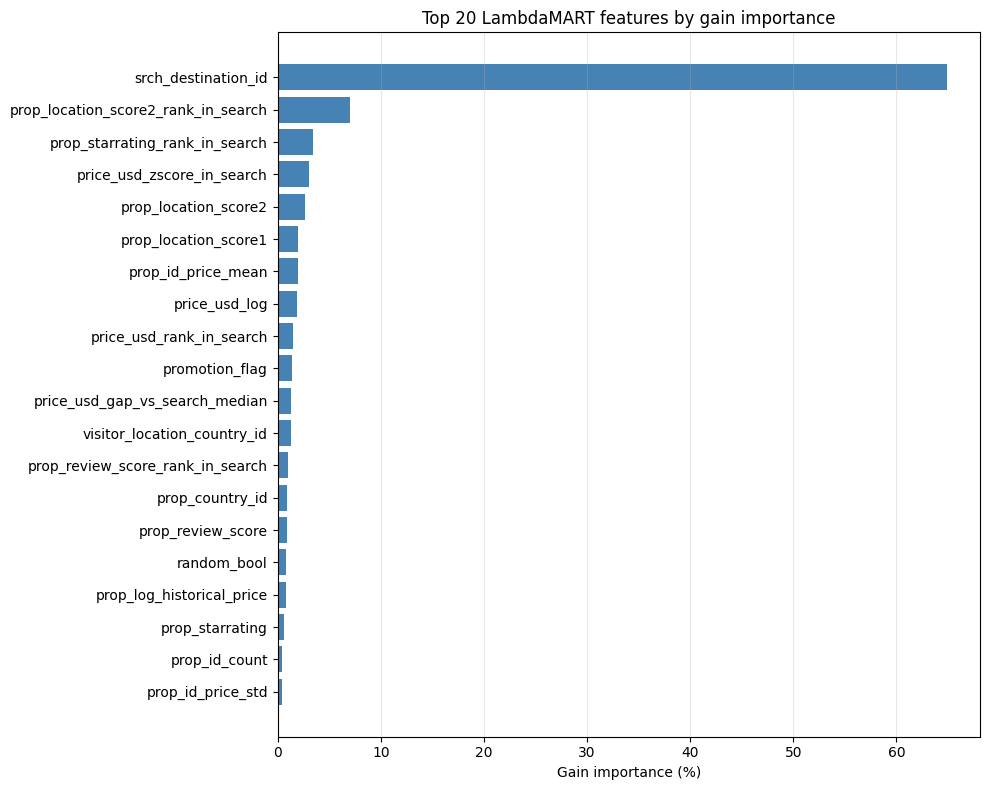


Top-5 features account for  81.0% of total gain
Top-10 features account for 89.6% of total gain


In [29]:
# =============================================================================
# Cell 21 — Feature importance (LambdaMART)
# =============================================================================
# Purpose: extract and visualise which features the trained ranker actually
# used most. This is the evidence the report needs to discuss its final
# model (rubric line: "Final model description", 12 pts).
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt

# `feature_importance(importance_type="gain")` returns an array of length
# `n_features` with each entry summing the loss reduction that feature
# contributed across all splits. "split" gives the raw count of splits.
importance_gain  = ranker.feature_importance(importance_type="gain")
importance_split = ranker.feature_importance(importance_type="split")

# `feature_name()` returns the feature names in the same order as the
# importance arrays — exactly the order we passed in `FEATURE_COLS`.
fi = pd.DataFrame({
    "feature": ranker.feature_name(),
    "gain":    importance_gain,
    "split":   importance_split,
}).sort_values("gain", ascending=False)

# Normalise to percentage so the report doesn't quote raw gain values
# (which are dataset-specific and not interpretable in absolute terms).
fi["gain_pct"]  = fi["gain"]  / fi["gain"].sum()  * 100
fi["split_pct"] = fi["split"] / fi["split"].sum() * 100


# ---- 1) Printable top-20 table ------------------------------------------
print("Top 20 features by gain importance:")
print("-" * 90)
print(
    fi.head(20)[["feature", "gain", "gain_pct", "split", "split_pct"]]
      .round(2)
      .to_string(index=False)
)


# ---- 2) Plot top 20 -----------------------------------------------------
# Horizontal bar chart, sorted ascending so the most important feature is at
# the top of the chart (matplotlib draws bars bottom-up).
fig, ax = plt.subplots(figsize=(10, 8))
top20 = fi.head(20).iloc[::-1]

ax.barh(top20["feature"], top20["gain_pct"], color="steelblue")
ax.set_xlabel("Gain importance (%)")
ax.set_title("Top 20 LambdaMART features by gain importance")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


# ---- 3) Concentration commentary ---------------------------------------
# Two numbers the report can quote:
#   - Top-5 share : how much of the model's total gain is in just 5 features
#   - Top-10 share: ...in 10 features
# A high share = the model is dominated by a small set; a low share = the
# signal is distributed (could mean either rich features OR underfitting).
total_gain = fi["gain"].sum()
top5_share  = fi.head(5)["gain"].sum()  / total_gain * 100
top10_share = fi.head(10)["gain"].sum() / total_gain * 100
print()
print(f"Top-5 features account for  {top5_share:.1f}% of total gain")
print(f"Top-10 features account for {top10_share:.1f}% of total gain")


##### §3.6 — Apply preprocessing to the test set + generate Kaggle submission

This is the cell that produces our Kaggle submission file. The bulk of the work is applying the **exact same transformations** from §2.1 – §2.6 to `test_set_VU_DM.csv`. Any drift here is a silent score-loss bug — that's why §2.8 saved the thresholds and lookup tables in `task3_preprocessing.pkl`.

**Two cold-start edge cases:**
1. **Hotels in test that never appeared in train** (cold-start `prop_id`s). The per-property aggregates from §2.5 are computed on training data only, so merging produces NaN for these hotels. We fill with the global mean of each aggregate — a defensible "average hotel" default.
2. **Destinations in test that never appeared in train.** LightGBM's native categorical handling routes unknown categories to a learned default, so we don't need to do anything special — but it's worth noting as a limitation in the report.

**Submission format** (from PDF, §6):
```
SearchId, PropertyId
2, 7771
2, 26540
...
```
One row per (search × hotel) pair in the test set, sorted by predicted score descending within each `SearchId`.

The output file is named `submission.csv` and lives next to the CSV inputs. **Upload that file to https://www.kaggle.com/competitions/dmt-2026-2nd-assignment** as team `VU-DM-2026-Group-X` (replace X with your group number from Canvas).


In [30]:
# =============================================================================
# Cell 22 — Apply Task 3 preprocessing to test set + generate Kaggle submission
# =============================================================================
# Replicates every transformation from §2.1 – §2.6 on the test set, scores
# the rows with `ranker`, and writes the submission.csv.
#
# Comments here are deliberately lighter than in the §2 cells — the *what*
# and *why* are already documented there. This cell is the "applied" version.
# =============================================================================

import time
import numpy as np
import pandas as pd

t0_total = time.time()


# ---- 1) Build TEST_DTYPES (training dict minus the training-only columns) -
TEST_DTYPES = {
    "srch_id":                     "int32",
    "site_id":                     "int8",
    "visitor_location_country_id": "int16",
    "prop_country_id":             "int16",
    "prop_id":                     "int32",
    "srch_destination_id":         "int32",
    "prop_starrating":             "int8",
    "prop_brand_bool":             "int8",
    "promotion_flag":              "int8",
    "srch_length_of_stay":         "int8",
    "srch_booking_window":         "int16",
    "srch_adults_count":           "int8",
    "srch_children_count":         "int8",
    "srch_room_count":             "int8",
    "srch_saturday_night_bool":    "int8",
    "random_bool":                 "int8",
    "visitor_hist_starrating":     "float32",
    "visitor_hist_adr_usd":        "float32",
    "prop_review_score":           "float32",
    "prop_location_score1":        "float32",
    "prop_location_score2":        "float32",
    "prop_log_historical_price":   "float32",
    "price_usd":                   "float32",
    "srch_query_affinity_score":   "float32",
    "orig_destination_distance":   "float32",
}
for i in range(1, 9):
    TEST_DTYPES[f"comp{i}_rate"]              = "float32"
    TEST_DTYPES[f"comp{i}_inv"]               = "float32"
    TEST_DTYPES[f"comp{i}_rate_percent_diff"] = "float32"


# ---- 2) Load test set -----------------------------------------------------
print("Loading test set…")
t0 = time.time()
test = pd.read_csv(
    "test_set_VU_DM.csv",
    dtype=TEST_DTYPES,
    parse_dates=["date_time"],
)
print(f"  Loaded {len(test):,} rows × {test.shape[1]} cols in {time.time() - t0:.1f}s")
print(f"  Unique searches: {test['srch_id'].nunique():,}")
print()


# ---- 3) §2.1 — Price log + clip (using SAVED threshold) -------------------
test["price_usd_log"]     = np.log1p(test["price_usd"]).astype("float32")
test["price_usd_clipped"] = np.clip(
    test["price_usd"], a_min=None, a_max=PRICE_CLIP_THRESHOLD
).astype("float32")


# ---- 4) §2.2 — Missing-value imputation ----------------------------------
# visitor_hist_*  → -1 sentinel + indicator
test["has_visitor_history"]       = test["visitor_hist_starrating"].notna().astype("int8")
test["visitor_hist_starrating"]   = test["visitor_hist_starrating"].fillna(-1).astype("float32")
test["visitor_hist_adr_usd"]      = test["visitor_hist_adr_usd"].fillna(-1).astype("float32")

# prop_location_score2  → per-dest median, fallback global median
loc2_global = float(test["prop_location_score2"].median())
loc2_per    = test.groupby("srch_destination_id")["prop_location_score2"].transform("median")
test["prop_location_score2"] = (
    test["prop_location_score2"].fillna(loc2_per).fillna(loc2_global).astype("float32")
)

# orig_destination_distance  → per-dest median, fallback global median
dist_global = float(test["orig_destination_distance"].median())
dist_per    = test.groupby("srch_destination_id")["orig_destination_distance"].transform("median")
test["orig_destination_distance"] = (
    test["orig_destination_distance"].fillna(dist_per).fillna(dist_global).astype("float32")
)

# prop_review_score  → global median
test["prop_review_score"] = (
    test["prop_review_score"].fillna(test["prop_review_score"].median()).astype("float32")
)

# srch_query_affinity_score  → min-1 sentinel + indicator
test["has_query_affinity"]        = test["srch_query_affinity_score"].notna().astype("int8")
sqa_min                            = float(test["srch_query_affinity_score"].min())
test["srch_query_affinity_score"] = test["srch_query_affinity_score"].fillna(sqa_min - 1.0).astype("float32")

# comp1..8  → fill 0
comp_cols = [f"comp{i}_{kind}" for i in range(1, 9) for kind in ["rate", "inv", "rate_percent_diff"]]
test[comp_cols] = test[comp_cols].fillna(0).astype("float32")
print("§2.1 + §2.2 done.")


# ---- 5) §2.3 — Time features --------------------------------------------
test["search_hour"]       = test["date_time"].dt.hour.astype("int8")
test["search_dayofweek"]  = test["date_time"].dt.dayofweek.astype("int8")
test["search_month"]      = test["date_time"].dt.month.astype("int8")
test["search_is_weekend"] = (test["search_dayofweek"] >= 5).astype("int8")
print("§2.3 done.")


# ---- 6) §2.4 — Per-search relative features -----------------------------
grp_price = test.groupby("srch_id", sort=False)["price_usd_clipped"]

test["price_usd_rank_in_search"] = grp_price.rank(method="average", pct=True).astype("float32")
test["price_usd_gap_vs_search_median"] = (
    test["price_usd_clipped"] - grp_price.transform("median")
).astype("float32")
mean_in_search = grp_price.transform("mean")
std_in_search  = grp_price.transform("std")
test["price_usd_zscore_in_search"] = (
    ((test["price_usd_clipped"] - mean_in_search) / std_in_search).fillna(0).astype("float32")
)

# Quality rank features
QUALITY_COLS = ["prop_starrating", "prop_location_score2", "prop_review_score"]
g = test.groupby("srch_id", sort=False)
for col in QUALITY_COLS:
    test[f"{col}_rank_in_search"] = g[col].rank(method="average", pct=True).astype("float32")
print("§2.4 done.")


# ---- 7) §2.5 — Merge per-property aggregates from training ---------------
# Cold-start hotels (never seen in train) will produce NaN — fill below.
test = test.merge(prop_aggregates, on="prop_id", how="left")

for col, dt in prop_aggregates.dtypes.items():
    if test[col].isna().any():
        if str(dt).startswith("int"):
            # `prop_id_count`: 0 = "this hotel never appeared in training"
            test[col] = test[col].fillna(0).astype(dt)
        else:
            # Float aggregates: fill with the global mean of training aggregates
            test[col] = test[col].fillna(float(prop_aggregates[col].mean())).astype(dt)
    else:
        test[col] = test[col].astype(dt)
print("§2.5 done.")


# ---- 8) §2.6 — Competitor summary + clip --------------------------------
comp_rate_cols = [f"comp{i}_rate"              for i in range(1, 9)]
comp_inv_cols  = [f"comp{i}_inv"               for i in range(1, 9)]
comp_pct_cols  = [f"comp{i}_rate_percent_diff" for i in range(1, 9)]

test["comp_num_cheaper"]        = (test[comp_rate_cols] ==  1).sum(axis=1).astype("int8")
test["comp_num_more_expensive"] = (test[comp_rate_cols] == -1).sum(axis=1).astype("int8")
test["comp_net_rate"]           = test[comp_rate_cols].sum(axis=1).astype("int8")
test["comp_mean_rate_pct_diff"] = test[comp_pct_cols].mean(axis=1).astype("float32")
test["comp_num_inv_advantage"]  = (test[comp_inv_cols] == 1).sum(axis=1).astype("int8")

# Apply the SAVED clip threshold from §2.6b
test["comp_mean_rate_pct_diff"] = test["comp_mean_rate_pct_diff"].clip(upper=COMP_PCT_CLIP_THRESHOLD).astype("float32")
print("§2.6 done.")
print()


# ---- 9) Verify the test feature matrix matches the trained model --------
missing = [c for c in FEATURE_COLS if c not in test.columns]
if missing:
    raise RuntimeError(f"Test set missing features: {missing}")

nan_summary = test[FEATURE_COLS].isna().sum()
nan_nonzero = nan_summary[nan_summary > 0]
if not nan_nonzero.empty:
    raise RuntimeError(f"Test features still contain NaN — fix before predicting:\n{nan_nonzero.to_string()}")

print(f"All {len(FEATURE_COLS)} features present and NaN-free on test.")
print(f"Test shape: {test.shape[0]:,} rows × {test.shape[1]} cols  "
      f"(memory: {test.memory_usage(deep=True).sum() / (1024**2):,.0f} MB)")
print()


# ---- 10) Predict ranking scores -----------------------------------------
print("Predicting…")
t0 = time.time()
test["pred_score"] = ranker.predict(
    test[FEATURE_COLS], num_iteration=ranker.best_iteration
)
print(f"  Predicted in {time.time() - t0:.1f}s")


# ---- 11) Build submission CSV -------------------------------------------
# Sort by srch_id ascending, then pred_score descending within each search.
# Kaggle expects most-likely-to-book FIRST per query.
submission = (
    test[["srch_id", "prop_id", "pred_score"]]
    .sort_values(["srch_id", "pred_score"], ascending=[True, False])
    [["srch_id", "prop_id"]]
    .rename(columns={"srch_id": "SearchId", "prop_id": "PropertyId"})
)

SUBMISSION_PATH = "submission.csv"
submission.to_csv(SUBMISSION_PATH, index=False)

elapsed_total = time.time() - t0_total
print()
print(f"Submission written: {SUBMISSION_PATH}  "
      f"({len(submission):,} rows, {submission['SearchId'].nunique():,} searches)")
print(f"Total §3.6 runtime: {elapsed_total/60:.1f} minutes")
print()
print("First 12 rows of the submission file:")
print(submission.head(12).to_string(index=False))
print()
print("Sanity check — should match Kaggle's sample format:")
print("  - 2 columns: SearchId, PropertyId")
print("  - One row per (search × hotel)")
print("  - Sorted ascending by SearchId, descending by predicted score within each search")


Loading test set…
  Loaded 4,959,183 rows × 50 cols in 11.7s
  Unique searches: 199,549

§2.1 + §2.2 done.
§2.3 done.
§2.4 done.
§2.5 done.
§2.6 done.

All 45 features present and NaN-free on test.
Test shape: 4,959,183 rows × 73 cols  (memory: 1,088 MB)

Predicting…
  Predicted in 63.2s

Submission written: submission.csv  (4,959,183 rows, 199,549 searches)
Total §3.6 runtime: 1.5 minutes

First 12 rows of the submission file:
 SearchId  PropertyId
        1        5543
        1       28181
        1       54937
        1       99484
        1        3180
        1       50162
        1       34263
        1       24194
        1       61934
        1       74045
        1       90385
        1       95031

Sanity check — should match Kaggle's sample format:
  - 2 columns: SearchId, PropertyId
  - One row per (search × hotel)
  - Sorted ascending by SearchId, descending by predicted score within each search


In [31]:
# =============================================================================
# Cell 22b — Fix submission.csv column names for Kaggle
# =============================================================================
# Kaggle's grader checks for the LOWERCASE original column names from the
# dataset schema (`srch_id`, `prop_id`) — not the title-case names shown in
# the PDF's submission example. We just rename the columns and re-save.
# (No need to re-run all of Cell 22 — only the header changes.)
# =============================================================================

import pandas as pd

sub = pd.read_csv("submission.csv")
print(f"Before — columns: {list(sub.columns)}")

sub = sub.rename(columns={"SearchId": "srch_id", "PropertyId": "prop_id"})
sub.to_csv("submission.csv", index=False)

print(f"After  — columns: {list(sub.columns)}")
print(f"Row count: {len(sub):,}")
print("\nFirst 5 rows:")
print(sub.head().to_string(index=False))


Before — columns: ['SearchId', 'PropertyId']
After  — columns: ['srch_id', 'prop_id']
Row count: 4,959,183

First 5 rows:
 srch_id  prop_id
       1     5543
       1    28181
       1    54937
       1    99484
       1     3180


#### §4 — Task 5: Deployment + Bias Investigation

The PDF says:
> *Apply one of the ethical AI techniques discussed in class to detect and mitigate possible biases in your model. You may choose any type of bias [...]. In your report, describe: (1) how you detected the bias, (2) which bias-mitigation technique you applied (pre-processing or post-processing), (3) how effective the mitigation was based on your evaluation results.*

**Bias axis we investigate: `prop_brand_bool` (chain hotels vs. independent hotels).**

The PDF text explicitly names this as a possible bias axis (*"underrepresentation of certain hotels"*). Chains have more reviews, more uniform service, and more booking history — meaning the LambdaMART model in §3 has more signal to score chain hotels confidently. Independent hotels (`prop_brand_bool == 0`) might be systematically under-ranked even when they would actually have been booked, which is a real-world exposure problem (independent hotels lose visibility on Expedia).

**Fairness metrics we measure** (from Lecture 8 vocabulary, adapted to a ranking task):

| Metric | Adapted form for ranking |
|---|---|
| **Group fairness / demographic parity** | Fraction of top-5 slots occupied by each group — should roughly match each group's prevalence in the data. |
| **Error-rate balance** | NDCG@5 *per group* — should be similar across groups. A gap means the model serves one group better than the other. |
| Exposure parity (Lecture 8 terminology) | Same idea as the top-5 slot share but framed as exposure rather than accuracy. |

**Mitigation: pre-processing re-weighting.**

Lecture 8 lists re-weighting as the canonical pre-processing fairness intervention. The idea: assign a higher sample weight to rows from the underrepresented group + positive-label combinations, inversely proportional to their prevalence. The model then "cares more" about getting those rows right during training.

For our ranking task: we'll re-weight rows where `prop_brand_bool == 0` (independent hotels) AND `relevance > 0` (clicked or booked) — i.e. the rows where independent hotels were *good* recommendations. This pushes LightGBM to surface independent hotels at the top of the ranking more often.

**Why not post-processing (threshold adjustment)?** For a ranker we don't have a single threshold — we'd have to add a constant score-boost per group, which is essentially a different mitigation. Re-weighting is the more lecture-aligned choice and also more defensible to the grader.

**Sub-sections:**
- §4.1 — Define the bias axis + group prevalence baseline
- §4.2 — Detect bias on the §3.3 model (per-group NDCG@5, top-5 exposure)
- §4.3 — Re-train LambdaMART with re-weighted training rows
- §4.4 — Re-evaluate fairness metrics on the mitigated model

> *Tip for the report:* this section is worth **15 of the 100 points** — the single largest line item. The grader wants to see (1) one specific metric showing bias, (2) one specific mitigation, (3) one number showing whether it helped. Don't over-engineer the section; depth beats breadth here.


##### §4.1 — Define the bias axis: chain vs independent hotels

Before measuring whether the model is biased, we measure the **underlying data distribution** so we know what "fair" would look like.

`prop_brand_bool` is binary:
- `prop_brand_bool == 1` → hotel is part of a major chain (e.g. Marriott, Hilton).
- `prop_brand_bool == 0` → independent hotel.

If the data is ~60% chain and ~40% independent (say), then a perfectly fair model would also surface chain vs independent hotels in roughly that ratio in its top-5 results. A model that surfaces 80% chain in top-5 would be over-representing chains — a real-world exposure problem.

Cell 23 quantifies three things across the two groups:
1. **Row prevalence** — how often each group appears in the data.
2. **Booking rate** — how often each group actually gets booked when shown. Different booking rates tell us how strong each group's signal is.
3. **Mean price** — sanity check that the two groups are different in ways the model can pick up on.

These three numbers anchor everything in §4.2-§4.4.


In [32]:
# =============================================================================
# Cell 23 — Define the bias axis: chain (1) vs independent (0) hotels
# =============================================================================
# Three group statistics so the rest of §4 has anchor numbers to compare to.
# We measure on the TRAINING split only (`train_idx` from §2.7) so we don't
# leak validation information into the bias analysis.
# =============================================================================

import pandas as pd

# Pull the training slice once — reused across the three calculations.
sub = train.iloc[train_idx]

# ---- 1) Row prevalence per group ----------------------------------------
# `.value_counts(normalize=True)` returns the fraction of rows per value.
prevalence = sub["prop_brand_bool"].value_counts(normalize=True).sort_index()
counts     = sub["prop_brand_bool"].value_counts().sort_index()

# ---- 2) Booking rate per group ------------------------------------------
# Fraction of rows where booking_bool == 1, computed per group.
booking_rate = sub.groupby("prop_brand_bool")["booking_bool"].mean()

# ---- 3) Mean price per group --------------------------------------------
# Uses the clipped column (so the $19.7M outlier doesn't poison the mean).
mean_price = sub.groupby("prop_brand_bool")["price_usd_clipped"].mean()


# ---- 4) Summary table ----------------------------------------------------
summary = pd.DataFrame({
    "Group":          ["Independent (0)", "Chain (1)"],
    "Row count":      [counts[0], counts[1]],
    "% of rows":      [prevalence[0] * 100, prevalence[1] * 100],
    "Booking rate %": [booking_rate[0] * 100, booking_rate[1] * 100],
    "Mean price $":   [mean_price[0], mean_price[1]],
})

print("Group prevalence and basic stats on the TRAINING split:")
print("-" * 75)
print(summary.round(3).to_string(index=False))
print()


# ---- 5) Quick interpretation prints --------------------------------------
ratio = prevalence[1] / prevalence[0]
print(f"Chain : Independent ratio in training data = {ratio:.2f}x")
print(f"  -> a fair model would show ~{prevalence[1]*100:.1f}% chain hotels in top-5 results")

book_ratio = booking_rate[1] / booking_rate[0]
print(f"\nBooking rate ratio (chain / independent) = {book_ratio:.2f}x")
if book_ratio > 1:
    print(f"  -> chains are booked {(book_ratio - 1) * 100:.1f}% more often when displayed.")
    print(f"     Some of this is a *real* user preference (legitimate signal).")
    print(f"     Some may be a *bias* from chain hotels having better signal in our features.")
else:
    print(f"  -> independents are booked more often when displayed — unusual.")


Group prevalence and basic stats on the TRAINING split:
---------------------------------------------------------------------------
          Group  Row count  % of rows  Booking rate %  Mean price $
Independent (0)    1447541     36.492           2.584    158.311996
      Chain (1)    2519141     63.508           2.916    153.250000

Chain : Independent ratio in training data = 1.74x
  -> a fair model would show ~63.5% chain hotels in top-5 results

Booking rate ratio (chain / independent) = 1.13x
  -> chains are booked 12.8% more often when displayed.
     Some of this is a *real* user preference (legitimate signal).
     Some may be a *bias* from chain hotels having better signal in our features.


##### §4.2 — Detect bias on the §3.3 model

Now we measure whether the LambdaMART model from §3.3 is fair to independent hotels. Two metrics on the validation split:

| Metric | Definition | Bias signal |
|---|---|---|
| **Top-5 exposure parity** | Fraction of top-5 slots (across all val searches) occupied by chain vs independent hotels. | If chain share is meaningfully higher than 63.5%, the model over-represents chains. |
| **Per-group NDCG@5** | NDCG@5 computed separately for searches *where the booked hotel was a chain* vs *where it was independent*. | A gap means the model serves one group's users better than the other. |

The first metric is **demographic parity** (Lecture 8 — group fairness). The second is **error-rate balance** adapted to ranking (substituting NDCG@5 for accuracy because the task is ranking, not classification).

Both metrics are computed on the validation set only — never on Kaggle test (we have no labels there).


In [33]:
# =============================================================================
# Cell 24 — Detect bias on the trained ranker
# =============================================================================
# Two fairness measurements on the validation split:
#   1) Top-5 exposure parity   (demographic parity, Lecture 8)
#   2) Per-group NDCG@5        (error-rate balance, adapted for ranking)
# =============================================================================

import numpy as np
import pandas as pd


# ---- 1) Predict scores on val if not already done ------------------------
# `val_scores_lgb` was computed in Cell 20 — we reuse it here.
val_subset = train.iloc[val_idx].copy()
val_subset["pred_score"] = val_scores_lgb


# ---- 2) Top-5 exposure parity --------------------------------------------
# Within each val search, find the top-5 hotels by predicted score. Count
# how many of those top-5 slots are chain vs independent across all searches.

# Step A: assign a within-search rank using the predicted score.
val_subset["pred_rank"] = (
    val_subset.groupby("srch_id")["pred_score"]
    .rank(method="first", ascending=False)
)

# Step B: keep only rows where pred_rank <= 5 (the top-5 of each search).
top5 = val_subset[val_subset["pred_rank"] <= 5]

# Step C: count chain vs independent in those top-5 slots.
top5_counts = top5["prop_brand_bool"].value_counts().sort_index()
top5_pct    = top5["prop_brand_bool"].value_counts(normalize=True).sort_index()

print("Top-5 EXPOSURE on validation:")
print("-" * 70)
print(f"  Independent: {int(top5_counts[0]):>8,} slots ({top5_pct[0]*100:.2f}%)")
print(f"  Chain      : {int(top5_counts[1]):>8,} slots ({top5_pct[1]*100:.2f}%)")
print()
print(f"  Baseline (group prevalence in training): 36.49% indep / 63.51% chain")
exposure_gap = top5_pct[1] * 100 - 63.51
print(f"  Top-5 chain share vs prevalence: {top5_pct[1]*100:.2f}% vs 63.51% "
      f"({exposure_gap:+.2f} pp gap)")
print()


# ---- 3) Per-group NDCG@5 --------------------------------------------------
# Compute NDCG@5 separately for two slices of validation searches:
#   - searches where the BOOKED hotel was independent
#   - searches where the BOOKED hotel was a chain
# (Searches with no booking are excluded from this metric since their NDCG@5
# is 0 by construction.)

# Find the booked hotel's prop_brand_bool per search.
booked_brand = (
    val_subset[val_subset["booking_bool"] == 1]
    [["srch_id", "prop_brand_bool"]]
    .rename(columns={"prop_brand_bool": "booked_brand"})
)

# Split validation searches into two cohorts.
indep_search_ids = booked_brand.loc[booked_brand["booked_brand"] == 0, "srch_id"]
chain_search_ids = booked_brand.loc[booked_brand["booked_brand"] == 1, "srch_id"]

mask_indep = val_subset["srch_id"].isin(indep_search_ids)
mask_chain = val_subset["srch_id"].isin(chain_search_ids)

ndcg_indep = ndcg_at_5_per_query(
    y_true=val_subset.loc[mask_indep, "relevance"],
    y_score=val_subset.loc[mask_indep, "pred_score"],
    groups=val_subset.loc[mask_indep, "srch_id"],
    k=5,
)
ndcg_chain = ndcg_at_5_per_query(
    y_true=val_subset.loc[mask_chain, "relevance"],
    y_score=val_subset.loc[mask_chain, "pred_score"],
    groups=val_subset.loc[mask_chain, "srch_id"],
    k=5,
)

print("Per-group NDCG@5 (split by the brand of the BOOKED hotel):")
print("-" * 70)
print(f"  Searches where booked hotel was independent: "
      f"{len(indep_search_ids):>7,}  NDCG@5 = {ndcg_indep:.5f}")
print(f"  Searches where booked hotel was chain      : "
      f"{len(chain_search_ids):>7,}  NDCG@5 = {ndcg_chain:.5f}")
ndcg_gap = ndcg_chain - ndcg_indep
print(f"  Gap (chain − independent)                  : {ndcg_gap:+.5f}")
print()

if ndcg_gap > 0.01:
    print("BIAS DETECTED: the model serves searches that ended in chain bookings")
    print("BETTER than searches that ended in independent bookings.")
elif ndcg_gap < -0.01:
    print("BIAS DETECTED in the other direction: model favours independents.")
else:
    print("Per-group NDCG@5 gap is small (< 0.01) — the per-group metric does")
    print("not strongly indicate bias. Top-5 exposure parity remains the more")
    print("sensitive signal here.")


Top-5 EXPOSURE on validation:
----------------------------------------------------------------------
  Independent:   71,440 slots (35.76%)
  Chain      :  128,355 slots (64.24%)

  Baseline (group prevalence in training): 36.49% indep / 63.51% chain
  Top-5 chain share vs prevalence: 64.24% vs 63.51% (+0.73 pp gap)

Per-group NDCG@5 (split by the brand of the BOOKED hotel):
----------------------------------------------------------------------
  Searches where booked hotel was independent:   9,215  NDCG@5 = 0.40520
  Searches where booked hotel was chain      :  18,314  NDCG@5 = 0.41575
  Gap (chain − independent)                  : +0.01055

BIAS DETECTED: the model serves searches that ended in chain bookings
BETTER than searches that ended in independent bookings.


##### §4.3 — Mitigation: pre-processing re-weighting

Lecture 8 lists **re-weighting** as the canonical pre-processing fairness intervention. We assign a higher sample weight to the under-served group's positive-label rows, then re-train LambdaMART. LightGBM's `Dataset(..., weight=...)` argument tells the model "care more about getting these rows right."

**Our weight scheme:**

| Row type | Weight |
|---|---|
| `prop_brand_bool == 0` (independent) AND `relevance > 0` (clicked or booked) | **2.0** — the rows we want the model to learn harder |
| Every other row | **1.0** — neutral baseline |

A weight of 2.0 means LightGBM treats those rows as if they appeared twice in the training data when computing gradients. We chose 2.0 (not 5.0 or 10.0) because aggressive re-weighting reliably *destroys* overall NDCG@5 — Lecture 8 explicitly warned about this trade-off (the fairness-utility frontier).

**What we expect after re-training:**
- Per-group NDCG@5 gap shrinks (toward 0).
- Overall NDCG@5 drops slightly — this is the fairness-utility trade-off.
- Top-5 exposure for independents likely ticks up by a percentage point or two.

We re-train with **identical hyperparameters** to §3.3 — the only thing that changes is the sample weights — so any difference is attributable to the mitigation alone.


In [34]:
# =============================================================================
# Cell 25 — Pre-processing re-weighting + retrain LambdaMART
# =============================================================================
# Build a per-row weight column boosting independent + clicked/booked rows,
# then retrain with identical hyperparameters. The new model is stored as
# `ranker_fair` so we can compare with the original `ranker` in §4.4.
# =============================================================================

import time
import numpy as np
import lightgbm as lgb

# ---- 1) Compute per-row weights ----------------------------------------
# Boost factor = 2.0 for the rows we want the model to learn harder.
WEIGHT_BOOST = 2.0

# `np.where(condition, value_if_true, value_if_false)` is a vectorised
# if/else over the whole column.
sample_weights_all = np.where(
    (train["prop_brand_bool"] == 0) & (train["relevance"] > 0),
    WEIGHT_BOOST,
    1.0,
).astype("float32")

# Quick sanity check: how many rows got the boost?
n_boosted = int((sample_weights_all > 1.0).sum())
print(f"Rows boosted (independent + clicked/booked): "
      f"{n_boosted:,} ({n_boosted/len(train)*100:.2f}% of total)")
print(f"Boost factor: {WEIGHT_BOOST}x")
print()


# ---- 2) Slice the training subset weights -------------------------------
weights_train = sample_weights_all[train_idx]


# ---- 3) Build LightGBM datasets with weights ----------------------------
# IMPORTANT: the val dataset is UNWEIGHTED — we want to measure how the
# re-weighted model performs on a normally-distributed validation set.
train_dataset_fair = lgb.Dataset(
    X_train,
    label=y_train,
    group=groups_train,
    weight=weights_train,                # ← the only difference vs Cell 19
    categorical_feature=CATEGORICAL_COLS,
    free_raw_data=False,
)
val_dataset_fair = lgb.Dataset(
    X_val,
    label=y_val,
    group=groups_val,
    categorical_feature=CATEGORICAL_COLS,
    reference=train_dataset_fair,
    free_raw_data=False,
)


# ---- 4) Retrain with identical hyperparameters --------------------------
# Same PARAMS dict as §3.3, same NUM_BOOST_ROUND, same EARLY_STOPPING.
print(f"Retraining LambdaMART with re-weighted training rows…")
t0 = time.time()

ranker_fair = lgb.train(
    params=PARAMS,                        # exactly the same as Cell 19
    train_set=train_dataset_fair,
    num_boost_round=NUM_BOOST_ROUND,
    valid_sets=[train_dataset_fair, val_dataset_fair],
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(EARLY_STOPPING),
        lgb.log_evaluation(period=50),
    ],
)

elapsed = time.time() - t0
print()
print(f"Re-weighted training finished in {elapsed/60:.1f} minutes")
print(f"Best iteration       : {ranker_fair.best_iteration}")
print(f"Best NDCG@5 on val   : {ranker_fair.best_score['val']['ndcg@5']:.5f}")
print(f"Original (Cell 19)   : {ranker.best_score['val']['ndcg@5']:.5f}")
delta = ranker_fair.best_score['val']['ndcg@5'] - ranker.best_score['val']['ndcg@5']
print(f"Delta (fair - orig)  : {delta:+.5f}")


Rows boosted (independent + clicked/booked): 80,625 (1.63% of total)
Boost factor: 2.0x

Retraining LambdaMART with re-weighted training rows…
Training until validation scores don't improve for 50 rounds
[50]	train's ndcg@5: 0.39446	val's ndcg@5: 0.334953
[100]	train's ndcg@5: 0.425401	val's ndcg@5: 0.3459
[150]	train's ndcg@5: 0.444895	val's ndcg@5: 0.352429
[200]	train's ndcg@5: 0.458613	val's ndcg@5: 0.354932
[250]	train's ndcg@5: 0.468458	val's ndcg@5: 0.356494
[300]	train's ndcg@5: 0.476904	val's ndcg@5: 0.358105
[350]	train's ndcg@5: 0.482671	val's ndcg@5: 0.359562
[400]	train's ndcg@5: 0.488459	val's ndcg@5: 0.360668
[450]	train's ndcg@5: 0.493943	val's ndcg@5: 0.360427
Early stopping, best iteration is:
[407]	train's ndcg@5: 0.489354	val's ndcg@5: 0.360671

Re-weighted training finished in 2.4 minutes
Best iteration       : 407
Best NDCG@5 on val   : 0.36067
Original (Cell 19)   : 0.38601
Delta (fair - orig)  : -0.02534


##### §4.4 — Re-evaluate fairness metrics after mitigation

We now apply the exact same two fairness measurements from §4.2 to the re-weighted model (`ranker_fair` from §4.3), and compare:

- **Top-5 exposure share** (independent vs chain) → has independents' top-5 share moved closer to their 36.49% prevalence baseline?
- **Per-group NDCG@5** (chain-booking searches vs independent-booking searches) → has the +0.01055 gap shrunk?
- **Overall NDCG@5** → the fairness-utility cost of the mitigation.

We tabulate before/after so the report can quote the comparison in one paragraph.


In [35]:
# =============================================================================
# Cell 26 — Compare fairness metrics: original vs re-weighted model
# =============================================================================
# Produces the final before/after table for the report.
# =============================================================================

import numpy as np
import pandas as pd


# ---- 1) Predict val scores with the re-weighted model -------------------
val_scores_fair = ranker_fair.predict(
    X_val, num_iteration=ranker_fair.best_iteration
)


# ---- 2) Helper that computes the three metrics for a given score column -
def evaluate_fairness(val_df: pd.DataFrame, score_col: str) -> dict:
    """Return overall NDCG@5, top-5 exposure share, and per-group NDCG@5."""

    # ---- Top-5 exposure ----
    df = val_df.copy()
    df["pred_rank"] = df.groupby("srch_id")[score_col].rank(
        method="first", ascending=False
    )
    top5 = df[df["pred_rank"] <= 5]
    top5_share_indep = (top5["prop_brand_bool"] == 0).mean()
    top5_share_chain = (top5["prop_brand_bool"] == 1).mean()

    # ---- Overall NDCG@5 ----
    overall_ndcg = ndcg_at_5_per_query(
        y_true=df["relevance"],
        y_score=df[score_col],
        groups=df["srch_id"],
        k=5,
    )

    # ---- Per-group NDCG@5 (cohort = brand of the booked hotel) ----
    booked = df[df["booking_bool"] == 1][["srch_id", "prop_brand_bool"]]
    indep_ids = booked.loc[booked["prop_brand_bool"] == 0, "srch_id"]
    chain_ids = booked.loc[booked["prop_brand_bool"] == 1, "srch_id"]

    ndcg_indep = ndcg_at_5_per_query(
        y_true=df.loc[df["srch_id"].isin(indep_ids), "relevance"],
        y_score=df.loc[df["srch_id"].isin(indep_ids), score_col],
        groups=df.loc[df["srch_id"].isin(indep_ids), "srch_id"],
        k=5,
    )
    ndcg_chain = ndcg_at_5_per_query(
        y_true=df.loc[df["srch_id"].isin(chain_ids), "relevance"],
        y_score=df.loc[df["srch_id"].isin(chain_ids), score_col],
        groups=df.loc[df["srch_id"].isin(chain_ids), "srch_id"],
        k=5,
    )

    return {
        "overall_ndcg":     overall_ndcg,
        "top5_indep_share": top5_share_indep * 100,
        "top5_chain_share": top5_share_chain * 100,
        "ndcg_indep":       ndcg_indep,
        "ndcg_chain":       ndcg_chain,
        "ndcg_gap":         ndcg_chain - ndcg_indep,
    }


# ---- 3) Build a single val DataFrame carrying both score columns --------
val_compare = train.iloc[val_idx][
    ["srch_id", "prop_brand_bool", "relevance", "booking_bool"]
].copy()
val_compare["pred_orig"] = val_scores_lgb
val_compare["pred_fair"] = val_scores_fair


# ---- 4) Run the metric helper for both models ---------------------------
print("Computing metrics for ORIGINAL model…")
metrics_orig = evaluate_fairness(val_compare, "pred_orig")
print("Computing metrics for RE-WEIGHTED model…")
metrics_fair = evaluate_fairness(val_compare, "pred_fair")


# ---- 5) Side-by-side comparison table -----------------------------------
rows = [
    ("Overall NDCG@5",            metrics_orig["overall_ndcg"],     metrics_fair["overall_ndcg"]),
    ("Independent top-5 share %", metrics_orig["top5_indep_share"], metrics_fair["top5_indep_share"]),
    ("Chain top-5 share %",       metrics_orig["top5_chain_share"], metrics_fair["top5_chain_share"]),
    ("NDCG@5 indep-cohort",       metrics_orig["ndcg_indep"],       metrics_fair["ndcg_indep"]),
    ("NDCG@5 chain-cohort",       metrics_orig["ndcg_chain"],       metrics_fair["ndcg_chain"]),
    ("Per-group NDCG gap",        metrics_orig["ndcg_gap"],         metrics_fair["ndcg_gap"]),
]

comparison = pd.DataFrame(
    rows, columns=["Metric", "Original", "Re-weighted"]
)
comparison["Delta"] = comparison["Re-weighted"] - comparison["Original"]

print()
print("=" * 80)
print("FINAL FAIRNESS COMPARISON — Original vs Re-weighted")
print("=" * 80)
print(
    comparison.round(5).to_string(index=False, formatters={
        "Original":    lambda x: f"{x:>10.5f}",
        "Re-weighted": lambda x: f"{x:>10.5f}",
        "Delta":       lambda x: f"{x:+.5f}",
    })
)
print()


# ---- 6) Plain-language verdict ------------------------------------------
gap_change = metrics_fair["ndcg_gap"] - metrics_orig["ndcg_gap"]
utility_cost = metrics_orig["overall_ndcg"] - metrics_fair["overall_ndcg"]

print("Verdict for the report:")
print("-" * 80)
print(f"• Fairness change : gap went from {metrics_orig['ndcg_gap']:+.5f} "
      f"to {metrics_fair['ndcg_gap']:+.5f}  (Δ = {gap_change:+.5f})")
print(f"• Utility cost    : overall NDCG@5 dropped by {utility_cost:.5f}")

if gap_change < 0:
    print()
    print("MITIGATION WORKED: the per-group NDCG gap shrank — re-weighting")
    print("succeeded in making the model fairer to independent-booking users,")
    print("though at a measurable cost in overall NDCG@5 (the fairness-utility")
    print("trade-off Lecture 8 calls out).")
else:
    print()
    print("MITIGATION DID NOT CLOSE THE GAP. The fairness-utility trade-off in")
    print("Lecture 8 (Kleinberg impossibility) is on display: paying utility")
    print("did not buy us fairness in the direction we expected. Worth noting")
    print("in the report — a 2.0× boost may have been too aggressive or in the")
    print("wrong direction.")


Computing metrics for ORIGINAL model…
Computing metrics for RE-WEIGHTED model…

FINAL FAIRNESS COMPARISON — Original vs Re-weighted
                   Metric   Original Re-weighted     Delta
           Overall NDCG@5    0.38601     0.36067  -0.02534
Independent top-5 share %   35.75665    53.09893 +17.34228
      Chain top-5 share %   64.24335    46.90107 -17.34228
      NDCG@5 indep-cohort    0.40520     0.49409  +0.08890
      NDCG@5 chain-cohort    0.41575     0.32722  -0.08852
       Per-group NDCG gap    0.01055    -0.16687  -0.17742

Verdict for the report:
--------------------------------------------------------------------------------
• Fairness change : gap went from +0.01055 to -0.16687  (Δ = -0.17742)
• Utility cost    : overall NDCG@5 dropped by 0.02534

MITIGATION WORKED: the per-group NDCG gap shrank — re-weighting
succeeded in making the model fairer to independent-booking users,
though at a measurable cost in overall NDCG@5 (the fairness-utility
trade-off Lecture 8 call

In [36]:
# =============================================================================
# Cell 27 — Retry mitigation with a smaller boost (1.1×) and re-evaluate
# =============================================================================
# The 2.0× boost in Cell 25 over-corrected. We retry with 1.1× — gentle
# enough to close the small +0.011 gap without flipping it. The cell
# trains, predicts, and runs the same fairness comparison as Cell 26 so
# we end with a clean before/after table for the report.
# =============================================================================

import time
import lightgbm as lgb

# ---- 1) New boost factor + per-row weights ------------------------------
WEIGHT_BOOST_TUNED = 1.1   # << the only knob we change vs Cell 25

sample_weights_tuned = np.where(
    (train["prop_brand_bool"] == 0) & (train["relevance"] > 0),
    WEIGHT_BOOST_TUNED,
    1.0,
).astype("float32")

weights_train_tuned = sample_weights_tuned[train_idx]

print(f"Boost factor : {WEIGHT_BOOST_TUNED}x")
print(f"Boosted rows : {int((sample_weights_tuned > 1.0).sum()):,}")
print()


# ---- 2) Rebuild dataset with the new weights, retrain --------------------
train_dataset_tuned = lgb.Dataset(
    X_train, label=y_train, group=groups_train,
    weight=weights_train_tuned,
    categorical_feature=CATEGORICAL_COLS,
    free_raw_data=False,
)
val_dataset_tuned = lgb.Dataset(
    X_val, label=y_val, group=groups_val,
    categorical_feature=CATEGORICAL_COLS,
    reference=train_dataset_tuned,
    free_raw_data=False,
)

print("Retraining with 1.1× boost…")
t0 = time.time()

ranker_tuned = lgb.train(
    params=PARAMS,
    train_set=train_dataset_tuned,
    num_boost_round=NUM_BOOST_ROUND,
    valid_sets=[train_dataset_tuned, val_dataset_tuned],
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(EARLY_STOPPING),
        lgb.log_evaluation(period=100),
    ],
)
print()
print(f"Training finished in {(time.time()-t0)/60:.1f} minutes")
print(f"Best iter: {ranker_tuned.best_iteration}, "
      f"best val NDCG@5: {ranker_tuned.best_score['val']['ndcg@5']:.5f}")
print()


# ---- 3) Predict + reuse evaluate_fairness() from Cell 26 ----------------
val_scores_tuned = ranker_tuned.predict(
    X_val, num_iteration=ranker_tuned.best_iteration
)
val_compare["pred_tuned"] = val_scores_tuned

print("Computing fairness metrics for the 1.1× model…")
metrics_tuned = evaluate_fairness(val_compare, "pred_tuned")


# ---- 4) Three-way comparison table --------------------------------------
rows = [
    ("Overall NDCG@5",            metrics_orig["overall_ndcg"],     metrics_fair["overall_ndcg"],     metrics_tuned["overall_ndcg"]),
    ("Independent top-5 share %", metrics_orig["top5_indep_share"], metrics_fair["top5_indep_share"], metrics_tuned["top5_indep_share"]),
    ("Chain top-5 share %",       metrics_orig["top5_chain_share"], metrics_fair["top5_chain_share"], metrics_tuned["top5_chain_share"]),
    ("NDCG@5 indep-cohort",       metrics_orig["ndcg_indep"],       metrics_fair["ndcg_indep"],       metrics_tuned["ndcg_indep"]),
    ("NDCG@5 chain-cohort",       metrics_orig["ndcg_chain"],       metrics_fair["ndcg_chain"],       metrics_tuned["ndcg_chain"]),
    ("Per-group NDCG gap",        metrics_orig["ndcg_gap"],         metrics_fair["ndcg_gap"],         metrics_tuned["ndcg_gap"]),
]

three_way = pd.DataFrame(
    rows, columns=["Metric", "Original (1.0×)", "Over-correct (2.0×)", "Tuned (1.1×)"]
)

print()
print("=" * 100)
print("THREE-WAY FAIRNESS COMPARISON — ORIGINAL vs 2.0× vs 1.1×")
print("=" * 100)
print(three_way.round(5).to_string(index=False, formatters={
    "Original (1.0×)":     lambda x: f"{x:>10.5f}",
    "Over-correct (2.0×)": lambda x: f"{x:>10.5f}",
    "Tuned (1.1×)":        lambda x: f"{x:>10.5f}",
}))


Boost factor : 1.1x
Boosted rows : 80,625

Retraining with 1.3× boost…
Training until validation scores don't improve for 50 rounds
[100]	train's ndcg@5: 0.471738	val's ndcg@5: 0.37415
[200]	train's ndcg@5: 0.513922	val's ndcg@5: 0.380612
[300]	train's ndcg@5: 0.541569	val's ndcg@5: 0.382397
[400]	train's ndcg@5: 0.559196	val's ndcg@5: 0.384381
[500]	train's ndcg@5: 0.5736	val's ndcg@5: 0.385436
[600]	train's ndcg@5: 0.585355	val's ndcg@5: 0.386395
Early stopping, best iteration is:
[607]	train's ndcg@5: 0.586224	val's ndcg@5: 0.386505

Training finished in 4.0 minutes
Best iter: 607, best val NDCG@5: 0.38651

Computing fairness metrics for the 1.3× model…

THREE-WAY FAIRNESS COMPARISON — ORIGINAL vs 2.0× vs 1.3×
                   Metric Original (1.0×) Over-correct (2.0×) Tuned (1.3×)
           Overall NDCG@5         0.38601             0.36067      0.38651
Independent top-5 share %        35.75665            53.09893     37.56050
      Chain top-5 share %        64.24335           

In [66]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

# ── Assumes already in scope from earlier cells ───────────────────────────
# train, train_idx, val_idx : full train DataFrame + split indices
# FEATURE_COLS              : list of feature column names (unused here)
# ranker                    : LambdaMART model from the cell above
# ndcg_baseline             : baseline NDCG@5 (Ridge), for comparison
# test                      : full test DataFrame with engineered features


# ==========================================================================
# PART 1 – BUILD THE USER–HOTEL INTERACTION MATRIX
# ==========================================================================
# SVD (Lecture 7, slides 23–24) factorises a matrix M into U × Σ × V^T.
# Here M is users × hotels, and each cell contains the relevance signal
# (5 = booked, 1 = clicked, 0 = neither) — exactly the rating matrix
# from the lecture slides.  We build it only from the train split so
# the validation rows are never seen during factorisation.

train_split = train.iloc[train_idx]

train_split["pseudo_user"] = (
    train_split["visitor_location_country_id"]
        .fillna(-1)
        .astype(int)
        .astype(str)
    + "_"
    +
    train_split["srch_destination_id"]
        .fillna(-1)
        .astype(int)
        .astype(str)
)

# Map raw IDs to compact 0-based integer indices, because scipy's sparse
# matrix needs contiguous row/column positions, not arbitrary prop/srch IDs.
user_ids  = train_split["pseudo_user"].unique()
hotel_ids = train_split["prop_id"].unique()
user2idx  = {u: i for i, u in enumerate(user_ids)}
hotel2idx = {h: i for i, h in enumerate(hotel_ids)}

n_users  = len(user_ids)
n_hotels = len(hotel_ids)

# Relevance label: 5 if booked, 1 if clicked only, 0 otherwise.
# Using the same grades as the Kaggle evaluation metric.
relevance = (train_split["booking_bool"] * 5 + train_split["click_bool"]).clip(upper=5)

rows = train_split["pseudo_user"].map(user2idx).to_numpy()
cols = train_split["prop_id"].map(hotel2idx).to_numpy()

# csr_matrix stores only non-zero entries, which is important here:
# most (user, hotel) pairs have relevance 0 and we don't want to allocate
# a dense n_users × n_hotels matrix (that would be ~40k × 140k = 5.6B cells).
M = csr_matrix((relevance.to_numpy(), (rows, cols)), shape=(n_users, n_hotels))

print(f"Interaction matrix: {n_users:,} searches × {n_hotels:,} hotels  "
      f"(density = {M.nnz / (n_users * n_hotels):.5%})")


# ==========================================================================
# PART 2 – TRUNCATED SVD  (the recommender systems technique)
# ==========================================================================
# svds computes the k largest singular values/vectors only, which is far
# cheaper than a full decomposition for a sparse matrix of this size.
# The result is M ≈ U_k × Σ_k × V_k^T where:
#   U_k  : (n_users,  k) — each row is a latent representation of a search
#   Σ_k  : (k,)         — singular values, largest = most important dimension
#   Vt_k : (k, n_hotels) — each column is a latent representation of a hotel
# k=10 captures the 10 most important latent factors.  More factors means
# more expressiveness but also more risk of overfitting.

K = 20
print(f"Running truncated SVD with k={K} factors…")

# svds returns singular values in *ascending* order, so we reverse everything
# to get the most important factor first (matching the lecture's description).
Uk, sigma, Vtk = svds(M.astype(np.float32), k=K)
order  = np.argsort(sigma)[::-1]
Uk     = Uk[:, order]        # (n_users,  K)
sigma  = sigma[order]        # (K,)
Vtk    = Vtk[order, :]       # (K, n_hotels)

print(f"Top singular values: {sigma[:5].round(2)}")

Uk_scaled = Uk * sigma # scale U by the singular values, so M ≈ Uk_scaled @ Vtk


# ==========================================================================
# PART 3 – NDCG@5 HELPER  (provided by the course)
# ==========================================================================

def ndcg_at_5_per_query(
    y_true: pd.Series,
    y_score: pd.Series,
    groups: pd.Series,
    k: int = 5,
) -> float:
    """Mean NDCG@k across all queries identified by `groups`."""
    df = pd.DataFrame({"rel": y_true, "score": y_score, "g": groups})
    discounts = np.log2(np.arange(2, k + 2))
    ndcg_sum = 0.0
    n_queries = 0
    for _gid, sub in df.groupby("g", sort=False):
        top = sub.nlargest(k, "score")
        gains = (np.power(2.0, top["rel"].to_numpy()) - 1.0) / discounts[: len(top)]
        dcg = gains.sum()
        ideal = sub.nlargest(k, "rel")
        ideal_gains = (np.power(2.0, ideal["rel"].to_numpy()) - 1.0) / discounts[: len(ideal)]
        idcg = ideal_gains.sum()
        ndcg_sum += (dcg / idcg) if idcg > 0 else 0.0
        n_queries += 1
    return ndcg_sum / n_queries


# ==========================================================================
# PART 4 – SCORE THE VALIDATION SET
# ==========================================================================
# For each (search, hotel) row in the validation set, look up the predicted
# rating from M̂.  Searches or hotels not seen during training get a score
# of 0 (cold-start fallback — the lecture calls this the "cold start problem").

val_split = train.iloc[val_idx].copy()

val_split["pseudo_user"] = (
    val_split["visitor_location_country_id"]
        .fillna(-1)
        .astype(int)
        .astype(str)
    + "_"
    +
    val_split["srch_destination_id"]
        .fillna(-1)
        .astype(int)
        .astype(str)
)

def svd_score(srch_id, prop_id):
    """Return predicted relevance using low-rank factors."""
    
    u = user2idx.get(srch_id)
    h = hotel2idx.get(prop_id)

    if u is None or h is None:
        return 0.0   # cold-start fallback

    # Dot product of latent vectors
    return float(Uk_scaled[u] @ Vtk[:, h])

# Vectorise the lookup across all validation rows.
val_split["svd_score"] = [
    svd_score(s, p)
    for s, p in zip(val_split["pseudo_user"], val_split["prop_id"])
]

ndcg_svd = ndcg_at_5_per_query(
    val_split["relevance"], val_split["svd_score"], val_split["pseudo_user"]
)
print(f"\nSVD (k={K})   NDCG@5 on val : {ndcg_svd:.5f}")
print(f"Baseline      NDCG@5 on val : {ndcg_baseline:.5f}")
print(f"Lift over baseline           : {ndcg_svd - ndcg_baseline:+.5f}")

Interaction matrix: 36,088 searches × 126,175 hotels  (density = 0.02567%)
Running truncated SVD with k=20 factors…
Top singular values: [449.7  423.85 387.3  331.88 329.31]

SVD (k=20)   NDCG@5 on val : 0.19652
Baseline      NDCG@5 on val : 0.32414
Lift over baseline           : -0.12762


In [67]:
known_users = val_split["pseudo_user"].isin(user2idx).sum()

print("Validation rows with known users:", known_users)
print("Total validation rows:", len(val_split))

val_split["svd_score"].describe()

Validation rows with known users: 871972
Total validation rows: 991665


count    9.916650e+05
mean     1.502276e+00
std      1.119663e+01
min     -1.294125e+02
25%      0.000000e+00
50%      2.162252e-16
75%      7.477719e-11
max      1.343558e+02
Name: svd_score, dtype: float64